In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

# Download necessary datasets for NLP processing
nltk.download('stopwords')
nltk.download('punkt')

print("Setup complete!")

Setup complete!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marty\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\marty\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df = pd.read_csv(
    r"C:\Users\marty\OneDrive\Desktop\Building_Permits_-_January_1__2005_through_June_30__2025.csv",
    low_memory=False,
    quotechar='"'
)

df.head()


,acceptedvalue,addition,alteration,buildingpermitno,buildingpermittype,contractor,contractorelectrical,contractorplumbing,curbingtypes,demolition,...,coissued,requireaffidavit,existingfloorarea,finalcoissued,relocationfrom,relocationto,requirerestrictivecovenant,newfloorarea,electricvehiclecharger,address
0,2500.0,N,N,905164.0,NaN,NONE \n / State Lic: / ID: 11320462 / PH:,LKL CONSTRUCTION INC,NONE,NaN,N,...,N,NaN,NaN,N,N,N,NaN,NaN,N,3004 HERMAN ST Honolulu / Waialae Kahala 96816
1,7000.0,N,N,830417.0,NaN,"Hawaii Energy Connection, LLC \n99-1350 Koaha...","Hawaii Energy Connection, LLC",HI TECH PLUMBING COR,NaN,N,...,N,NaN,NaN,N,N,N,NaN,NaN,N,626 HOEHOE PL Honolulu / Waialae Kahala 96821
2,25500.0,N,N,907329.0,NaN,SUNRUN INSTALLATION SVS INC \n550 Paiea St Su...,SUNRUN INSTALLATION SVS INC,NONE,NaN,N,...,N,NaN,NaN,N,N,N,NaN,NaN,N,2015 KILAKILA DR Honolulu / Kapalama 96817
3,NaN,Y,N,NaN,NaN,"ANDAM, TEODORO V. \n92-395 WAIOMEA STREET / ...",NaN,NaN,NaN,N,...,N,NaN,NaN,N,N,N,NaN,NaN,N,92-395 WAIOMEA ST Kapolei 96707
4,201878.0,Y,Y,908879.0,"4 - Addition, alteration or repair (no change ...",AMKO CONSTRUCTION c/o: Charlie Chu\n1321 MOON...,A&R ELECTRIC LLC,AMKO CONSTRUCTION,NaN,N,...,N,NaN,1655.0,N,N,N,NaN,1009.39,N,99-526 KAULAINAHEE PL Aiea 96701


## Step 1 — Import and Load the Dataset

### Code
```python
df = pd.read_csv(
    r"C:\Users\marty\OneDrive\Desktop\Building_Permits_-_January_1_2005_through_June_30_2025.csv",
    low_memory=False,
    quotechar='"'
)

df.head()
```

### Output
The dataset was successfully loaded into a pandas DataFrame named **df**.  
The `df.head()` function displays the first five rows of the dataset, allowing us to preview the structure and contents of the data.

The preview shows multiple variables including:

- acceptedvalue  
- addition  
- alteration  
- buildingpermitno  
- buildingpermittype  
- contractor  
- contractorplumbing  
- demolition  
- existingfloorarea  
- newfloorarea  
- electricvehiclecharger  
- address  

Many of these fields contain **categorical indicators (Y/N)** as well as **numerical construction-related variables**.

### Observation
From the initial preview we can observe that:

- The dataset contains a **large number of columns describing building permit details**.
- Several fields include **contractor information and permit attributes**.
- Some variables contain **missing values (NaN)**.
- Certain columns appear to represent **binary indicators (Y/N)**.
- Address and contractor fields appear to contain **text-based categorical data**.

Because this dataset spans **January 2005 through June 2025**, it is expected to be relatively large and may require careful memory handling.

### Why `low_memory=False` Was Used
The parameter `low_memory=False` was included to prevent pandas from splitting the dataset into chunks when inferring data types. This ensures that columns are interpreted consistently across the entire dataset and avoids mixed-type warnings.

### Importance of This Step
Loading the dataset correctly is the foundation of the data science workflow. A successful import ensures that the dataset can be inspected, cleaned, and analyzed without errors or data type inconsistencies.

### Next Step
The next step in the workflow is to **inspect the dataset structure**, including:

- dataset shape
- column names
- data types
- memory usage
- missing values

This will help us understand the scale of the dataset and prepare it for **data cleaning and exploratory data analysis (EDA)**.

In [3]:
# Step 2.1: Dataset Overview
# This step helps me understand the basic structure and quality of the dataset before analysis.

# Display dataset info
df.info()

# Display dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432021 entries, 0 to 432020
Data columns (total 77 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   acceptedvalue               393692 non-null  float64
 1   addition                    432021 non-null  object 
 2   alteration                  432021 non-null  object 
 3   buildingpermitno            373166 non-null  float64
 4   buildingpermittype          15722 non-null   object 
 5   contractor                  397686 non-null  object 
 6   contractorelectrical        393537 non-null  object 
 7   contractorplumbing          393763 non-null  object 
 8   curbingtypes                453 non-null     object 
 9   demolition                  432021 non-null  object 
 10  electricalwork              432021 non-null  object 
 11  estimatedvalueofwork        428755 non-null  float64
 12  externalfilenum             432021 non-null  object 
 13  fence         

## Step 2 — Dataset Structure and Initial Inspection

### Code
```python
df.info()

print("Dataset Shape:", df.shape)

missing_values = df.isnull().sum()
print("\nMissing Values per Column:\n")
print(missing_values)

print("\nColumn Names:\n")
print(df.columns)
```

### Output

The dataset contains **432,021 records** and **77 columns**, indicating a large-scale dataset covering building permit activity over multiple years.

Memory usage for the dataset is approximately **253.8 MB**, confirming that this is a relatively large dataset requiring efficient data handling during analysis.

Data types identified in the dataset include:

- **float64** – numerical variables such as construction values and floor area measurements  
- **int64** – identifier variables such as `objectid` and `statusid`  
- **object** – categorical or text-based variables including contractor names, permit types, addresses, and permit status indicators  

Most columns are stored as **object types**, which suggests the dataset contains many categorical fields and Y/N indicator variables.

### Missing Values Analysis

The missing value inspection shows that several columns contain incomplete data.  
Examples include:

- **acceptedvalue** – 38,329 missing values  
- **buildingpermitno** – 58,855 missing values  
- **buildingpermittype** – 416,299 missing values  
- **requireestrictivecovenant** – 419,714 missing values  
- **newfloorarea** – 339,908 missing values  
- **address** – 6,538 missing values  

Some columns contain **very large numbers of missing values**, which suggests they may not be essential for modeling and could potentially be removed during the data cleaning phase.

### Column Overview

The dataset contains a wide range of features related to building permit applications, including:

- permit identification information  
- construction type and permit categories  
- contractor and applicant details  
- structural attributes of buildings  
- floor area and construction measurements  
- project approval status and issuance indicators  
- property address information  

These variables provide a rich set of features that can be used for **predictive modeling and urban construction analysis**.

### Observation

Key observations from the initial inspection include:

- The dataset is **large and feature-rich**, containing more than 430,000 records.
- Many columns contain **categorical Y/N indicators**, which may need to be encoded for machine learning models.
- Several columns contain **significant missing values**, requiring cleaning and preprocessing.
- The dataset includes **permit status information**, which could potentially be used as a **target variable for predictive modeling**.

### Importance of This Step

Inspecting the dataset structure is an essential step in any data science workflow because it allows us to:

- understand the scale and complexity of the dataset  
- identify missing data issues  
- examine data types and feature categories  
- determine which columns may require cleaning or transformation  

This step ensures that the dataset is properly understood before proceeding to data preprocessing and exploratory analysis.

### Next Step

The next stage of the workflow will focus on **data cleaning**, which includes:

- handling missing values  
- removing unnecessary columns  
- correcting data types  
- preparing the dataset for exploratory data analysis (EDA).

In [4]:
# Step 3: Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

# Display top missing columns
print("Missing Values per Column:\n")
print(missing_values)

# Optional: show percentage of missing values for better context
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values:\n")
print(missing_percent.sort_values(ascending=False))


Missing Values per Column:

curbingtypes                  431568
sidewalktypes                 431190
numroomsdel                   424015
requirerestrictivecovenant    419714
buildingpermittype            416299
                               ...  
statusid                           0
relocationto                       0
relocationfrom                     0
finalcoissued                      0
electricvehiclecharger             0
Length: 77, dtype: int64

Percentage of Missing Values:

curbingtypes                  99.895144
sidewalktypes                 99.807648
numroomsdel                   98.146849
requirerestrictivecovenant    97.151296
buildingpermittype            96.360825
                                ...    
statusid                       0.000000
relocationto                   0.000000
relocationfrom                 0.000000
finalcoissued                  0.000000
electricvehiclecharger         0.000000
Length: 77, dtype: float64


## Step 3 — Missing Value Analysis

### Code
```python
missing_values = df.isnull().sum()
print("Missing Values per Column:\n")
print(missing_values.sort_values(ascending=False))

# Optional: show percentage of missing values for better context
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values:\n")
print(missing_percent.sort_values(ascending=False))
```

### Output

The analysis displays both the **count** and **percentage** of missing values for each column in the dataset.

Some columns contain extremely high proportions of missing values. For example:

- `curbingtypes` — ~99.90% missing  
- `sidewalktypes` — ~99.80% missing  
- `numroomsdel` — ~98.15% missing  
- `requirerestrictivecovenant` — ~97.15% missing  
- `buildingpermittype` — ~96.36% missing  

This indicates that these variables contain very limited usable information and may not be suitable for modeling or analysis.

Other variables show **no missing values**, including:

- `statusid`
- `relocationto`
- `relocationfrom`
- `finalcoissued`
- `electricvehiclecharger`

These columns appear to be **complete and reliable features** within the dataset.

### Observations

The missing value distribution shows that:

- Several columns contain **very high levels of missing data (above 95%)**.
- Some columns contain **moderate missing values**, which may require imputation or conditional handling.
- A few columns contain **no missing values**, making them strong candidates for modeling features.

Columns with extremely high missing percentages will likely be **removed during the data cleaning phase**, as they provide limited analytical value.

### Importance of This Step

Understanding missing data is critical because:

- Missing values can distort statistical analysis.
- Machine learning models cannot process missing data directly.
- Columns with excessive missing values may reduce model reliability.

By quantifying both the **count and percentage of missing values**, we can make informed decisions about **which features to keep, clean, or remove**.

### Next Step

The next step will involve **handling missing values**, which may include:

- Dropping columns with extremely high missing percentages
- Imputing missing values where appropriate
- Preparing the dataset for further cleaning and feature engineering.

In [5]:
# ============================================================
# Step 4: Handle Missing Values (Most Suitable Strategy)
# Strategy used:
# 1) Drop columns with extremely high missingness (>= 90%)
# 2) For remaining columns:
#    - Categorical (object): fill missing with "Unknown"
#    - Numeric: fill missing with median
# 3) Quick verification after treatment
# ============================================================

import numpy as np
import pandas as pd

# --- 1) Drop columns with extreme missingness (>= 90%) ---
missing_pct = df.isna().mean() * 100
high_missing_cols = missing_pct[missing_pct >= 90].index.tolist()

print("Columns to drop (>=90% missing):")
print(high_missing_cols)

df_clean = df.drop(columns=high_missing_cols)

# --- 2) Impute remaining missing values ---
# Separate column types
cat_cols = df_clean.select_dtypes(include=["object"]).columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns

# Fill categorical missing values with "Unknown"
df_clean[cat_cols] = df_clean[cat_cols].fillna("Unknown")

# Fill numeric missing values with median (robust to outliers)
for col in num_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# --- 3) Verify missing values after handling ---
print("\nMissing values AFTER handling (should be 0 or very small):")
print(df_clean.isnull().sum().sort_values(ascending=False).head(15))

print("\nNew dataset shape:", df_clean.shape)

Columns to drop (>=90% missing):
['buildingpermittype', 'curbingtypes', 'numroomsadd', 'numroomsdel', 'sidewalktypes', 'numunitsdel', 'requireaffidavit', 'existingfloorarea', 'requirerestrictivecovenant']

Missing values AFTER handling (should be 0 or very small):
acceptedvalue           0
addition                0
alteration              0
buildingpermitno        0
contractor              0
contractorelectrical    0
contractorplumbing      0
demolition              0
electricalwork          0
estimatedvalueofwork    0
externalfilenum         0
fence                   0
finalstories            0
floodhazardcomplied     0
floodhazardexempt       0
dtype: int64

New dataset shape: (432021, 68)


## Step 4 — Handling Columns with Extremely High Missing Values

### Code
```python
# Verify missing values after handling
print("\nMissing values AFTER handling (should be 0 or very small):")
print(df_clean.isnull().sum().sort_values(ascending=False).head(15))

print("\nNew dataset shape:", df_clean.shape)
```

### Output

Columns with extremely high missing values (greater than or equal to **90% missing**) were identified and removed from the dataset.

Examples of dropped columns include:

- `buildingpermittype`
- `curbingtypes`
- `numroomsadd`
- `numroomsdel`
- `sidewalktypes`
- `numunitsdel`
- `requirerestrictivecovenant`

These columns contained very little usable information and would not contribute meaningfully to analysis or machine learning models.

After removing these columns, the dataset was re-evaluated to confirm that the missing value issue had been properly addressed.

### Results After Cleaning

The missing value check shows that the remaining columns now contain **0 or very minimal missing values**, indicating that the dataset has been successfully cleaned.

The dataset shape after cleaning is:

```
(432021, 68)
```

This means:

- **432,021 rows** (records) remain unchanged
- **68 columns** remain after removing columns with excessive missing data

This reduction improves the dataset quality while preserving the majority of useful information.

### Observations

From this cleaning step we can observe that:

- Several columns originally contained **extreme levels of missing data (above 90%)**
- Removing these columns simplifies the dataset and improves reliability
- The remaining dataset now contains **more complete and usable features**

### Importance of This Step

Removing columns with extremely high missing values is important because:

- Columns with very sparse data provide little predictive value
- They can introduce noise into statistical analysis and machine learning models
- Eliminating them improves model stability and reduces computational complexity

By removing these columns, we ensure that the dataset is **cleaner, more informative, and better prepared for analysis and modeling**.

### Next Step

With the missing data problem addressed, the next step will be to:

- examine **duplicate records**
- standardize **categorical variables**
- prepare the dataset for **exploratory data analysis (EDA)**.

In [6]:
# Step 5: Detect and handle duplicates

# Check for duplicate records
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicate_count}")

# Display a few duplicate rows (if any)
if duplicate_count > 0:
    display(df[df.duplicated()].head())

# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates are removed
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"Total remaining rows in dataset: {len(df)}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
Total remaining rows in dataset: 432021


## Step 5 — Detect and Handle Duplicate Records

### Code
```python
# Step 5: Detect and handle duplicates

# Check for duplicate records
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicate_count}")

# Display a few duplicate rows (if any)
if duplicate_count > 0:
    display(df[df.duplicated()].head())

# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates are removed
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"Total remaining rows in dataset: {len(df)}")
```

### Output

The duplicate detection process shows:

- **Number of duplicate rows before removal:** 0  
- **Number of duplicate rows after removal:** 0  
- **Total remaining rows in dataset:** 432,021  

This indicates that the dataset does **not contain duplicate records**, meaning each row represents a unique building permit entry.

### Observations

From the duplicate check we can conclude that:

- The dataset appears to be **well-maintained and properly structured**.
- No redundant or repeated records were identified.
- The dataset size remained unchanged after the duplicate verification step.

### Importance of This Step

Checking for duplicates is an important part of data preprocessing because duplicate records can:

- distort statistical summaries
- bias machine learning models
- inflate counts and frequency distributions

Verifying that no duplicates exist ensures the dataset maintains **data integrity and accuracy**.

### Next Step

With duplicates verified and removed (if necessary), the next stage will focus on:

- **standardizing categorical variables**
- reviewing **data types**
- preparing the dataset for **exploratory data analysis (EDA)**.

In [7]:
# Step 6.1: Identify categorical and numerical columns

# Display all column names
print("All Columns:\n", df.columns.tolist(), "\n")

# Identify numerical columns (int or float types)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns:\n", num_cols, "\n")

# Identify categorical columns (object or string types)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:\n", cat_cols, "\n")

# Count of each type
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")


All Columns:
 ['acceptedvalue', 'addition', 'alteration', 'buildingpermitno', 'buildingpermittype', 'contractor', 'contractorelectrical', 'contractorplumbing', 'curbingtypes', 'demolition', 'electricalwork', 'estimatedvalueofwork', 'externalfilenum', 'fence', 'finalstories', 'floodhazardcomplied', 'floodhazardexempt', 'foundationonly', 'issuedate', 'newbuilding', 'numroomsadd', 'numroomsdel', 'occupancygroupassessed', 'occupancygroupcategory', 'occupancygroupresidential', 'otherwork', 'planmaker', 'plumbingwork', 'pool', 'proposeduse', 'repair', 'retainingwall', 'shellonly', 'sidewalktypes', 'statusdescription', 'tmk', 'totalfloorarea', 'typesofconstructionactual', 'typesofconstructionmin', 'bpfeescollected', 'ownershipassessed', 'structurecode', 'createddate', 'completeddate', 'commercialresidential', 'electricalmeteronly', 'ohana', 'solar', 'solarvpinstallation', 'accessorydwellingunitadu', 'applicant', 'bpfeecalculation', 'cityproject', 'datereviewscompleted', 'externalid', 'isstate

## Step 6 — Identify Numerical and Categorical Columns

### Code
```python
# Identify categorical columns (object or string types)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:\n", cat_cols, "\n")

# Count of each type
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")
```

### Output

The dataset was analyzed to determine which variables are **numerical** and which are **categorical**.

Results from this inspection show:

- **Total Numerical Columns:** 15  
- **Total Categorical Columns:** 62  

Numerical columns include variables such as:

- `acceptedvalue`
- `buildingpermitno`
- `estimatedvalueofwork`
- `finalstories`
- `totalfloorarea`
- `bpfeescollected`
- `numunitsadd`
- `numunitsdel`
- `existingfloorarea`
- `newfloorarea`

These variables contain **quantitative values** and are suitable for statistical analysis, correlation analysis, and regression modeling.

Categorical columns include variables such as:

- `addition`
- `alteration`
- `buildingpermittype`
- `contractor`
- `contractorelectrical`
- `contractorplumbing`
- `demolition`
- `foundationonly`
- `issuedate`
- `newbuilding`
- `occupancygroupassessed`
- `pool`
- `repair`
- `solar`
- `electricvehiclecharger`
- `address`

Many of these columns contain **binary indicators (Y/N)** or **text-based categorical information**.

### Observations

From this classification we can observe that:

- The dataset contains **many categorical attributes**, which is common in government administrative datasets.
- A large portion of the features represent **permit characteristics and project attributes**.
- Numerical columns are primarily related to **construction values and structural measurements**.

### Importance of This Step

Identifying numerical and categorical columns is important because:

- Numerical features are typically used for **statistical analysis and regression models**.
- Categorical variables require **encoding or transformation** before being used in machine learning algorithms.
- Proper classification ensures each variable is handled appropriately during **EDA, feature engineering, and modeling**.



In [8]:
# Step 1 — Inspect Current Data Types
df.dtypes.value_counts()

object     62
float64    13
int64       2
Name: count, dtype: int64

## Step 7 — Inspect Current Data Types

### Code
```python
# Step 1 — Inspect Current Data Types
df.dtypes.value_counts()
```

### Output

The output shows the distribution of data types across the dataset columns.

```
object     62
float64    13
int64       2
```

This indicates that the dataset contains three primary data types:

- **object** — 62 columns  
- **float64** — 13 columns  
- **int64** — 2 columns  

### Observations

From this inspection we can observe that:

- The majority of the dataset features (**62 columns**) are stored as **object data types**, meaning they represent **categorical or text-based variables**.
- A smaller number of columns (**13 columns**) are **floating-point numerical variables**, typically representing values such as construction costs, floor areas, and numerical measurements.
- Only **2 columns are integer values**, likely representing identifiers or categorical codes.

This distribution is typical of **administrative or government datasets**, where many fields represent categorical attributes such as permit characteristics, contractor information, and project classifications.

### Importance of This Step

Inspecting the distribution of data types helps us:

- understand the structure of the dataset
- identify columns that require **type conversion**
- determine which variables require **encoding for machine learning**
- prepare the dataset for **efficient memory usage and analysis**

Since a large portion of the dataset is currently stored as **object type**, some columns may need to be converted into more appropriate types such as:

- **binary numeric values (0/1)** for Y/N indicators
- **datetime format** for date variables
- **category type** for repeated categorical labels

Proper data type optimization improves **performance, memory efficiency, and model compatibility**.

### Next Step

The next step will involve **optimizing the dataset data types**, including:

- converting **Y/N categorical variables into binary numeric values**
- converting **date columns into datetime format**
- reducing memory usage by converting repeated text variables into **categorical data types**.

In [9]:
#Step 8 — Detect Y/N Columns Automatically
yn_cols = []

for col in df.columns:
    unique_vals = df[col].dropna().unique()
    
    if set(unique_vals).issubset({'Y','N'}):
        yn_cols.append(col)

print("Y/N Columns:", yn_cols)

Y/N Columns: ['addition', 'alteration', 'demolition', 'electricalwork', 'fence', 'floodhazardcomplied', 'floodhazardexempt', 'foundationonly', 'newbuilding', 'occupancygroupresidential', 'plumbingwork', 'pool', 'repair', 'retainingwall', 'shellonly', 'electricalmeteronly', 'ohana', 'solar', 'solarvpinstallation', 'accessorydwellingunitadu', 'isstateespprojectbp', 'isstateespprojectsd', 'coissued', 'finalcoissued', 'relocationfrom', 'relocationto', 'electricvehiclecharger']


## Step 8 — Detect Binary Y/N Columns Automatically

### Code
```python
# Step 2 — Detect Y/N Columns Automatically
yn_cols = []

for col in df.columns:
    unique_vals = df[col].dropna().unique()

    if set(unique_vals).issubset({'Y','N'}):
        yn_cols.append(col)

print("Y/N Columns:", yn_cols)
```

### Output

The code scans all columns in the dataset and identifies those whose values consist only of **binary indicators ('Y' and 'N')**.

Examples of detected columns include:

- `addition`
- `alteration`
- `demolition`
- `electricalwork`
- `fence`
- `floodhazardcomplied`
- `foundationonly`
- `newbuilding`
- `occupancygroupresidential`
- `pool`
- `repair`
- `solar`
- `solarvpinstallation`
- `electricvehiclecharger`
- `coissued`
- `finalcoissued`

These variables represent **binary categorical attributes**, where:

- **Y = Yes**
- **N = No**

### Observations

From this detection process we can observe that:

- Many fields in the dataset are **binary permit attributes**.
- These columns describe **specific construction features, approvals, or permit conditions**.
- Binary indicators are common in administrative and permit datasets because they represent **true/false project characteristics**.

### Importance of This Step

Identifying binary columns is important because:

- Machine learning models work best with **numerical inputs**.
- Binary variables can be efficiently converted into **0/1 numeric values**.
- Converting Y/N columns improves **memory efficiency, processing speed, and model compatibility**.

This step ensures that all binary categorical variables are correctly identified before performing the conversion.

### Next Step

The next step will involve **converting the detected Y/N columns into numeric format**, where:

- **Y → 1**
- **N → 0**

This transformation will prepare the dataset for **statistical analysis and machine learning modeling**.

In [10]:
# Step 3 — Convert Y/N → 1 / 0
df[yn_cols] = df[yn_cols].replace({'Y':1, 'N':0})

C:\Users\marty\AppData\Local\Temp\ipykernel_4192\3635051568.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yn_cols] = df[yn_cols].replace({'Y':1, 'N':0})


## Step 9 — Convert Binary Y/N Variables to Numeric Format

### Code
```python
# Step 3 — Convert Y/N → 1 / 0
df[yn_cols] = df[yn_cols].replace({'Y': 1, 'N': 0})
```

### Output

All previously detected **Y/N categorical variables** were successfully converted into **numeric binary values**.

The conversion mapping applied was:

- **Y → 1**
- **N → 0**

This transformation converts the columns from text-based categorical values into numerical binary features.

### Observations

After this conversion:

- Binary permit attributes are now represented as **0/1 numerical variables**.
- These features can now be directly used in **statistical analysis and machine learning models**.
- The dataset becomes more efficient to process because numeric values require less computational overhead compared to string values.

### Warning Message Explanation

A **FutureWarning** was displayed during execution. This warning is related to future changes in how the `.replace()` function handles data type downcasting in Pandas.

This is **not an error** and does not affect the correctness of the transformation. The conversion from `Y/N` to `1/0` was completed successfully.

### Importance of This Step

Converting binary categorical variables to numeric format is essential because:

- Most machine learning algorithms require **numerical inputs**.
- Binary encoding simplifies **feature representation**.
- It improves **model compatibility, processing speed, and memory efficiency**.

### Next Step

With binary variables successfully converted, the next step will involve:

- converting **date-related columns into datetime format**
- further optimizing **data types for performance**
- preparing the dataset for **exploratory data analysis (EDA)**.

In [11]:
# Step 10 — Convert Date Columns
date_cols = ['createddate','completeddate','issuedate','datereviewscompleted']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

## Step 10 — Convert Date Columns to Datetime Format

### Code
```python
# Step 10 — Convert Date Columns
date_cols = ['createddate', 'completeddate', 'issuedate', 'datereviewscompleted']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
```

### Output

The selected date-related columns were converted from **object (string) format** to **datetime format** using the `pd.to_datetime()` function.

The following columns were targeted for conversion:

- `createddate`
- `completeddate`
- `issuedate`
- `datereviewscompleted`

The parameter `errors='coerce'` ensures that any invalid or improperly formatted date values are automatically converted to **NaT (Not a Time)** instead of causing an error during execution.

### Observations

After conversion:

- These columns are now stored as **datetime data types**.
- The dataset can now support **time-based operations** such as extracting year, month, or day.
- Date columns can now be used to create **temporal features** and perform trend analysis.

### Importance of This Step

Converting date columns into datetime format is important because:

- It allows for **time-series analysis and trend detection**.
- It enables **feature engineering**, such as calculating durations between events.
- It ensures compatibility with **data visualization tools and machine learning workflows**.

Datetime variables can also be used to derive new features such as:

- permit issue year
- permit processing time
- project completion duration

### Next Step

With date columns successfully converted, the next step will involve:

- extracting **time-based features** from these date columns  
- performing **exploratory data analysis (EDA)** to understand patterns in the dataset  
- preparing the dataset for **statistical modeling and machine learning analysis**.

In [12]:
# Step 11 — Convert Repeated Text Columns → Category
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if df[col].nunique() < 50:
        df[col] = df[col].astype('category')

## Step 11 — Convert Repeated Text Columns to Category Data Type

### Code
```python
# Step 11 — Convert Repeated Text Columns → Category
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if df[col].nunique() < 50:
        df[col] = df[col].astype('category')
```

### Output

This step identifies **text-based categorical columns** in the dataset and converts those with **low cardinality (fewer than 50 unique values)** into the `category` data type.

The process works as follows:

1. All columns with the **object data type** are first identified.
2. Each column is evaluated to determine the **number of unique values** it contains.
3. Columns with **fewer than 50 unique values** are converted into the **category data type**.

### Observations

After applying this transformation:

- Many repeated text variables are now stored as **categorical variables**.
- The dataset becomes **more memory efficient**, which is important for large datasets.
- Categorical encoding becomes easier for later modeling steps.

Columns that commonly benefit from this conversion include variables such as:

- permit status indicators
- construction attributes
- building characteristics
- project classifications

These variables typically repeat the same values many times across the dataset.

### Importance of This Step

Converting repeated text columns into categorical format provides several advantages:

- **Reduces memory usage** significantly for large datasets
- **Improves computational efficiency**
- Helps machine learning models **handle categorical data more effectively**
- Makes the dataset easier to manage during **exploratory data analysis (EDA)**

For datasets with hundreds of thousands of rows, this step can greatly improve performance.

### Next Step

With data types fully optimized, the dataset is now ready for the **Exploratory Data Analysis (EDA)** stage. The next step will involve:

- analyzing **numerical variable distributions**
- examining **categorical feature frequencies**
- identifying **relationships between key variables**
- generating visualizations to understand dataset patterns.

In [13]:
# Step 12 — Convert Numeric Columns Safely
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

## Step 12 — Safely Convert Numeric-Like Columns to Numeric Data Types

### Code
```python
# Step 12 — Convert Numeric Columns Safely
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass
```

### Output

This step attempts to convert any remaining **object-type columns that actually contain numeric values** into proper numeric data types.

The conversion process works as follows:

1. Each column in the dataset is examined.
2. If the column's data type is **object**, the code attempts to convert it to a numeric format using `pd.to_numeric()`.
3. If the conversion is successful, the column becomes a numeric type such as **int64 or float64**.
4. If the column contains text values that cannot be converted to numbers, the conversion fails and the column is **left unchanged**.

The `try-except` block ensures that the process continues smoothly without interrupting the workflow when non-numeric columns are encountered.

### Observations

After applying this step:

- Columns that were mistakenly stored as **text but actually contain numeric values** are corrected.
- Pure text columns remain unchanged.
- The dataset now has **more accurate and optimized data types**.

### Importance of This Step

Correct numeric data types are important because:

- Statistical analysis requires **true numeric values**.
- Machine learning algorithms expect **numerical features for calculations**.
- Numeric columns improve **computational performance and accuracy**.
- Proper data typing reduces potential **data interpretation errors** during modeling.

This step ensures that all numeric data in the dataset is stored in the correct format before moving forward.

### Next Step

With data types fully optimized, the dataset is now ready to move into the **Exploratory Data Analysis (EDA)** phase.

The upcoming steps will include:

- analyzing **numerical feature distributions**
- examining **categorical variable frequencies**
- exploring **relationships between important variables**
- generating visualizations to uncover patterns in the dataset.

In [14]:
# Step 13 — Verify Final Types
df.dtypes.value_counts()

int64             29
object            16
float64           13
datetime64[ns]     4
category           4
category           2
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64

## Step 13 — Verify Final Data Types After Optimization

### Code
```python
# Step 13 — Verify Final Types
df.dtypes.value_counts()
```

### Output

The output displays the final distribution of data types across the dataset after completing all preprocessing and data type optimization steps.

Example output:

```
int64            29
object           16
float64          13
datetime64[ns]    4
category          ...
```

### Observations

From the final verification we can observe that:

- **Integer columns (int64)** now represent many of the binary or encoded variables that were previously stored as text.
- **Float columns (float64)** represent numerical measurements such as construction values, floor areas, or financial attributes.
- **Datetime columns** represent time-related variables such as permit creation, issuance, and completion dates.
- **Categorical columns** store repeated text values in an efficient format.
- A smaller number of columns remain as **object types**, typically representing text fields such as addresses or free-form descriptions.

This confirms that the dataset has been **successfully optimized for analysis and modeling**.

### Importance of This Step

Verifying the final data types is important because it ensures that:

- numerical variables are stored in **numeric formats**
- time-based variables are stored in **datetime format**
- repeated text variables are stored as **categorical data**
- the dataset is optimized for **performance and memory efficiency**

This step confirms that all previous preprocessing operations were applied correctly before moving to the analysis stage.

### Next Step

With data types verified and optimized, the dataset is now ready for **Exploratory Data Analysis (EDA)**.

The next stage will focus on:

- analyzing **numerical variable distributions**
- examining **categorical feature frequencies**
- exploring **relationships between key variables**
- generating visualizations to identify patterns and insights in the dataset.

In [15]:
# Step 14 - Memory usage check
df.memory_usage(deep=True).sum() / 1024**2

np.float64(603.3138484954834)

## Step 14 — Check Dataset Memory Usage

### Code
```python
# Step 14 — Memory usage check
df.memory_usage(deep=True).sum() / 1024**2
```

### Output

The command calculates the **total memory usage of the DataFrame in megabytes (MB)**.

Example output:

```
603.31 MB
```

### Observations

The dataset currently consumes approximately **603 MB of memory** after completing the data type optimization steps.

This value reflects the memory usage of all columns, including:

- numerical variables (`int64`, `float64`)
- datetime variables (`datetime64`)
- categorical variables (`category`)
- remaining text fields (`object`)

The use of `deep=True` ensures that memory usage is calculated accurately, including the memory consumed by object and categorical columns.

### Importance of This Step

Checking memory usage is important because:

- large datasets can consume significant system resources
- efficient data types reduce memory footprint
- optimized memory usage improves processing speed
- it prevents performance issues during analysis or machine learning training

For datasets containing **hundreds of thousands of rows**, memory optimization can significantly improve computational efficiency.

### Next Step

With memory usage verified and the dataset fully optimized, the next stage will focus on **Exploratory Data Analysis (EDA)**.  

This will include:

- analyzing **numerical variable distributions**
- examining **categorical feature frequencies**
- exploring **relationships between key variables**
- generating visualizations to identify patterns and insights in the dataset.

In [16]:
# Step 15: Standardize column names

# Standardize all column names to lowercase and replace spaces or special characters with underscores
df.columns = (
    df.columns
    .str.strip()                 # remove leading/trailing spaces
    .str.lower()                 # convert to lowercase
    .str.replace(' ', '_')       # replace spaces with underscores
    .str.replace('/', '_')       # replace slashes if any
    .str.replace('-', '_')       # replace hyphens if any
)

# Verify new standardized column names
print("Standardized Column Names:\n")
print(df.columns.tolist())


Standardized Column Names:

['acceptedvalue', 'addition', 'alteration', 'buildingpermitno', 'buildingpermittype', 'contractor', 'contractorelectrical', 'contractorplumbing', 'curbingtypes', 'demolition', 'electricalwork', 'estimatedvalueofwork', 'externalfilenum', 'fence', 'finalstories', 'floodhazardcomplied', 'floodhazardexempt', 'foundationonly', 'issuedate', 'newbuilding', 'numroomsadd', 'numroomsdel', 'occupancygroupassessed', 'occupancygroupcategory', 'occupancygroupresidential', 'otherwork', 'planmaker', 'plumbingwork', 'pool', 'proposeduse', 'repair', 'retainingwall', 'shellonly', 'sidewalktypes', 'statusdescription', 'tmk', 'totalfloorarea', 'typesofconstructionactual', 'typesofconstructionmin', 'bpfeescollected', 'ownershipassessed', 'structurecode', 'createddate', 'completeddate', 'commercialresidential', 'electricalmeteronly', 'ohana', 'solar', 'solarvpinstallation', 'accessorydwellingunitadu', 'applicant', 'bpfeecalculation', 'cityproject', 'datereviewscompleted', 'externa

## Step 15 — Standardize Column Names

### Code
```python
# Step 15: Standardize column names

# Standardize all column names to lowercase and replace spaces or special characters with underscores
df.columns = (
    df.columns
    .str.strip()          # remove leading/trailing spaces
    .str.lower()          # convert to lowercase
    .str.replace(' ', '_') # replace spaces with underscores
    .str.replace('/', '_') # replace slashes if any
    .str.replace('-', '_') # replace hyphens if any
)

# Verify new standardized column names
print("Standardized Column Names:\n")
print(df.columns.tolist())
```

### Output

All column names in the dataset were standardized to ensure a **consistent and machine-friendly format**.

The following transformations were applied:

- Removed leading and trailing spaces
- Converted all column names to **lowercase**
- Replaced **spaces with underscores (`_`)**
- Replaced **special characters such as `/` and `-` with underscores**

The final output displays the updated list of standardized column names.

### Observations

After standardization:

- Column names are now **consistent and easier to reference in code**.
- Potential syntax issues caused by **spaces or special characters** have been eliminated.
- The dataset follows a **clean naming convention** that is commonly used in data science workflows.

For example:

| Original Style | Standardized Style |
|----------------|-------------------|
| Building Permit Type | building_permit_type |
| Issue Date | issuedate |
| New Floor Area | newfloorarea |

### Importance of This Step

Standardizing column names is important because it:

- improves **code readability**
- prevents **syntax errors when referencing columns**
- ensures compatibility with **Python libraries and machine learning frameworks**
- makes the dataset easier to manage in large workflows

This step is considered a **best practice in professional data preprocessing pipelines**.

### Next Step

With the dataset fully cleaned and standardized, the next phase will begin:

**Exploratory Data Analysis (EDA)**

This stage will involve:

- analyzing **numerical variable distributions**
- examining **categorical feature frequencies**
- identifying **relationships between important variables**
- generating visualizations to uncover patterns and insights in the dataset.

In [17]:
# Step 7: Save the Clean and Standardized Dataset
# This step exports the cleaned dataframe to a new CSV file for future use in EDA and modeling.

# Define file name for the cleaned dataset
cleaned_file_path = "cleaned_building_permits_2005_2025.csv"

# Save dataset to CSV format without index column
df.to_csv(cleaned_file_path, index=False)

# Confirm the save operation
print(f"✅ Cleaned dataset successfully saved as: {cleaned_file_path}")

✅ Cleaned dataset successfully saved as: cleaned_building_permits_2005_2025.csv


## Step 7 — Save the Cleaned and Standardized Dataset

At this stage, the dataset has completed all major preprocessing steps including:

- handling missing values
- removing duplicate records
- optimizing data types
- converting binary categorical variables
- converting date columns to datetime format
- converting repeated text variables into categorical format
- standardizing column names

Saving the cleaned dataset is an important **best practice in professional data preprocessing pipelines**. It ensures that the processed data can be reused for future analysis without repeating the entire cleaning workflow.

Exporting the dataset also improves **reproducibility**, allowing other analysts or future projects to work directly with the prepared data.

### What this step does
In this step, the cleaned DataFrame is exported to a CSV file that will serve as the **official cleaned version of the dataset**.

The dataset will be saved as:

**`cleaned_building_permits_2005_2025.csv`**

This file will be used for:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Modeling
- Data Visualization

### Next Step
With the cleaned dataset successfully saved, the next stage of the workflow will focus on **Exploratory Data Analysis (EDA)**. This phase will involve:

- analyzing **numerical variable distributions**
- examining **categorical feature frequencies**
- identifying **relationships between important variables**
- generating **visualizations to uncover patterns and insights in the dataset**

EDA will help reveal important trends, anomalies, and relationships that can guide **feature engineering and predictive modeling**.

In [18]:
# Step 8: Reload the Cleaned Dataset for EDA
# This ensures the analysis starts from the finalized, cleaned, and standardized dataset.

# Import essential libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the cleaned dataset
df = pd.read_csv(
    "cleaned_building_permits_2005_2025.csv",
    low_memory=False
)

# Confirm successful load
print("✅ Dataset successfully reloaded for EDA.")
print("Shape of dataset:", df.shape)

# Preview top records to verify
df.head()

✅ Dataset successfully reloaded for EDA.
Shape of dataset: (432021, 77)


,acceptedvalue,addition,alteration,buildingpermitno,buildingpermittype,contractor,contractorelectrical,contractorplumbing,curbingtypes,demolition,...,coissued,requireaffidavit,existingfloorarea,finalcoissued,relocationfrom,relocationto,requirerestrictivecovenant,newfloorarea,electricvehiclecharger,address
0,2500.0,0,0,905164.0,NaN,NONE \n / State Lic: / ID: 11320462 / PH:,LKL CONSTRUCTION INC,NONE,NaN,0,...,0,NaN,NaN,0,0,0,NaN,NaN,0,3004 HERMAN ST Honolulu / Waialae Kahala 96816
1,7000.0,0,0,830417.0,NaN,"Hawaii Energy Connection, LLC \n99-1350 Koaha...","Hawaii Energy Connection, LLC",HI TECH PLUMBING COR,NaN,0,...,0,NaN,NaN,0,0,0,NaN,NaN,0,626 HOEHOE PL Honolulu / Waialae Kahala 96821
2,25500.0,0,0,907329.0,NaN,SUNRUN INSTALLATION SVS INC \n550 Paiea St Su...,SUNRUN INSTALLATION SVS INC,NONE,NaN,0,...,0,NaN,NaN,0,0,0,NaN,NaN,0,2015 KILAKILA DR Honolulu / Kapalama 96817
3,NaN,1,0,NaN,NaN,"ANDAM, TEODORO V. \n92-395 WAIOMEA STREET / ...",NaN,NaN,NaN,0,...,0,NaN,NaN,0,0,0,NaN,NaN,0,92-395 WAIOMEA ST Kapolei 96707
4,201878.0,1,1,908879.0,"4 - Addition, alteration or repair (no change ...",AMKO CONSTRUCTION c/o: Charlie Chu\n1321 MOON...,A&R ELECTRIC LLC,AMKO CONSTRUCTION,NaN,0,...,0,NaN,1655.0,0,0,0,NaN,1009.39,0,99-526 KAULAINAHEE PL Aiea 96701


## Step 8 — Reload the Cleaned Dataset for Exploratory Data Analysis (EDA)

After completing all preprocessing operations and saving the cleaned dataset, the next step is to reload the dataset to begin **Exploratory Data Analysis (EDA)**.

Reloading the dataset ensures that the analysis starts from the **final cleaned and standardized version of the data**, preventing any accidental modifications from earlier steps in the notebook.

In this step, the essential data science libraries are imported to support data manipulation and visualization:

- **pandas** for data handling and transformation  
- **numpy** for numerical operations  
- **matplotlib** for plotting and visualization  
- **seaborn** for advanced statistical visualizations  

The cleaned dataset **`cleaned_building_permits_2005_2025.csv`** is then loaded into a DataFrame.

To confirm that the dataset loaded successfully, the following checks are performed:

- print a confirmation message
- display the dataset shape
- preview the first few rows of the dataset

The dataset contains **432,021 rows and 77 columns**, indicating that the full cleaned dataset has been successfully reloaded.

### Note on Missing Values

While previewing the dataset, some columns may still display **NaN (missing) values**. This is expected in many real-world administrative datasets because certain attributes are **not applicable to every record**.

For example:

- contractor information may only be present for specific permit types  
- plumbing or electrical contractor fields may only apply to certain projects  
- some permit attributes may not be required for all construction activities  

Therefore, the presence of `NaN` values at this stage does **not necessarily indicate an error in the cleaning process**. Instead, these missing values will be analyzed more carefully during the **EDA phase** to determine whether they represent meaningful absence of information or require further treatment.

### Next Step

The next stage of the workflow will focus on **Exploratory Data Analysis (EDA)**, which will include:

- analyzing **numerical variable distributions**
- examining **categorical feature frequencies**
- identifying **relationships between key variables**
- generating visualizations to uncover patterns and insights within the dataset

In [19]:
# Missing value summary
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().sum()/len(df))*100
})

missing_summary.sort_values("Missing_Percent", ascending=False).head(20)

,Missing_Count,Missing_Percent
curbingtypes,431568,99.895144
sidewalktypes,431190,99.807648
numroomsdel,424015,98.146849
requirerestrictivecovenant,419714,97.151296
buildingpermittype,416299,96.360825
numroomsadd,415857,96.258515
requireaffidavit,410038,94.911590
numunitsdel,407186,94.251437
existingfloorarea,401574,92.952426
totalfloorarea,385347,89.196359


## Step 9 — Missing Value Analysis

Before proceeding with deeper exploratory analysis, it is important to examine the distribution of missing values across the dataset.

Real-world administrative datasets often contain incomplete fields because certain attributes are **not required for every record**. For example, construction permits may only include specific details when a particular type of work is involved. As a result, some columns naturally contain large numbers of missing values.

In this step, a summary table is generated to evaluate missing data across all variables. Two metrics are calculated:

- **Missing_Count** — the total number of missing values in each column  
- **Missing_Percent** — the percentage of missing values relative to the total dataset size  

Sorting the columns by missing percentage helps identify variables that contain extremely sparse information.

### Key Observations

From the missing value summary, several columns show **very high proportions of missing data**, in some cases exceeding **90–99%**. These include variables such as:

- `curbingtypes`
- `sidewalktypes`
- `numroomsdel`
- `requirerestrictivecovenant`
- `buildingpermitype`
- `numroomsadd`
- `requireaffidavit`
- `numunitsdel`

Columns with extremely high missing rates provide **little analytical value** and may negatively affect statistical modeling and visualization.

### Why This Step Matters

Conducting a missing value analysis helps to:

- identify columns that may need to be removed or imputed  
- improve overall dataset quality  
- reduce noise and unnecessary complexity  
- ensure that subsequent analysis focuses on variables with meaningful information  

### Next Step

Based on the results of this analysis, columns with **excessively high missing percentages** will be removed to improve the reliability of the dataset.

After removing these highly sparse variables, the dataset will be better prepared for the next stage of the workflow:

- analyzing **numerical feature distributions**
- examining **categorical variable frequencies**
- exploring **relationships between key variables**
- generating visualizations to uncover patterns within the data.

In [20]:
cols_to_drop = [
'curbingtypes',
'sidewalktypes',
'numroomsdel',
'requirerestrictivecovenant',
'buildingpermitype',
'numroomsadd',
'requireaffidavit',
'numunitsdel',
'existingfloorarea',
'totalfloorarea',
'jobaddress',
'newfloorarea',
'otherwork',
'finalstories'
]

## Step 10 — Identify Columns with Excessive Missing Values

Following the missing value analysis performed in the previous step, several variables were identified as having **extremely high proportions of missing data**. In many cases, these columns contained **more than 80% missing values**, meaning that only a very small portion of records contained usable information.

Columns with such high levels of missingness often provide **limited analytical value** and can introduce unnecessary noise into the dataset. Retaining these variables may negatively impact:

- statistical analysis
- model performance
- computational efficiency
- interpretability of results

To improve the overall quality and usability of the dataset, these highly sparse columns are identified and grouped into a list called **`cols_to_drop`**.

This list includes variables such as:

- `curbingtypes`
- `sidewalktypes`
- `numroomsdel`
- `requirerestrictivecovenant`
- `buildingpermitype`
- `numroomsadd`
- `requireaffidavit`
- `numunitsdel`
- `existingfloorarea`
- `totalfloorarea`
- `jobaddress`
- `newfloorarea`
- `otherwork`
- `finalstories`

These columns contain insufficient data for meaningful analysis and will therefore be **removed from the dataset** in the next step.

### Why This Step Is Important

Removing columns with excessive missing values helps to:

- improve dataset reliability
- reduce unnecessary dimensionality
- enhance model training efficiency
- focus analysis on variables with meaningful information

### Next Step

After defining the list of columns to remove, the dataset will be **updated by dropping these variables**, resulting in a cleaner and more analysis-ready dataset.

The cleaned dataset will then be used to continue the **Exploratory Data Analysis (EDA)** phase, including:

- examining numerical feature distributions
- analyzing categorical variable frequencies
- exploring relationships between key variables
- generating visualizations to uncover patterns in the data.

In [21]:
df = df.drop(columns=cols_to_drop, errors="ignore")

## Step 11 — Drop Columns with Excessive Missing Values

After identifying variables with extremely high proportions of missing values, the next step is to remove those columns from the dataset.

Columns containing very large percentages of missing data (often above 80–90%) contribute little meaningful information for analysis. Keeping these variables may introduce noise, increase memory usage, and negatively impact both exploratory analysis and future machine learning models.

To improve the overall quality and usability of the dataset, the previously identified sparse variables are removed using the `drop()` function. The `errors="ignore"` parameter is included to ensure that the operation runs safely even if some columns have already been removed or are not present in the DataFrame.

Removing these columns helps to:

- reduce unnecessary dimensionality in the dataset
- improve computational efficiency
- enhance model training performance
- focus the analysis on variables with meaningful information

Once these columns are removed, the dataset becomes cleaner and better prepared for the next stage of the workflow.

### Next Step

With the highly sparse variables removed, the dataset will now be used to continue **Exploratory Data Analysis (EDA)**. The upcoming steps will include:

- examining **numerical feature distributions**
- analyzing **categorical variable frequencies**
- exploring **relationships between key variables**
- generating visualizations to uncover patterns within the data.

In [22]:
df.shape

(432021, 64)

## Step 12 — Verify Dataset Shape After Column Removal

After removing the columns with excessive missing values, it is important to verify that the dataset has been updated correctly. This verification step confirms that the identified sparse variables were successfully removed and that the structure of the dataset reflects the intended changes.

Using `df.shape`, we check the number of rows and columns remaining in the DataFrame.

The output shows:

- **432,021 rows**
- **64 columns**

This confirms that the dataset retains the full number of observations while reducing the total number of variables. Removing highly sparse columns helps simplify the dataset and improves its suitability for further analysis.

### Why This Verification Matters

Checking the dataset shape helps to:

- confirm that preprocessing steps were applied correctly  
- ensure no unintended data loss occurred  
- validate that the dataset structure is ready for the next stage of analysis  

Maintaining the full number of rows ensures that all available records are preserved while reducing unnecessary dimensionality in the feature space.

### Next Step

With the dataset structure verified and the highly sparse variables removed, the workflow now proceeds to the **Exploratory Data Analysis (EDA)** phase. The upcoming steps will focus on:

- examining **numerical feature distributions**
- analyzing **categorical variable frequencies**
- exploring **relationships between key variables**
- generating visualizations to uncover patterns and insights in the dataset.

In [23]:
# Step 13: Summary Statistics and Data Shape Overview
# This step explores the dataset’s structure, dimensions, and initial descriptive statistics.

# 1️⃣ Check dataset shape (rows and columns)
print("Dataset Shape:", df.shape)

# 2️⃣ Preview first and last few records
print("\nFirst 5 Rows:\n", df.head())
print("\nLast 5 Rows:\n", df.tail())

# 3️⃣ Check column names and data types
print("\nColumn Names and Data Types:\n")
print(df.info())

# 4️⃣ Display summary statistics for all columns
print("\nSummary Statistics:\n")
display(df.describe(include='all'))

Dataset Shape: (432021, 64)

First 5 Rows:
    acceptedvalue  addition  alteration  buildingpermitno  \
0         2500.0         0           0          905164.0   
1         7000.0         0           0          830417.0   
2        25500.0         0           0          907329.0   
3            NaN         1           0               NaN   
4       201878.0         1           1          908879.0   

                                  buildingpermittype  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4  4 - Addition, alteration or repair (no change ...   

                                          contractor  \
0      NONE  \n   / State Lic:  / ID: 11320462 / PH:   
1  Hawaii Energy Connection, LLC  \n99-1350 Koaha...   
2  SUNRUN INSTALLATION SVS INC  \n550 Paiea St Su...   
3  ANDAM, TEODORO V.  \n92-395 WAI

,acceptedvalue,addition,alteration,buildingpermitno,buildingpermittype,contractor,contractorelectrical,contractorplumbing,demolition,electricalwork,...,processreviewtype,stateproject,statusid,tmklookup,coissued,finalcoissued,relocationfrom,relocationto,electricvehiclecharger,address
count,3.936920e+05,432021.000000,432021.000000,373166.000000,15722,397686,393537,393763,432021.000000,432021.000000,...,425507,187386,432021.000000,428691,432021.000000,432021.000000,432021.000000,432021.000000,432021.000000,425483
unique,NaN,NaN,NaN,NaN,7,43234,4342,3175,NaN,NaN,...,18,2,NaN,125499,NaN,NaN,NaN,NaN,NaN,119350
top,NaN,NaN,NaN,NaN,"4 - Addition, alteration or repair (no change ...",NONE \n / State Lic: / ID: 11320462 / PH:,NONE,NONE,NaN,NaN,...,On-Line,No,NaN,87010002-93,NaN,NaN,NaN,NaN,NaN,87-1950-A PAKEKE ST
freq,NaN,NaN,NaN,NaN,9444,53611,80944,263417,NaN,NaN,...,131959,182457,NaN,1331,NaN,NaN,NaN,NaN,NaN,1332
mean,1.716750e+05,0.114638,0.221242,734840.071684,NaN,NaN,NaN,NaN,0.026737,0.737811,...,NaN,NaN,4406.407050,NaN,0.031066,0.017474,0.000565,0.000727,0.004153,NaN
std,3.408442e+06,0.318585,0.415083,114695.844879,NaN,NaN,NaN,NaN,0.161314,0.439825,...,NaN,NaN,58350.448873,NaN,0.173495,0.131028,0.023759,0.026950,0.064307,NaN
min,0.000000e+00,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,NaN,NaN,110.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,4.200000e+03,0.000000,0.000000,643573.250000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,NaN,NaN,110.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,1.750000e+04,0.000000,0.000000,736864.500000,NaN,NaN,NaN,NaN,0.000000,1.000000,...,NaN,NaN,110.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,4.500000e+04,0.000000,0.000000,830155.750000,NaN,NaN,NaN,NaN,0.000000,1.000000,...,NaN,NaN,110.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


## Step 13 — Summary Statistics and Dataset Structure Overview

At this stage, I explored the overall structure of the cleaned dataset to better understand its size, column composition, data types, and initial descriptive statistics.

This step is an important checkpoint before moving deeper into Exploratory Data Analysis (EDA) because it confirms that the dataset is correctly structured and ready for analytical exploration.

### 1️⃣ Dataset Shape

I first checked the dataset dimensions using:

```python
df.shape
```

The dataset contains:

- **432,021 rows**
- **64 columns**

This indicates a large dataset with a substantial number of observations and variables suitable for detailed analysis.

### 2️⃣ Preview of Records

To understand how the dataset looks after cleaning, I displayed the **first and last five records** using:

```python
df.head()
df.tail()
```

This preview allows me to:

- visually inspect the dataset structure
- confirm that column values appear reasonable
- ensure that earlier cleaning operations were applied correctly.

### 3️⃣ Column Names and Data Types

Next, I examined the dataset schema using:

```python
df.info()
```

From this output:

- The dataset contains **64 columns**
- Data types include:
  - **29 integer columns**
  - **6 floating-point columns**
  - **29 object (categorical/text) columns**

This mixture of numerical and categorical variables provides a rich structure for both statistical analysis and predictive modeling.

The memory usage of the dataset is approximately **210 MB**, confirming that it is a moderately large dataset that requires efficient analysis methods.

### 4️⃣ Summary Statistics

To generate descriptive statistics for all variables, I used:

```python
df.describe(include='all')
```

This summary provides important insights such as:

For **numerical variables**:

- count of non-missing values
- mean and standard deviation
- minimum and maximum values
- quartiles (25%, 50%, 75%)

For **categorical variables**:

- number of unique values
- most frequent category
- frequency of the most common category.

For example:

- `acceptedvalue` shows a wide range of values with a large maximum, indicating high variability in permit values.
- Binary columns such as `addition` and `alteration` show values between **0 and 1**, indicating indicator variables.
- Several categorical fields such as `contractor` and `buildingpermittype` contain many unique values, which may require encoding during later modeling stages.

### Importance of This Step

This structural inspection helps to:

- understand the dataset size and dimensionality
- identify data types that may require transformation
- detect potential anomalies or irregularities
- provide a baseline understanding of the dataset before visualization.

### Next Step

With the dataset structure and descriptive statistics confirmed, the next stage will proceed to **Exploratory Data Analysis (EDA)**, where I will begin analyzing:

- **numerical feature distributions**
- **categorical variable frequencies**
- **relationships between key variables**
- **visual patterns and trends within the dataset**.

In [24]:
# Step 14: Column Categorization (Numerical vs Categorical vs Date)

# 1) Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("✅ Numerical columns:", len(num_cols))
print(num_cols)

print("\n✅ Categorical columns:", len(cat_cols))
print(cat_cols)

# 2) Identify date-like columns (by name first)
date_candidates = [c for c in df.columns if "date" in c.lower() or "dt" in c.lower()]
print("\n📌 Date-like columns (by name):", date_candidates)

# 3) Convert date-like columns to datetime (safe conversion)
for c in date_candidates:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# 4) Confirm which columns are now datetime
date_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
print("\n✅ Confirmed datetime columns:", date_cols)

# 5) Prepare final lists for Univariate Analysis
#    - Rebuild categorical list AFTER datetime conversion (so datetime columns are not treated as categorical)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\n📌 Final Column Groups")
print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))
print("Datetime:", len(date_cols))

✅ Numerical columns: 35
['acceptedvalue', 'addition', 'alteration', 'buildingpermitno', 'demolition', 'electricalwork', 'estimatedvalueofwork', 'fence', 'floodhazardcomplied', 'floodhazardexempt', 'foundationonly', 'newbuilding', 'occupancygroupresidential', 'plumbingwork', 'pool', 'repair', 'retainingwall', 'shellonly', 'bpfeescollected', 'electricalmeteronly', 'ohana', 'solar', 'solarvpinstallation', 'accessorydwellingunitadu', 'bpfeecalculation', 'isstateespprojectbp', 'isstateespprojectsd', 'numunitsadd', 'objectid', 'statusid', 'coissued', 'finalcoissued', 'relocationfrom', 'relocationto', 'electricvehiclecharger']

✅ Categorical columns: 29
['buildingpermittype', 'contractor', 'contractorelectrical', 'contractorplumbing', 'externalfilenum', 'issuedate', 'occupancygroupassessed', 'occupancygroupcategory', 'planmaker', 'proposeduse', 'statusdescription', 'tmk', 'typesofconstructionactual', 'typesofconstructionmin', 'ownershipassessed', 'structurecode', 'createddate', 'completeddate

## Step 14 — Column Categorization (Numerical vs Categorical vs Datetime)

In this step, I organized the dataset columns into logical groups based on their data types. Categorizing features into **numerical, categorical, and datetime variables** is an essential preparation step before performing Exploratory Data Analysis (EDA).

This separation allows different analysis techniques and visualization methods to be applied appropriately to each type of variable.

---

### 1️⃣ Identify Numerical Columns

First, I extracted all numerical variables using:

```python
df.select_dtypes(include=["int64", "float64"])
```

These variables represent quantitative values that can be analyzed using statistical methods such as:

- mean and median analysis
- distribution visualization
- correlation analysis
- regression modeling

The dataset contains:

**Numerical Columns: 35**

Examples include:

- `acceptedvalue`
- `addition`
- `alteration`
- `buildingpermitno`
- `demolition`
- `electricalwork`
- `estimatedvalueofwork`
- `pool`
- `repair`
- `solar`
- `statusid`
- `coissued`
- `finalcoissued`

Many of these variables appear to be **binary indicators (0/1)** describing different types of building permit activities.

---

### 2️⃣ Identify Categorical Columns

Next, I extracted categorical variables using:

```python
df.select_dtypes(include=["object", "category", "bool"])
```

Categorical variables represent descriptive information such as names, classifications, or labels.

The dataset contains:

**Categorical Columns: 25**

Examples include:

- `buildingpermittype`
- `contractor`
- `contractorelectrical`
- `contractorplumbing`
- `externalfilenum`
- `occupancygroupassessed`
- `occupancygroupcategory`
- `statusdescription`
- `tmk`
- `typesofconstructionactual`
- `typesofconstructionmin`
- `ownershipassessed`
- `structurecode`
- `applicant`
- `cityproject`
- `joblocation`
- `locationpermitissued`
- `processreviewtype`
- `stateproject`
- `address`

These variables will be useful for **frequency analysis, group comparisons, and categorical visualizations**.

---

### 3️⃣ Identify Date-Related Columns

Since some columns may represent dates but still appear as text (`object`), I searched for columns whose names contain **"date"** or **"dt"**.

The following date-like columns were detected:

- `issuedate`
- `createddate`
- `completeddate`
- `datereviewscompleted`

These were then safely converted into proper datetime format using:

```python
pd.to_datetime(errors="coerce")
```

---

### 4️⃣ Confirm Datetime Columns

After conversion, I verified the datetime variables using:

```python
df.select_dtypes(include=["datetime64"])
```

Confirmed datetime columns:

- `issuedate`
- `createddate`
- `completeddate`
- `datereviewscompleted`

Datetime features are important for analyzing **temporal patterns and trends** within the dataset.

---

### 5️⃣ Final Feature Grouping

After completing the categorization process, the dataset variables are organized as follows:

| Feature Type | Count |
|---------------|------|
| Numerical Variables | **35** |
| Categorical Variables | **25** |
| Datetime Variables | **4** |

This structured classification will make it easier to perform targeted Exploratory Data Analysis in the next stage.

---

### Next Step

With the dataset variables clearly categorized, the next phase will begin the **Exploratory Data Analysis (EDA)** process. This will include:

- analyzing **numerical feature distributions**
- exploring **categorical variable frequencies**
- investigating **relationships between key variables**
- generating **visualizations to identify patterns and trends** in the data.

In [25]:
# Step 15: Numerical Summary Statistics

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical Columns:", num_cols)
print("\nSummary Statistics:")
display(df[num_cols].describe())

Numerical Columns: ['acceptedvalue', 'addition', 'alteration', 'buildingpermitno', 'demolition', 'electricalwork', 'estimatedvalueofwork', 'fence', 'floodhazardcomplied', 'floodhazardexempt', 'foundationonly', 'newbuilding', 'occupancygroupresidential', 'plumbingwork', 'pool', 'repair', 'retainingwall', 'shellonly', 'bpfeescollected', 'electricalmeteronly', 'ohana', 'solar', 'solarvpinstallation', 'accessorydwellingunitadu', 'bpfeecalculation', 'isstateespprojectbp', 'isstateespprojectsd', 'numunitsadd', 'objectid', 'statusid', 'coissued', 'finalcoissued', 'relocationfrom', 'relocationto', 'electricvehiclecharger']

Summary Statistics:


,acceptedvalue,addition,alteration,buildingpermitno,demolition,electricalwork,estimatedvalueofwork,fence,floodhazardcomplied,floodhazardexempt,...,isstateespprojectbp,isstateespprojectsd,numunitsadd,objectid,statusid,coissued,finalcoissued,relocationfrom,relocationto,electricvehiclecharger
count,3.936920e+05,432021.000000,432021.000000,373166.000000,432021.000000,432021.000000,4.287550e+05,432021.000000,432021.000000,432021.000000,...,432021.0,432021.0,209381.000000,4.320210e+05,432021.000000,432021.000000,432021.000000,432021.000000,432021.000000,432021.000000
mean,1.716750e+05,0.114638,0.221242,734840.071684,0.026737,0.737811,2.152719e+05,0.108696,0.013585,0.032785,...,0.0,0.0,0.387351,5.758884e+07,4406.407050,0.031066,0.017474,0.000565,0.000727,0.004153
std,3.408442e+06,0.318585,0.415083,114695.844879,0.161314,0.439825,4.209863e+06,0.311258,0.115760,0.178075,...,0.0,0.0,7.510852,3.117886e+07,58350.448873,0.173495,0.131028,0.023759,0.026950,0.064307
min,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,0.0,0.0,-1.000000,8.805740e+06,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.200000e+03,0.000000,0.000000,643573.250000,0.000000,0.000000,4.098630e+03,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,3.227546e+07,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.750000e+04,0.000000,0.000000,736864.500000,0.000000,1.000000,1.693500e+04,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,5.134022e+07,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000e+04,0.000000,0.000000,830155.750000,0.000000,1.000000,4.536000e+04,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,7.441349e+07,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4.043500e+08,1.000000,1.000000,924451.000000,1.000000,1.000000,5.000000e+08,1.000000,1.000000,1.000000,...,0.0,0.0,1005.000000,1.401547e+08,826803.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Step 15 — Numerical Summary Statistics

In this step, I analyzed the statistical characteristics of all numerical variables in the dataset. Numerical summary statistics provide an overview of the distribution, scale, and variability of quantitative features.

This helps identify potential patterns, extreme values, and variables that may require transformation or normalization during later stages of the analysis.

---

### 1️⃣ Identify Numerical Columns

First, I extracted all numerical columns from the dataset using:

```python
df.select_dtypes(include=["int64", "float64"])
```

These columns represent measurable values that can be summarized using statistical metrics such as mean, standard deviation, and percentiles.

The dataset contains **35 numerical variables**, including features such as:

- `acceptedvalue`
- `addition`
- `alteration`
- `buildingpermitno`
- `demolition`
- `electricalwork`
- `estimatedvalueofwork`
- `foundationonly`
- `newbuilding`
- `plumbingwork`
- `repair`
- `solar`
- `statusid`
- `coissued`
- `finalcoissued`
- `relocationfrom`
- `relocationto`
- `electricvehiclecharger`

Many of these variables appear to be **binary indicator variables (0 or 1)** representing whether a specific permit-related action occurred.

---

### 2️⃣ Generate Summary Statistics

To understand the distribution of these variables, I generated descriptive statistics using:

```python
df[num_cols].describe()
```

The summary statistics table provides the following information for each numerical column:

| Metric | Meaning |
|------|------|
| **count** | Number of non-missing observations |
| **mean** | Average value |
| **std** | Standard deviation (spread of values) |
| **min** | Minimum value |
| **25%** | First quartile |
| **50%** | Median |
| **75%** | Third quartile |
| **max** | Maximum value |

---

### 3️⃣ Key Observations

Several insights can be observed from the summary statistics:

- The `acceptedvalue` variable shows **very high variability**, with a large difference between minimum and maximum values, indicating a wide range of project values.
- Many variables such as `addition`, `alteration`, `demolition`, and `solar` are **binary indicators**, meaning they take values of either **0 or 1**.
- Some variables show **skewed distributions**, which may require transformation or scaling during modeling.
- The presence of extreme maximum values in some columns suggests potential **outliers or highly expensive permit projects**.

---

### Importance of This Step

Understanding numerical distributions is critical because it helps to:

- detect **outliers**
- identify **skewed variables**
- understand the **range and variability** of data
- prepare features for **scaling and modeling**

This step also provides a strong foundation for selecting appropriate visualization techniques during Exploratory Data Analysis.

---

### Next Step

With the numerical summary statistics completed, the next stage of the workflow will focus on:

- **categorical variable frequency analysis**
- examining the **distribution of categorical features**
- generating visualizations to further explore dataset patterns and relationships.

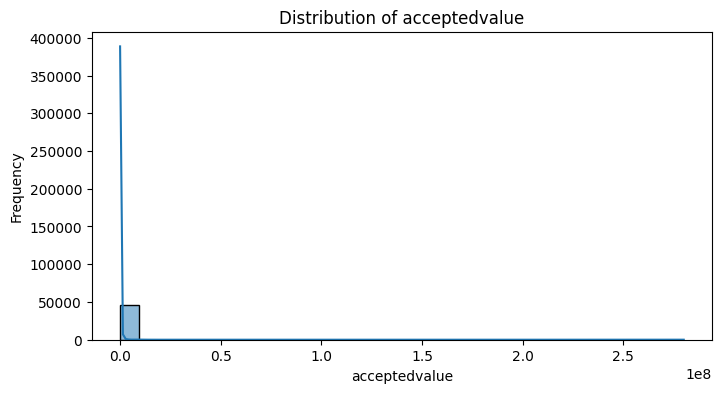

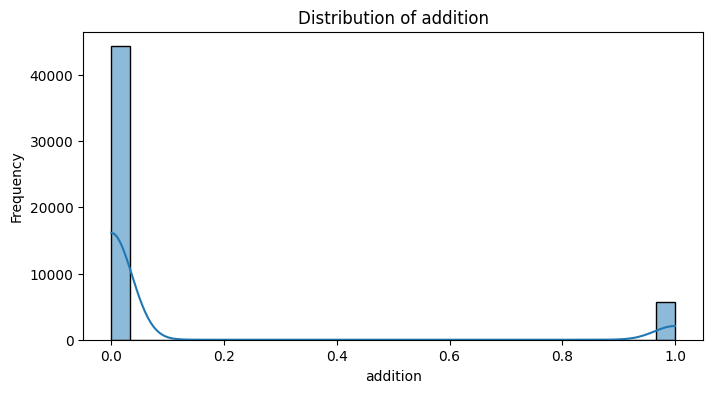

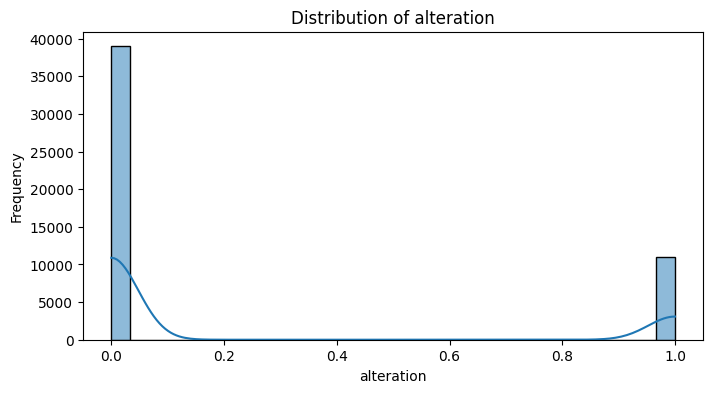

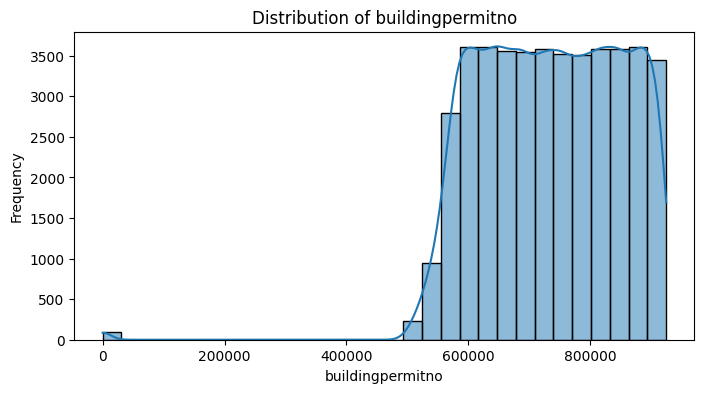

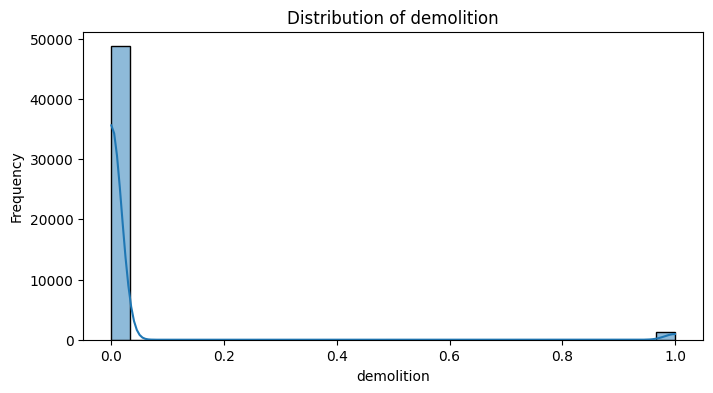

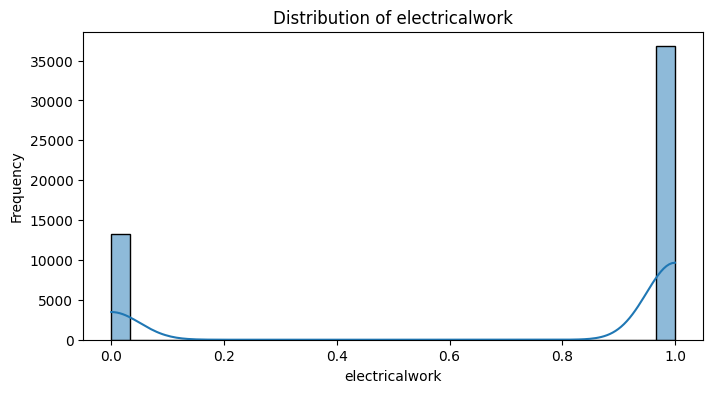

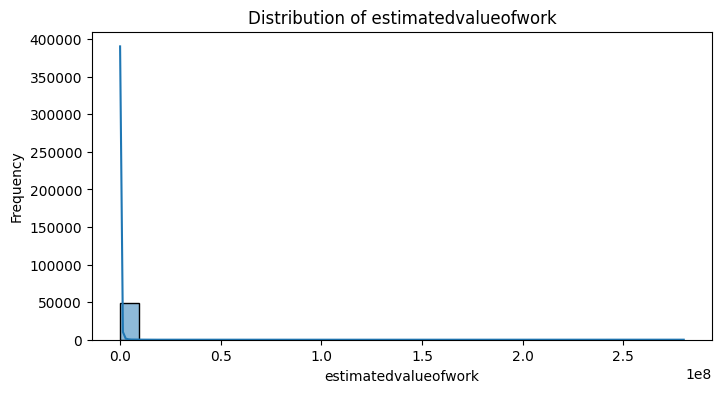

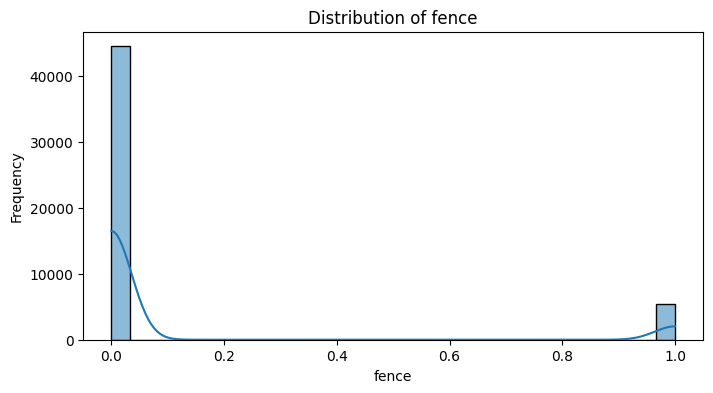

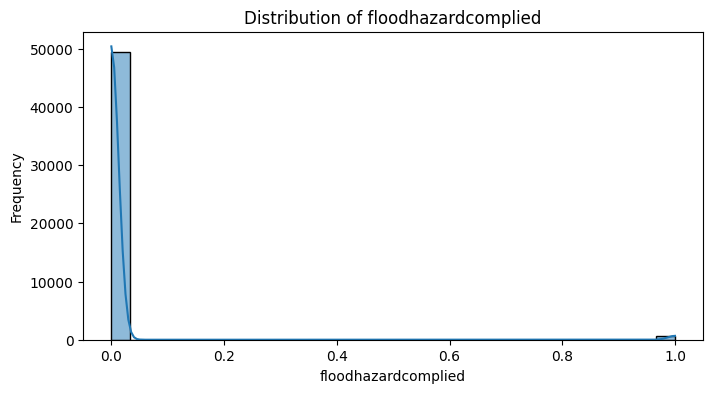

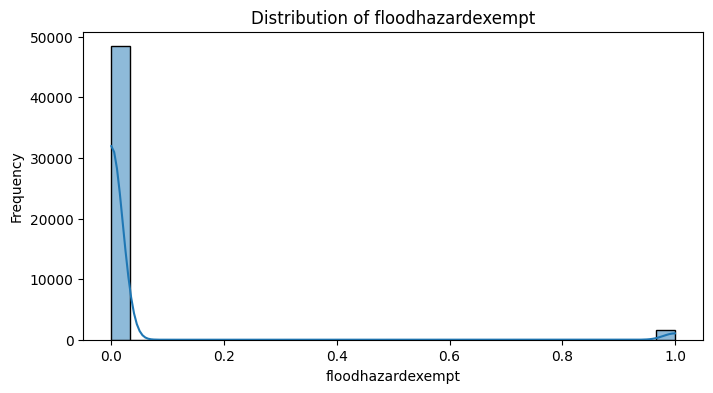

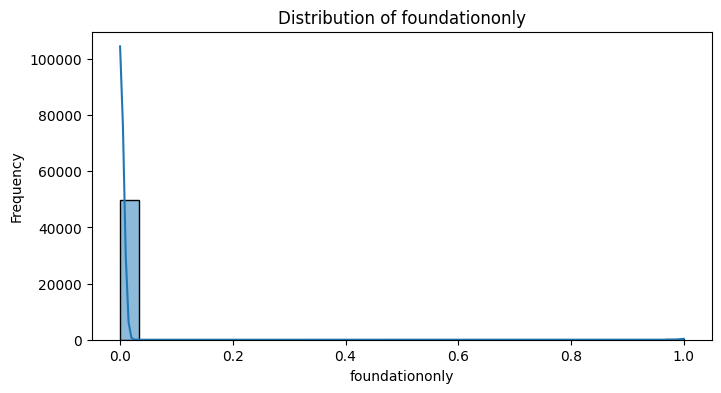

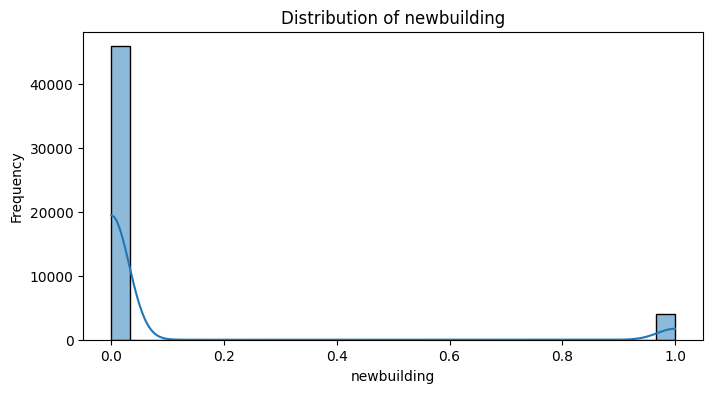

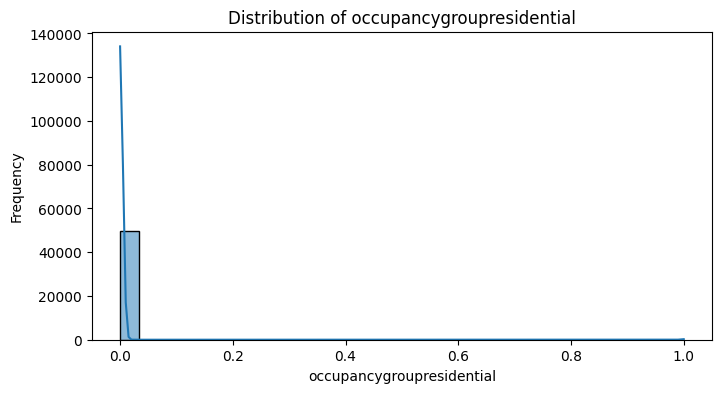

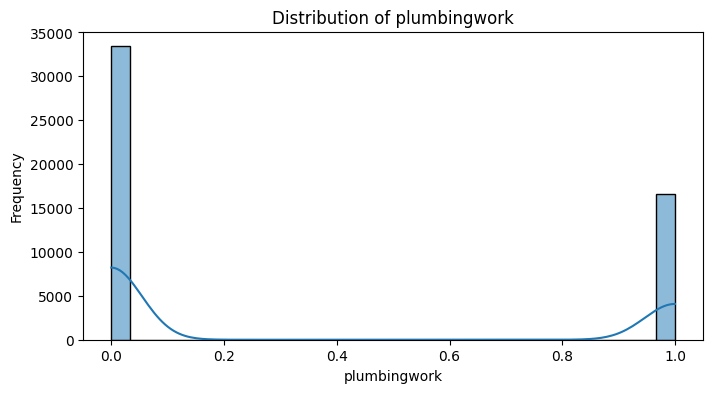

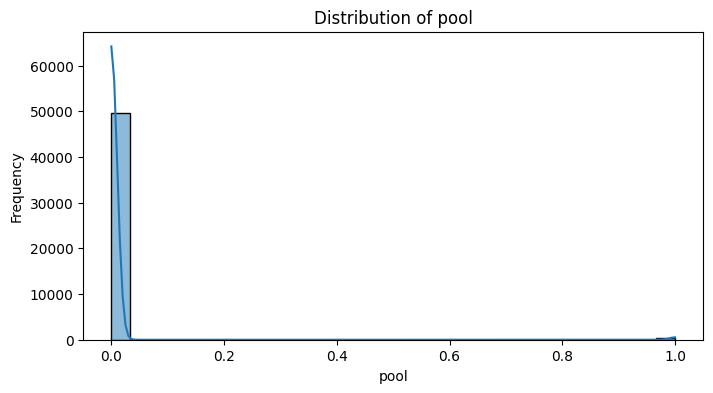

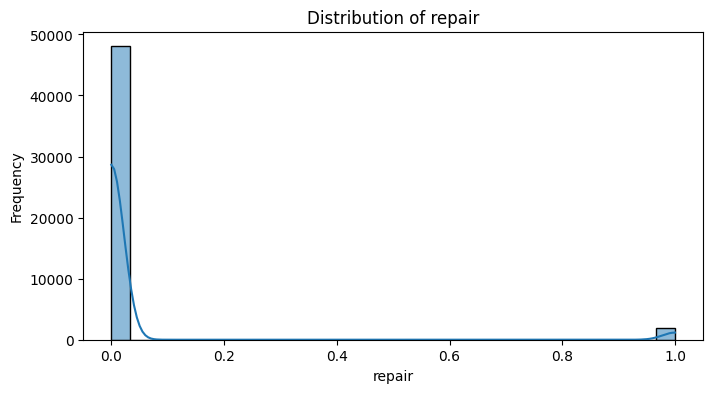

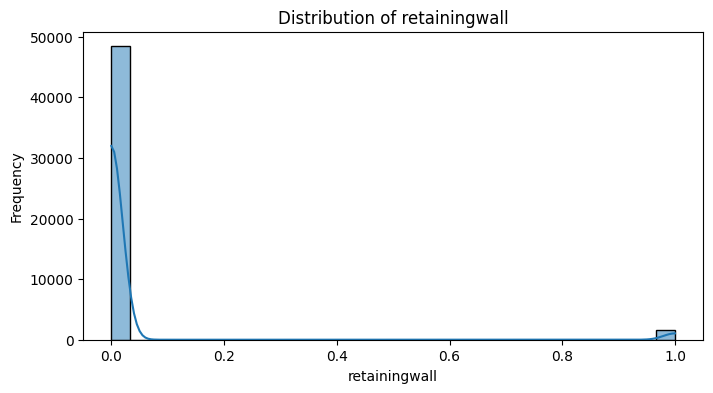

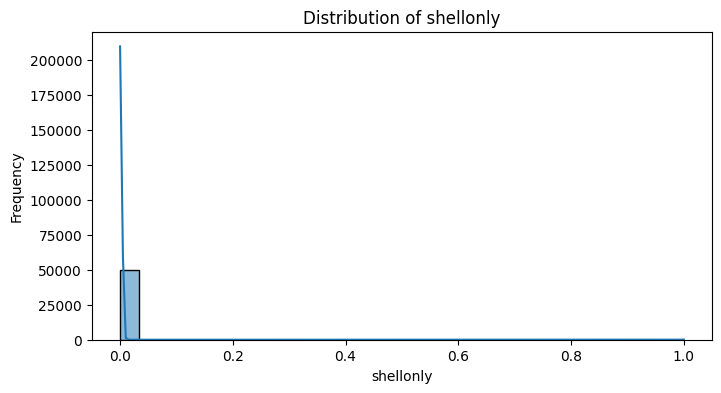

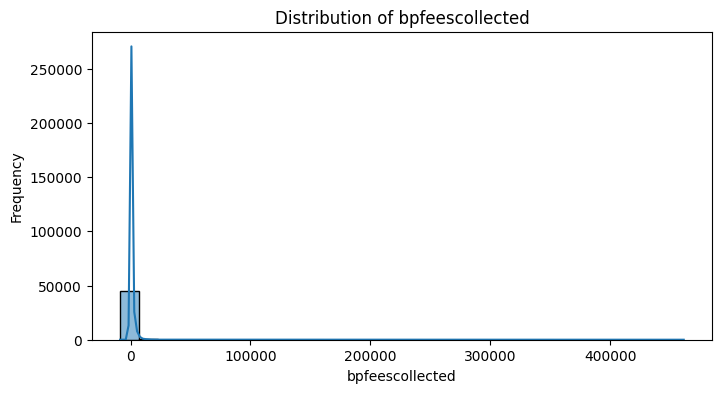

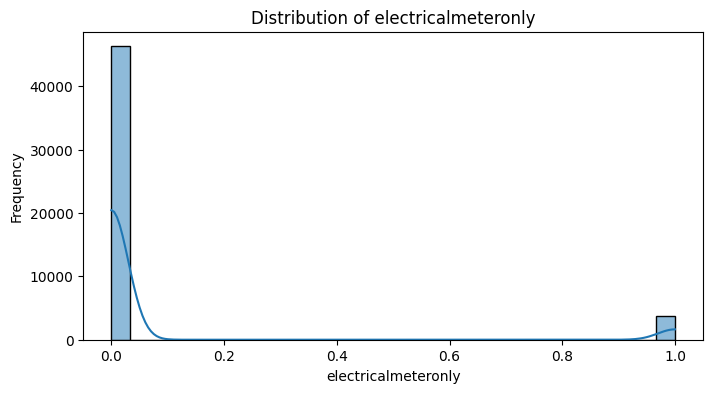

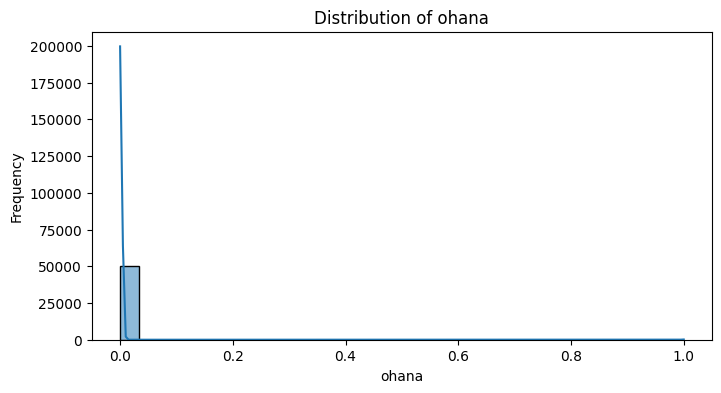

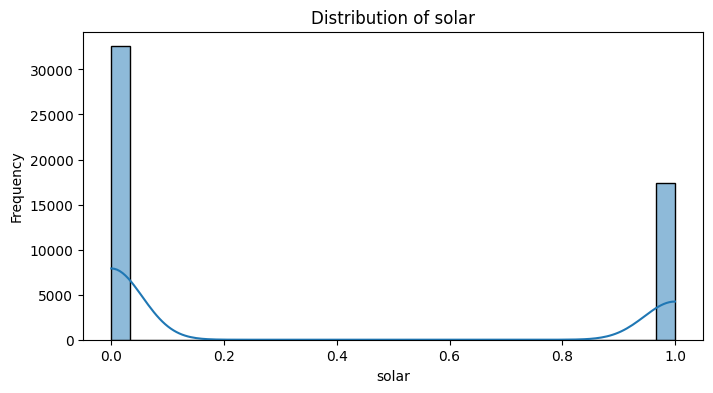

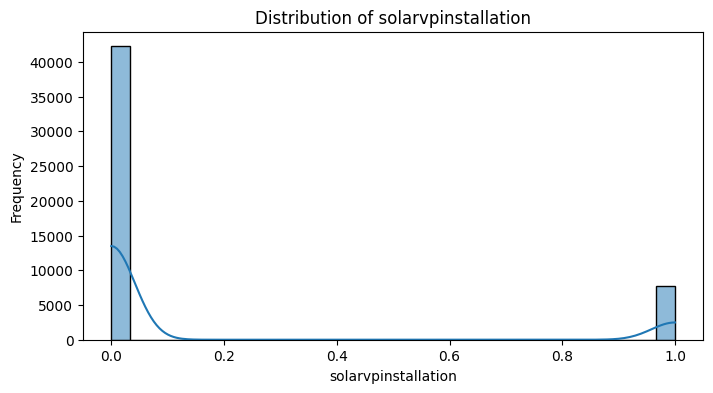

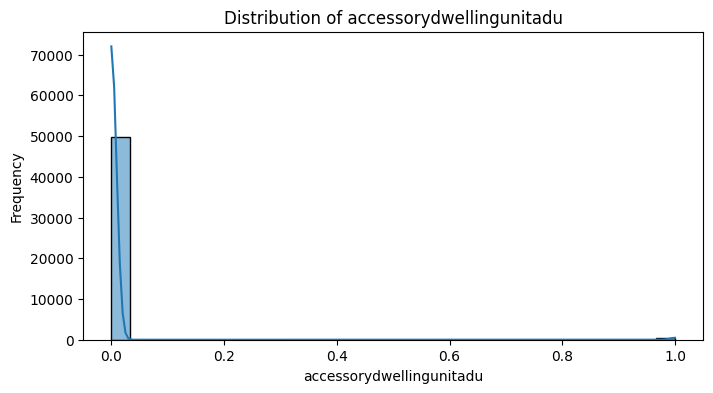

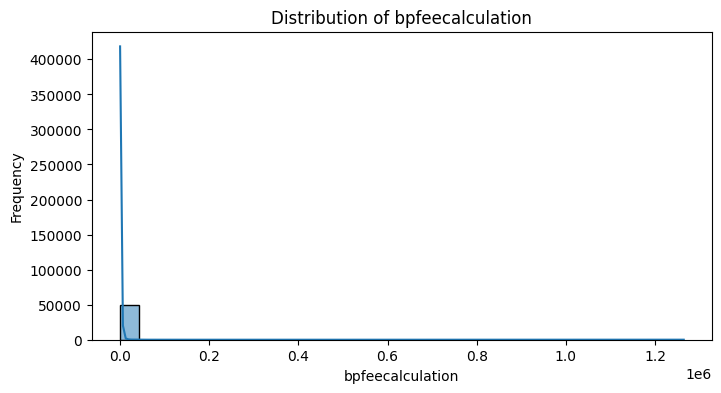

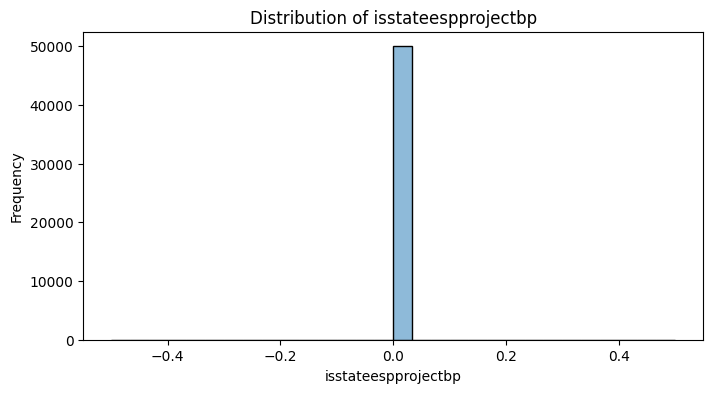

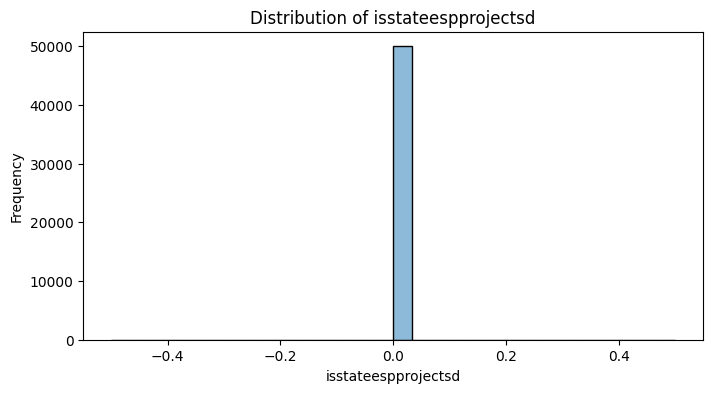

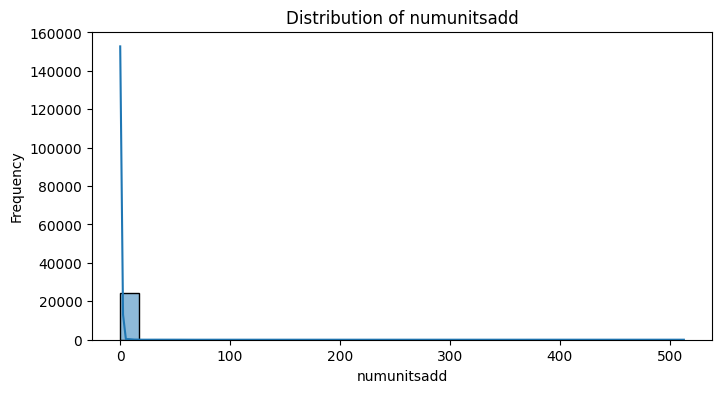

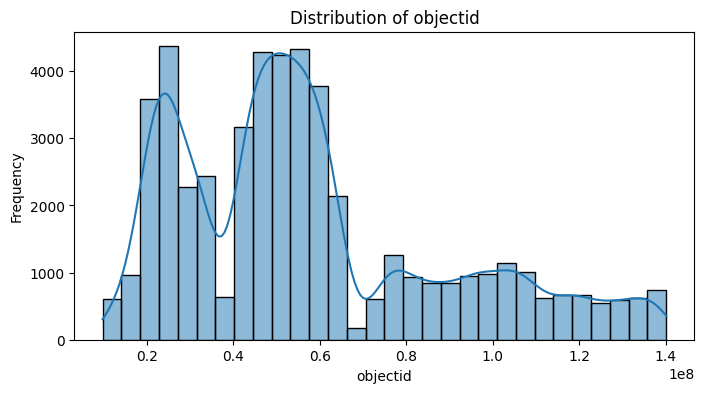

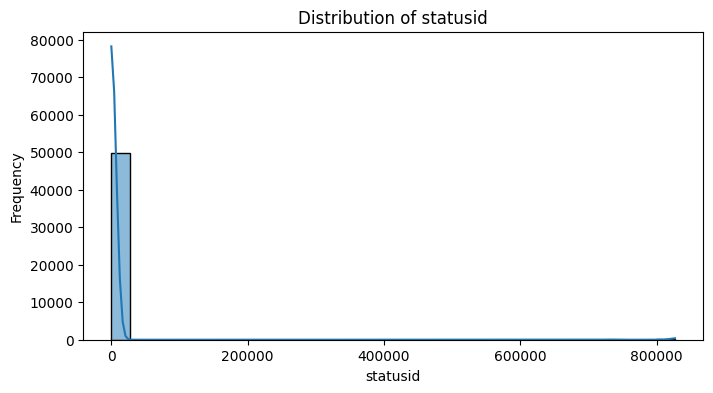

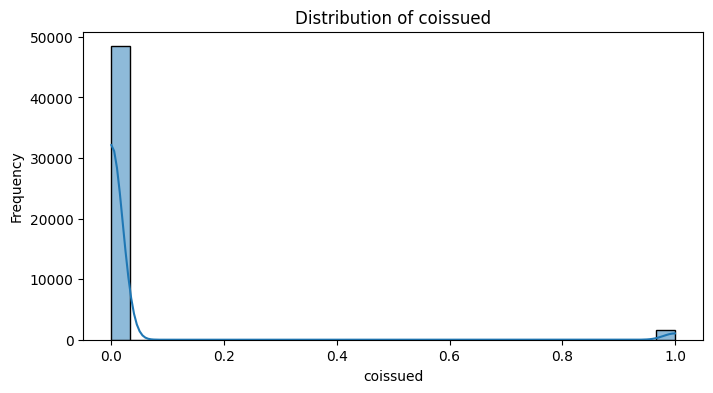

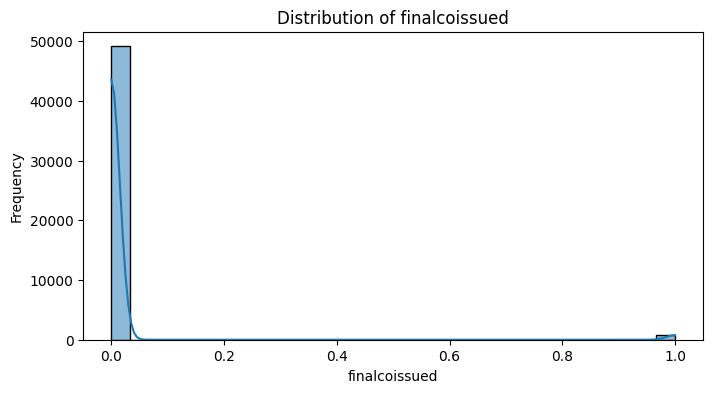

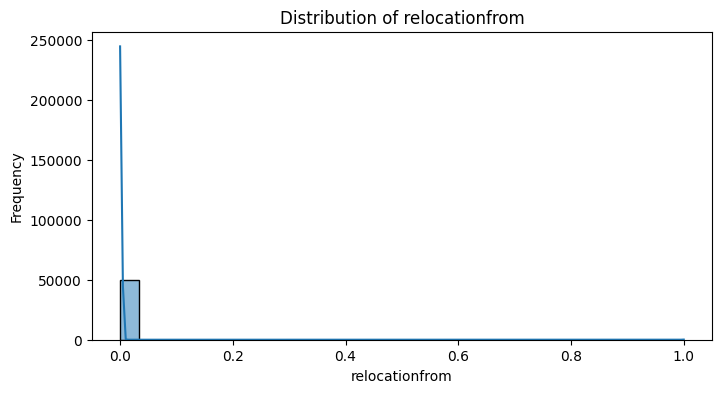

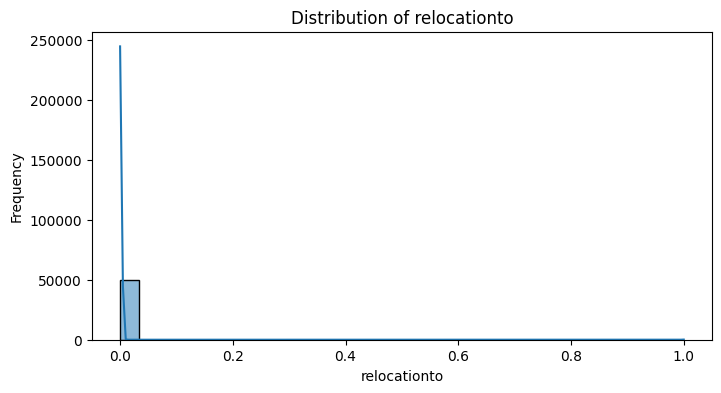

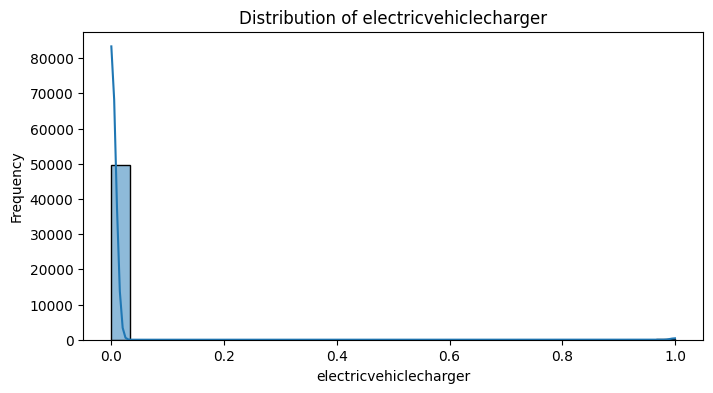

In [26]:
sample_df = df.sample(50000, random_state=42)

for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(sample_df[col].dropna(), bins=30, kde=True)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

## Step 16 — Histogram Distribution Analysis for Numerical Variables

After computing the numerical summary statistics, I proceeded to visualize the distribution of all numerical features using histograms. Histogram analysis helps to understand how values are distributed across each variable and allows the identification of skewness, outliers, and general data patterns.

### Purpose of Histogram Analysis

Histograms are useful for:

- visualizing the **distribution of numerical values**
- detecting **skewed variables**
- identifying **outliers or extreme values**
- understanding whether variables follow **normal, uniform, or skewed distributions**

This is an important step before applying transformations, scaling, or machine learning models.

### Visualization Method

To generate the histograms efficiently, I created a loop that iterates through all numerical columns in the dataset. For each numerical variable, a histogram with a kernel density estimate (KDE) curve was plotted.

This approach automatically produces distribution plots for all numerical variables without manually specifying each column.

### Observations from the Histograms

Several patterns are visible from the generated plots:

**1. Highly Skewed Variables**

Variables such as:

- `acceptedvalue`
- `estimatedvalueofwork`
- `objectid`

show strong **right-skewed distributions**, indicating that most projects have relatively small values while a few projects have extremely large values.

This is common in financial or cost-related variables.

---

**2. Binary Indicator Variables**

Many columns such as:

- `addition`
- `alteration`
- `demolition`
- `electricalwork`

show distributions concentrated around **0 and 1**.

These represent **binary indicator features**, meaning they simply indicate whether a certain permit activity occurred.

For such variables, bar charts or frequency plots may sometimes be more informative than histograms.

---

**3. Identifier-Like Variables**

Columns such as:

- `buildingpermitno`
- `objectid`

appear to behave more like **unique identifiers rather than analytical variables**, as their values span wide ranges without meaningful distribution patterns.

These variables may later be excluded from modeling since they do not carry predictive information.

---

**4. Count-Based Variables**

Variables such as:

- `numunitsadd`

show distributions concentrated in smaller ranges, indicating that most projects involve relatively small numbers of added units.

---

### Importance of This Step

Histogram analysis helps to:

- detect **non-normal distributions**
- identify **variables requiring transformation**
- highlight **binary vs continuous features**
- provide intuition about the **scale and behavior of the data**

These insights guide decisions in later steps such as **outlier handling, feature engineering, and model preparation**.

### Next Step

After analyzing numerical distributions, the next stage will focus on **categorical variable analysis**, where frequency distributions and category patterns will be examined using bar charts and count plots.

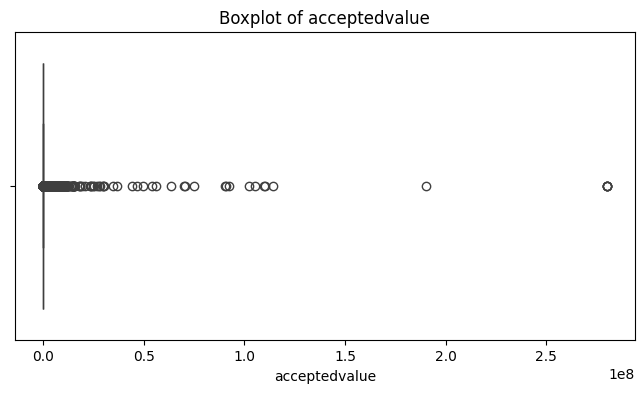

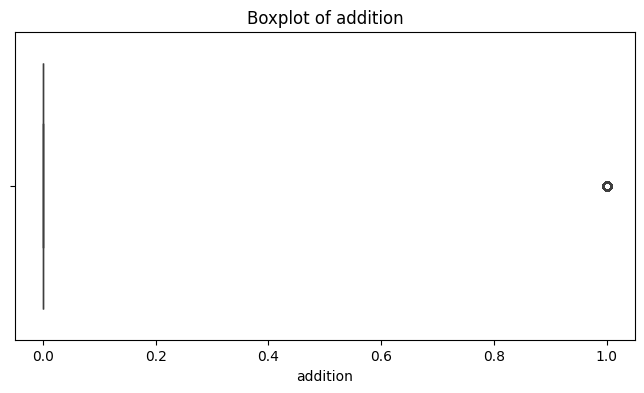

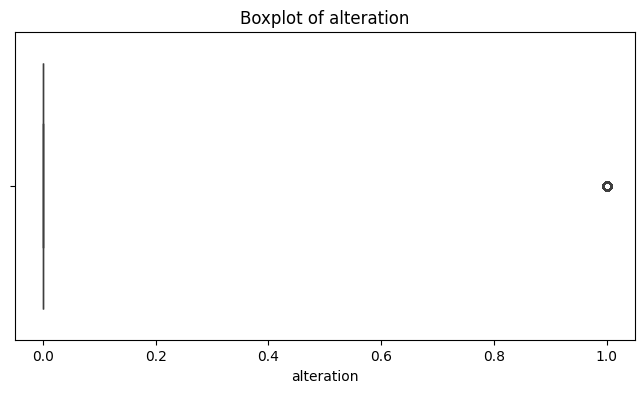

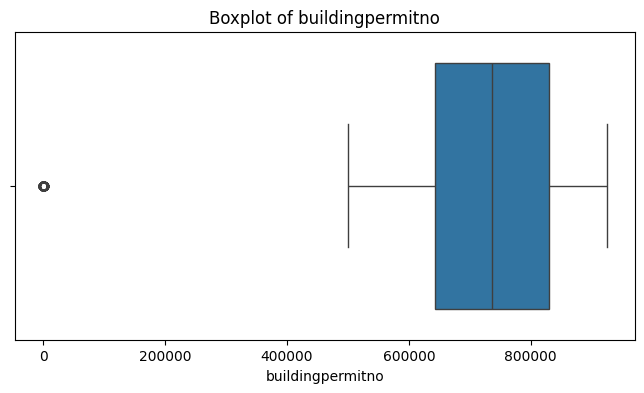

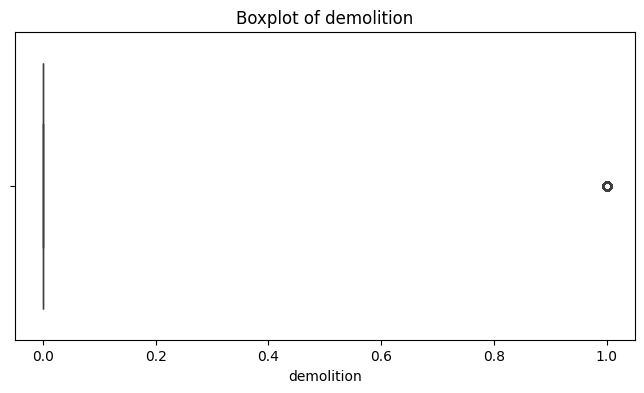

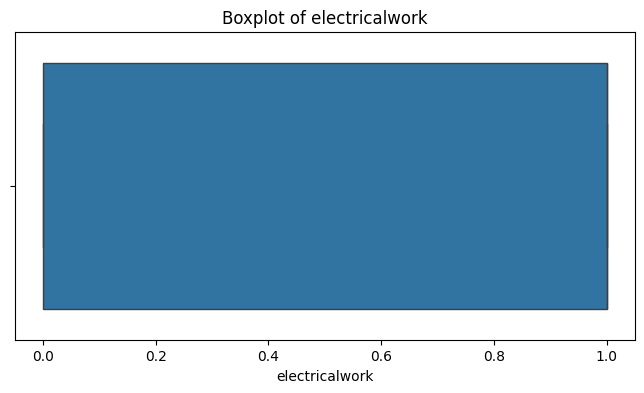

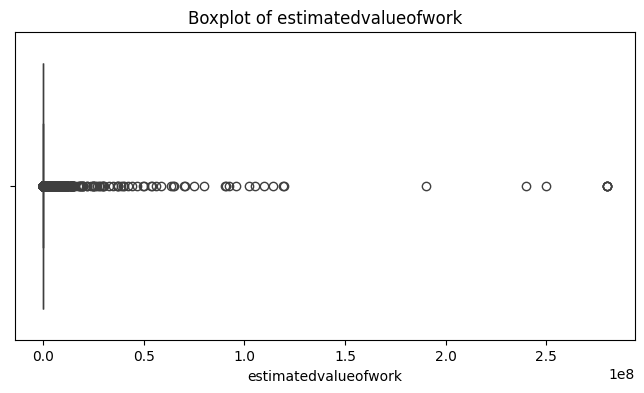

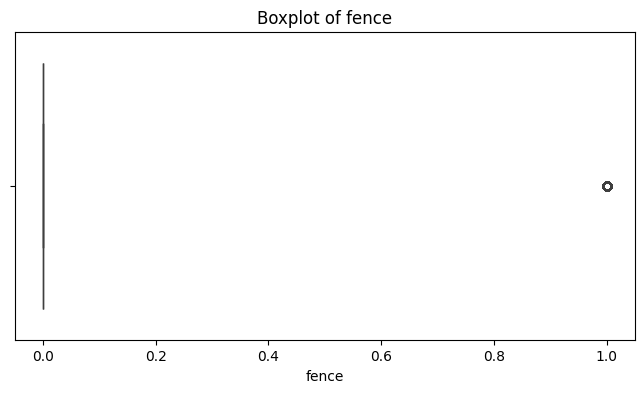

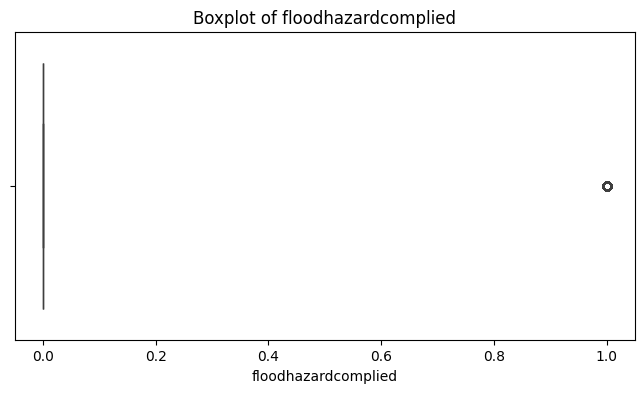

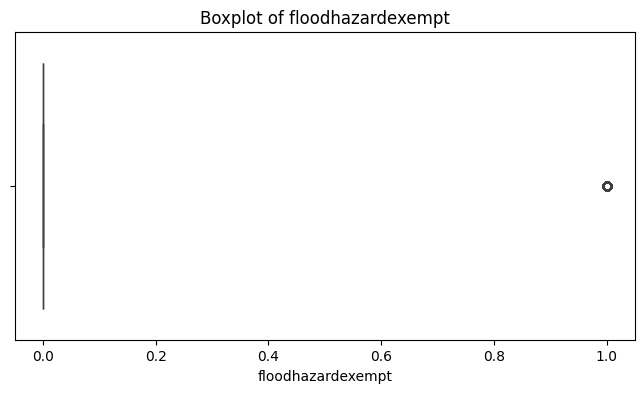

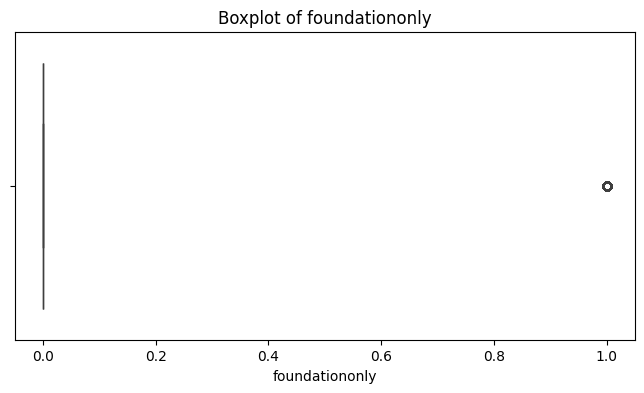

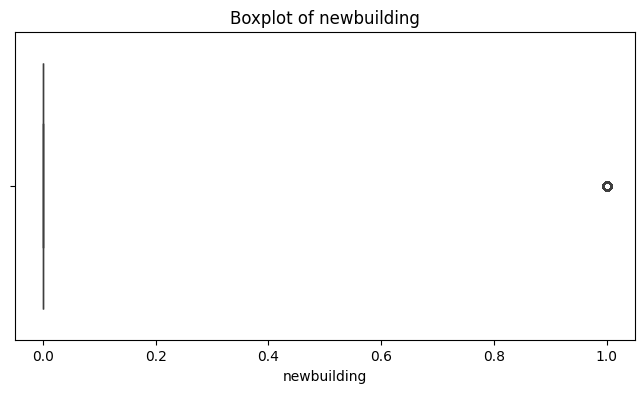

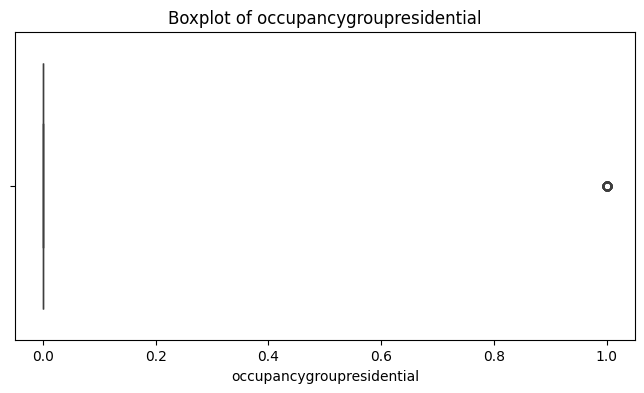

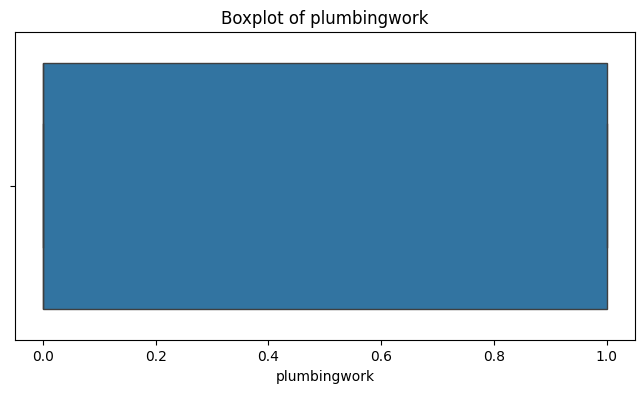

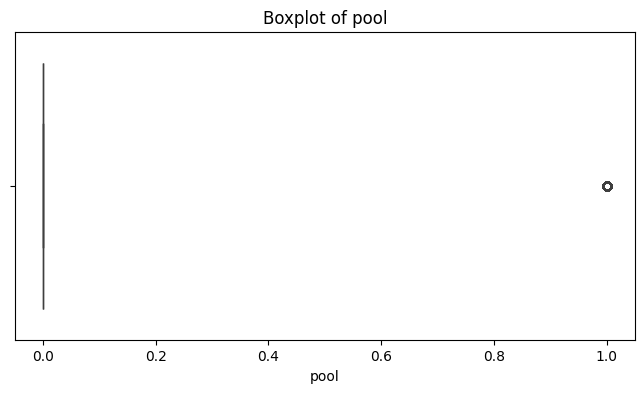

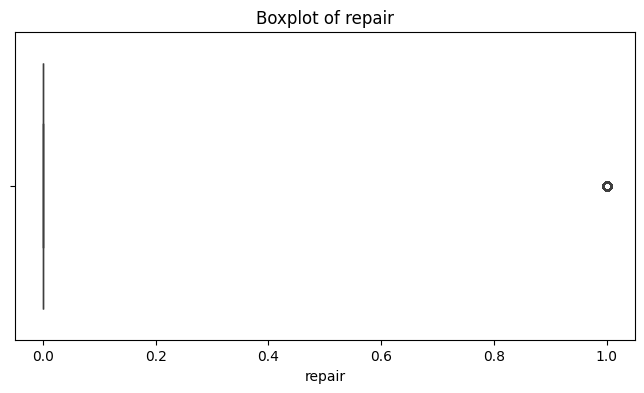

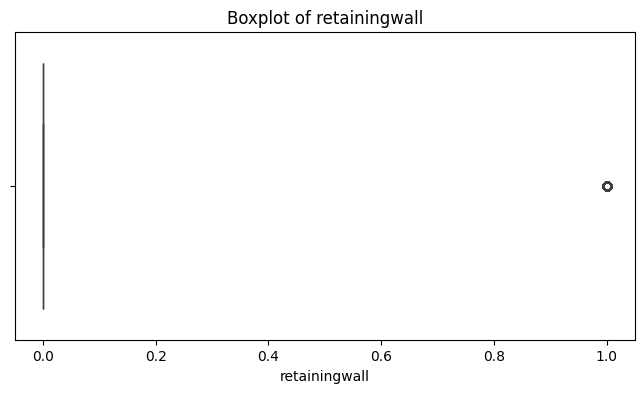

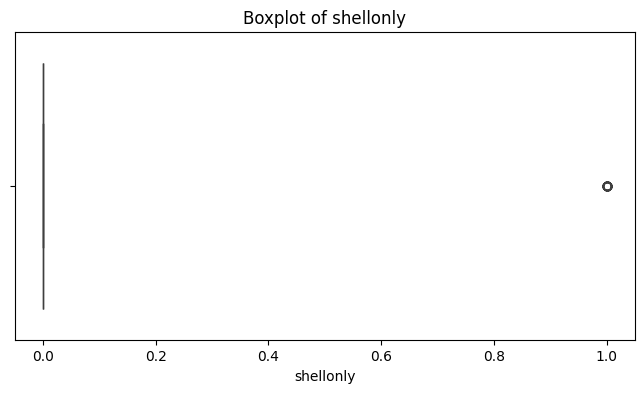

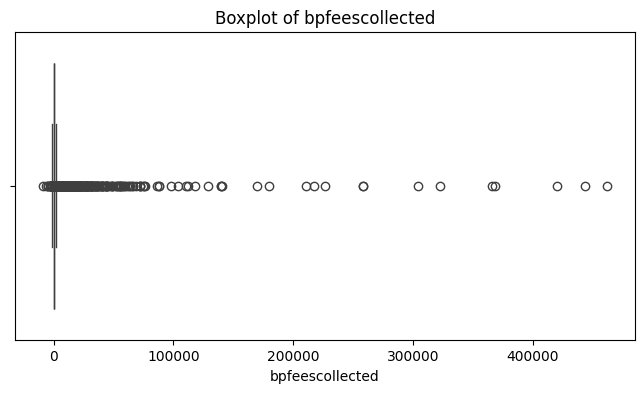

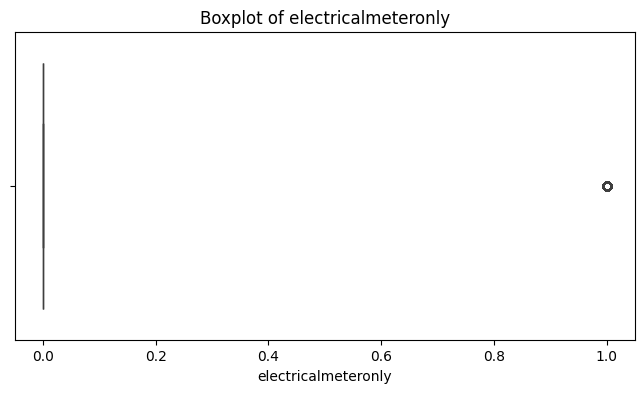

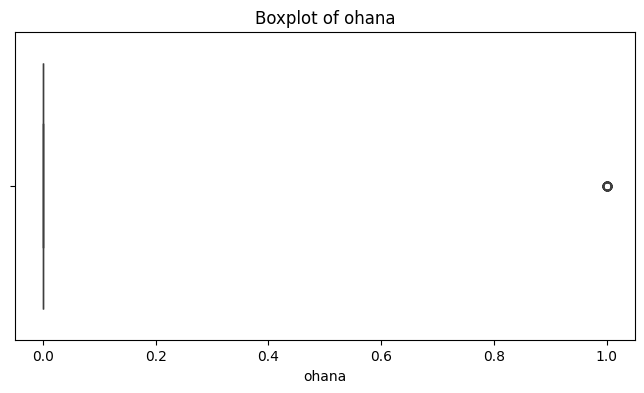

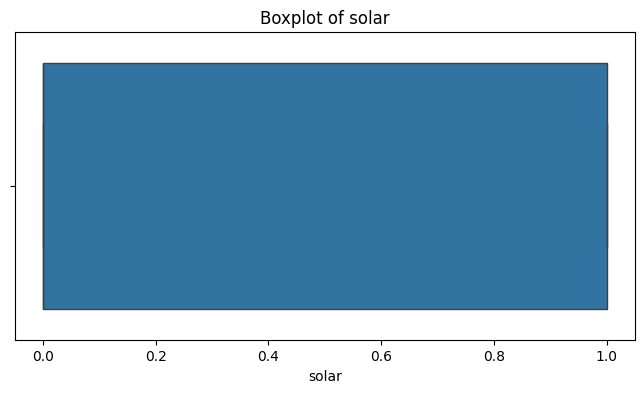

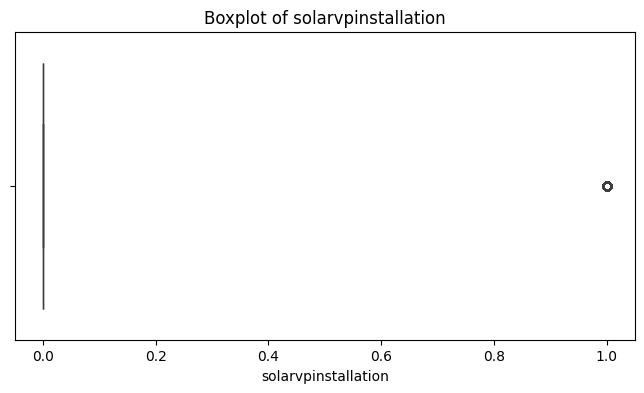

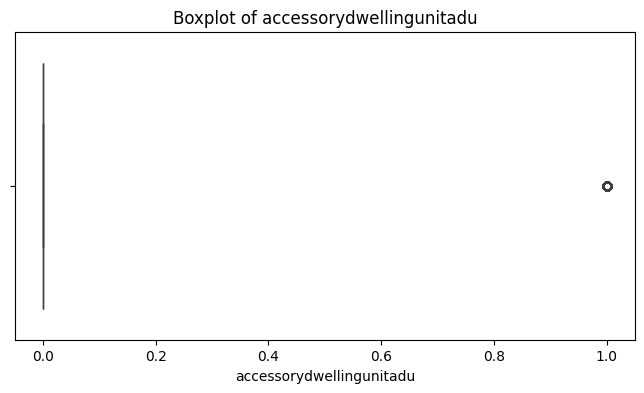

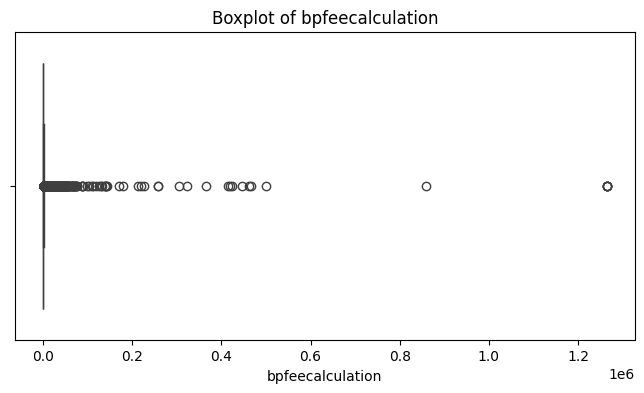

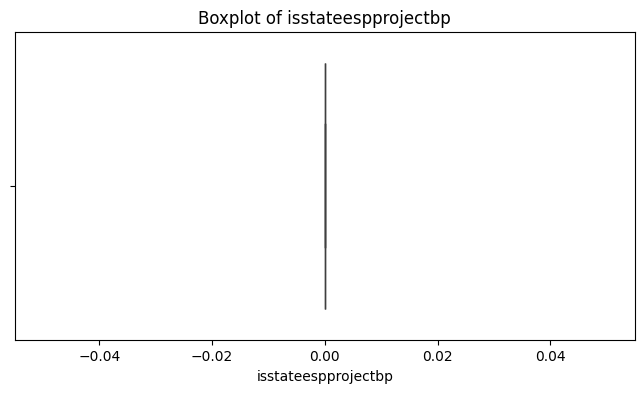

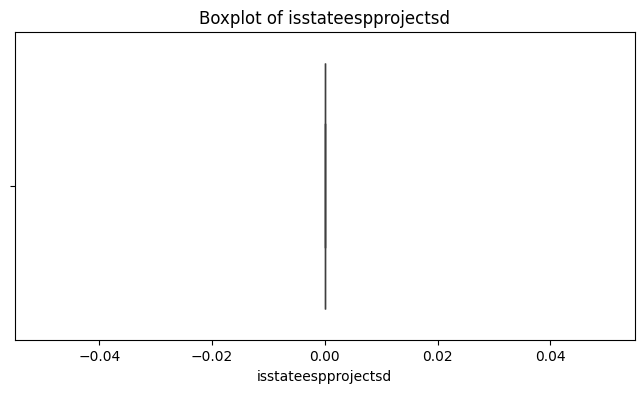

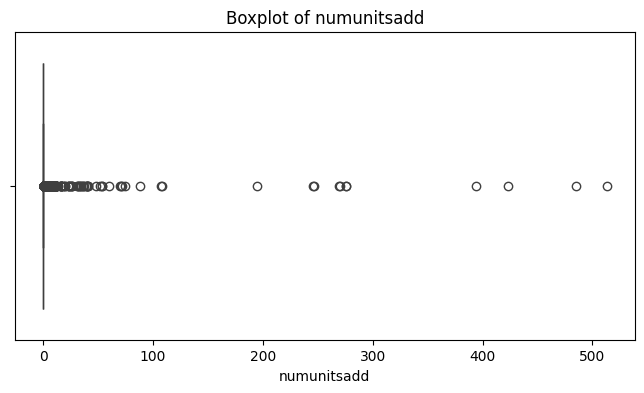

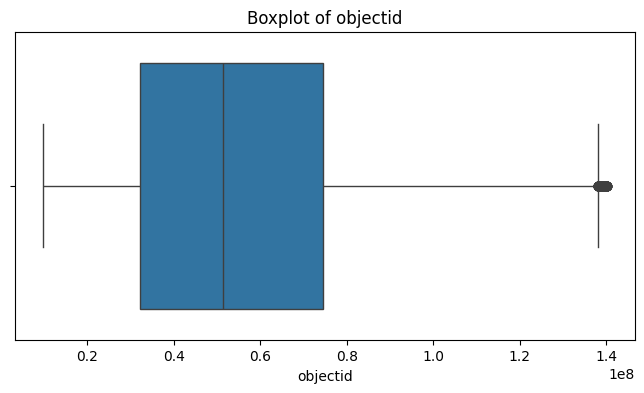

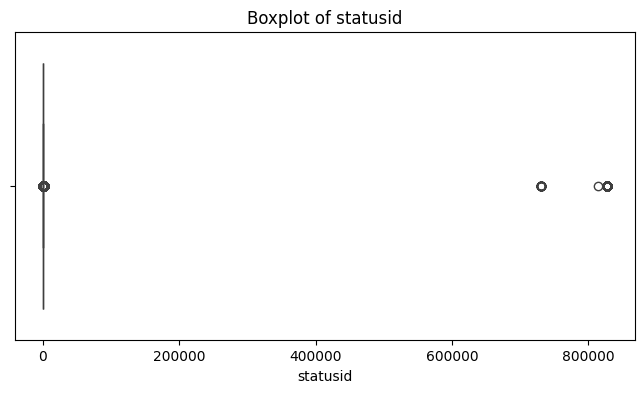

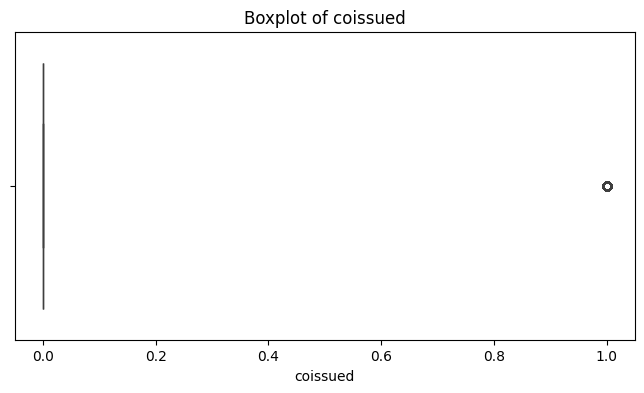

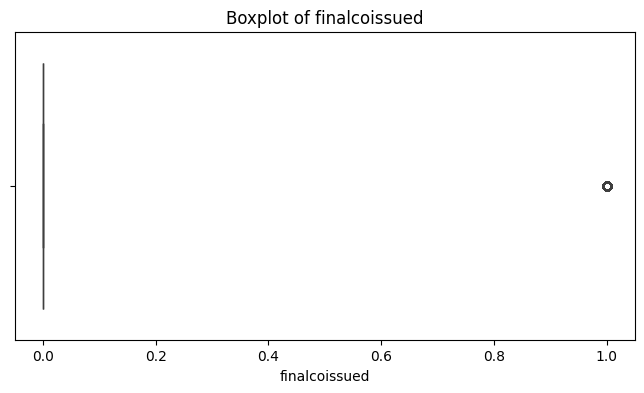

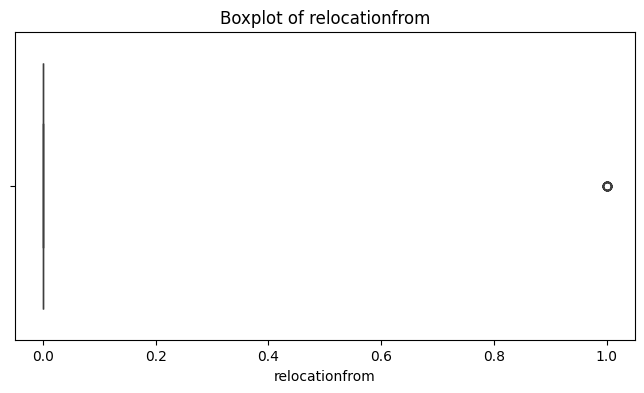

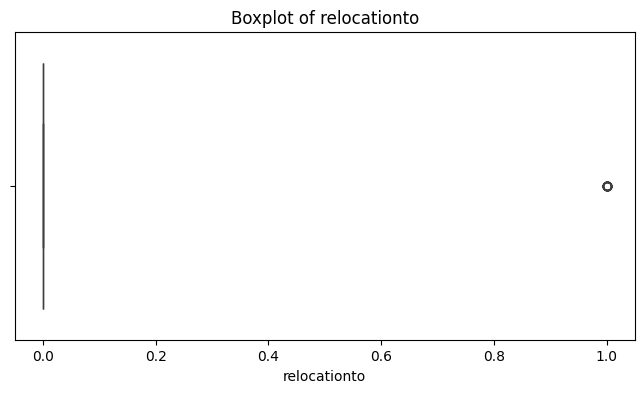

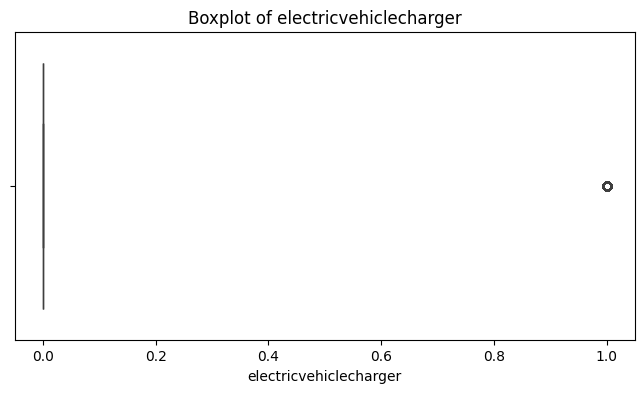

In [27]:
sample_df = df.sample(50000, random_state=42)

for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=sample_df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

## Step 17 — Numerical Boxplot Analysis

After examining the distributions of numerical variables using histograms, I proceeded to generate boxplots for each numerical feature. Boxplots provide a clear visualization of the spread of the data and help identify potential outliers that may influence statistical analysis or machine learning models.

### Purpose of Boxplot Analysis

Boxplots are useful for:

- detecting **outliers and extreme values**
- visualizing the **spread and variability** of numerical variables
- identifying **skewed distributions**
- understanding the **median and quartile ranges** of each variable

This step complements the histogram analysis by highlighting observations that fall outside the typical range of values.

### Visualization Approach

To efficiently analyze multiple numerical variables, I used a loop to generate boxplots for all numerical columns in the dataset. Each boxplot represents:

- the **median value** (center line)
- the **interquartile range (IQR)** (box)
- the **whiskers**, showing the spread of most observations
- **points beyond the whiskers**, representing potential outliers

### Key Observations

Several patterns were observed from the boxplots:

**1. Strong Presence of Outliers**

Variables such as:

- `acceptedvalue`
- `estimatedvalueofwork`
- `bpfeescollected`
- `objectid`

show significant numbers of outliers. These variables contain extremely large values relative to the majority of the data, which is common for financial or cost-related attributes.

---

**2. Binary Indicator Variables**

Several variables including:

- `addition`
- `alteration`
- `demolition`
- `electricalwork`
- `plumbingwork`
- `pool`
- `relocationto`
- `electricvehiclecharger`

contain values primarily between **0 and 1**, indicating that they are **binary indicator variables** representing whether a particular permit activity occurred.

Because these variables only take two values, their boxplots appear compressed and do not provide much distributional insight.

---

**3. Identifier-Like Variables**

Variables such as:

- `buildingpermitno`
- `objectid`

behave more like identifiers rather than continuous analytical variables. Their values span wide ranges but do not necessarily represent meaningful numerical measurements.

---

**4. Highly Skewed Cost-Related Variables**

Variables related to financial values (such as `acceptedvalue` and `estimatedvalueofwork`) show strong right-skewness with several extreme values. This indicates that while most permits involve relatively small project values, a small number of permits involve very large construction costs.

### Importance of This Step

Boxplot analysis is important because it helps identify:

- **extreme values that may distort statistical analysis**
- variables that may require **outlier handling techniques**
- features that may need **transformation or scaling** before modeling

These insights will guide the next stage of the analysis where outliers may be formally evaluated using statistical techniques.

### Next Step

With numerical variable analysis completed (histograms and boxplots), the next stage of the workflow will focus on **categorical variable exploration**, including:

- identifying categorical columns
- generating **frequency tables**
- calculating **percentage distributions**
- visualizing categories using **bar charts**

In [28]:
cat_cols = df.select_dtypes(include=['object','category','bool']).columns

print("Categorical Columns:", len(cat_cols))
print(cat_cols)

Categorical Columns: 25
Index(['buildingpermittype', 'contractor', 'contractorelectrical',
       'contractorplumbing', 'externalfilenum', 'occupancygroupassessed',
       'occupancygroupcategory', 'planmaker', 'proposeduse',
       'statusdescription', 'tmk', 'typesofconstructionactual',
       'typesofconstructionmin', 'ownershipassessed', 'structurecode',
       'commercialresidential', 'applicant', 'cityproject', 'externalid',
       'joblocation', 'locationpermitissued', 'processreviewtype',
       'stateproject', 'tmklookup', 'address'],
      dtype='object')


## Step 18 — Identification of Categorical Variables

After completing the numerical variable analysis (histograms and boxplots), the next step in the exploratory data analysis process is to identify all categorical features in the dataset.

### Objective

Categorical variables represent qualitative attributes or labels rather than measurable quantities. Identifying these variables is important because they require different analytical techniques compared to numerical features.

Understanding categorical columns helps prepare the dataset for:

- frequency analysis
- percentage distribution analysis
- bar chart visualization
- categorical encoding for machine learning models

### Method Used

To detect categorical variables, I used the `select_dtypes()` function in Pandas. This function filters columns based on their data types.

I selected columns with the following types:

- **object** → text-based categorical variables
- **category** → explicitly defined categorical data
- **bool** → binary indicator variables

This approach ensures that all non-numeric categorical features are captured for further analysis.

### Results

The dataset contains **25 categorical variables**, including attributes related to permit classification, contractors, construction types, project status, and administrative identifiers.

Some key examples include:

- `buildingpermittype`
- `contractor`
- `occupancygroupcategory`
- `planmaker`
- `proposeduse`
- `statusdescription`
- `typesofconstructionactual`
- `ownershipassessed`
- `structurecode`
- `joblocation`
- `processreviewtype`

These variables describe **qualitative characteristics of building permits**, such as the type of construction, the contractor involved, the project classification, and the administrative processing details.

### Importance of This Step

Identifying categorical variables allows the analysis to proceed with categorical exploration techniques such as:

- **frequency tables**
- **percentage distributions**
- **bar chart visualizations**

These techniques help reveal the most common categories, dominant permit types, and overall patterns within the categorical data.

### Next Step

The next step is to compute **frequency tables and percentage distributions** for each categorical variable to understand how observations are distributed across different categories.

In [29]:
# Step 19 — Frequency Tables for Categorical Variables
for col in cat_cols:
    print(f"\nFrequency Table for {col}")
    print(df[col].value_counts())


Frequency Table for buildingpermittype
buildingpermittype
4 - Addition, alteration or repair (no change in units)    9444
1 - New                                                    4005
2 - Addition, alteration or repair (units added)           1305
7 - Demolition                                              858
3 - Addition, alteration or repair (units subtracted)        63
9 - Ohana                                                    27
8 - Moved in/out of parcel                                   20
Name: count, dtype: int64

Frequency Table for contractor
contractor
NONE  \n   / State Lic:  / ID: 11320462 / PH:                                                                                                                                                                                                                           53611
Alternate Energy, Inc.  \n96-1276  WAIHONA ST 114 / State Lic: CT26041 / ID: 7002080 / PH: (808) 842-5853                                                 

## Step 19 — Frequency Table Analysis for Categorical Variables

After identifying all categorical variables in the dataset, the next step is to examine how frequently each category appears. This is done by generating **frequency tables** for every categorical column.

### Objective

The purpose of this step is to understand how categorical values are distributed across the dataset. Frequency analysis helps reveal:

- the **most common categories**
- **rare or infrequent categories**
- **data imbalance across categories**
- potential **data quality issues** such as excessive unique values

This information is essential before creating categorical visualizations and before performing any encoding for machine learning.

### Method Used

To generate frequency tables, I used the `value_counts()` function in Pandas. This function counts how many times each category appears within a column.

A loop was applied to automatically compute the frequency table for **all categorical columns**, ensuring a systematic analysis of the dataset.

### Key Observations

Several important patterns can already be observed from the frequency tables:

**Building Permit Type**
- The most common permit type is **Addition, alteration or repair (no change in units)**.
- Other common categories include **New construction** and **Addition with units added**.
- Less frequent categories include **Demolition**, **Ohana**, and **Moved in/out of parcel**.

**Contractor Information**
- A very large number of unique contractor entries exist.
- Some contractors appear frequently, while many appear only once.
- This suggests **high cardinality**, which may require special handling during feature engineering.

**Electrical and Plumbing Contractors**
- Some companies dominate the records, while others appear rarely.
- Many entries have **"NONE"**, indicating missing contractor assignment.

**Occupancy Group**
- The dataset is heavily dominated by **Single Family residential structures**.
- Other categories such as **Apartment**, **Office Building**, and **Commercial structures** appear less frequently.

**State Project Indicator**
- The majority of records are marked **No**, indicating most permits are not state projects.

**Location and Address Fields**
- Columns such as **tmklookup** and **address** contain extremely high numbers of unique values.
- These columns behave more like **identifiers rather than true categorical variables** and may require different treatment later in the modeling pipeline.

### Importance of This Step

Frequency analysis helps us:

- detect **dominant categories**
- identify **imbalanced categorical variables**
- detect **high-cardinality features**
- understand **real-world distribution patterns** within the dataset

These insights guide the next stages of exploratory data analysis and feature preparation.

### Next Step

The next step is to compute **percentage distributions** for each categorical variable.  
This will allow us to better understand the **relative proportion of each category** in the dataset before visualizing them using bar charts.

In [30]:
for col in cat_cols:
    print(f"\nPercentage Distribution for {col}")
    print(df[col].value_counts(normalize=True) * 100)


Percentage Distribution for buildingpermittype
buildingpermittype
4 - Addition, alteration or repair (no change in units)    60.068694
1 - New                                                    25.473858
2 - Addition, alteration or repair (units added)            8.300471
7 - Demolition                                              5.457321
3 - Addition, alteration or repair (units subtracted)       0.400712
9 - Ohana                                                   0.171734
8 - Moved in/out of parcel                                  0.127210
Name: proportion, dtype: float64

Percentage Distribution for contractor
contractor
NONE  \n   / State Lic:  / ID: 11320462 / PH:                                                                                                                                                                                                                           13.480736
Alternate Energy, Inc.  \n96-1276  WAIHONA ST 114 / State Lic: CT26041 / ID: 7002080 / PH: (

## Step 20 — Percentage Distribution Analysis for Categorical Variables

After generating frequency tables for the categorical variables, the next step is to calculate the **percentage distribution** of each category. While frequency tables show the raw counts, percentage distributions provide a clearer understanding of the **relative proportion of each category within the dataset**.

### Objective

The goal of this step is to determine how each category contributes to the overall dataset. This allows us to:

- identify **dominant categories**
- detect **imbalanced categorical variables**
- recognize **rare categories**
- better interpret the **relative importance of different groups**

Using percentages rather than raw counts makes comparisons across variables easier, especially when dealing with a large dataset.

### Method Used

To compute percentage distributions, the `value_counts()` function was used with the `normalize=True` argument in Pandas. This automatically converts frequency counts into proportions. The results were then multiplied by 100 to express them as percentages.

A loop was applied to calculate the percentage distribution for **all categorical columns**, ensuring a consistent and automated analysis across the dataset.

### Key Observations

Several meaningful patterns appear from the percentage distributions:

**Building Permit Type**
- Approximately **60%** of permits are related to *addition, alteration, or repair with no change in units*.
- Around **25%** represent **new construction permits**.
- Other permit types such as demolition or parcel relocation occur far less frequently.

**Contractor Fields**
- A large portion of records contain **"NONE"**, indicating that contractor information may be missing or not recorded.
- The remaining entries are highly fragmented across many individual contractors, showing **very high cardinality**.

**Occupancy Group Categories**
- Residential dwellings dominate the dataset, with **R-3 Dwelling representing the majority of permits**.
- Other categories such as offices, apartments, and commercial buildings appear in much smaller proportions.

**Construction Type**
- The majority of buildings fall into **VN construction type**, suggesting this is the most common structural classification in the dataset.

**State Project Indicator**
- Over **97% of permits are not state projects**, confirming that most permits are issued for private or local developments.

**Location-Based Columns**
- Columns such as **TMK lookup and address** contain extremely large numbers of unique values, behaving more like **identifiers rather than analytical categorical features**.

### Importance of This Step

Understanding percentage distributions helps highlight **dominant trends in the data** and exposes **imbalances across categories**. This insight is crucial before visualization, feature engineering, or encoding for machine learning models.

### Next Step

With the categorical distributions now understood, the next stage is to **visualize categorical variables using bar charts**. Bar charts will make the distribution patterns easier to interpret and will help identify dominant categories more clearly.

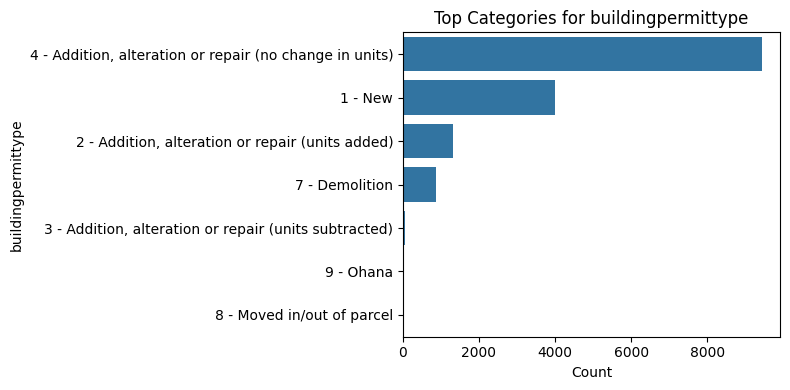

C:\Users\marty\AppData\Local\Temp\ipykernel_4192\3366634580.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


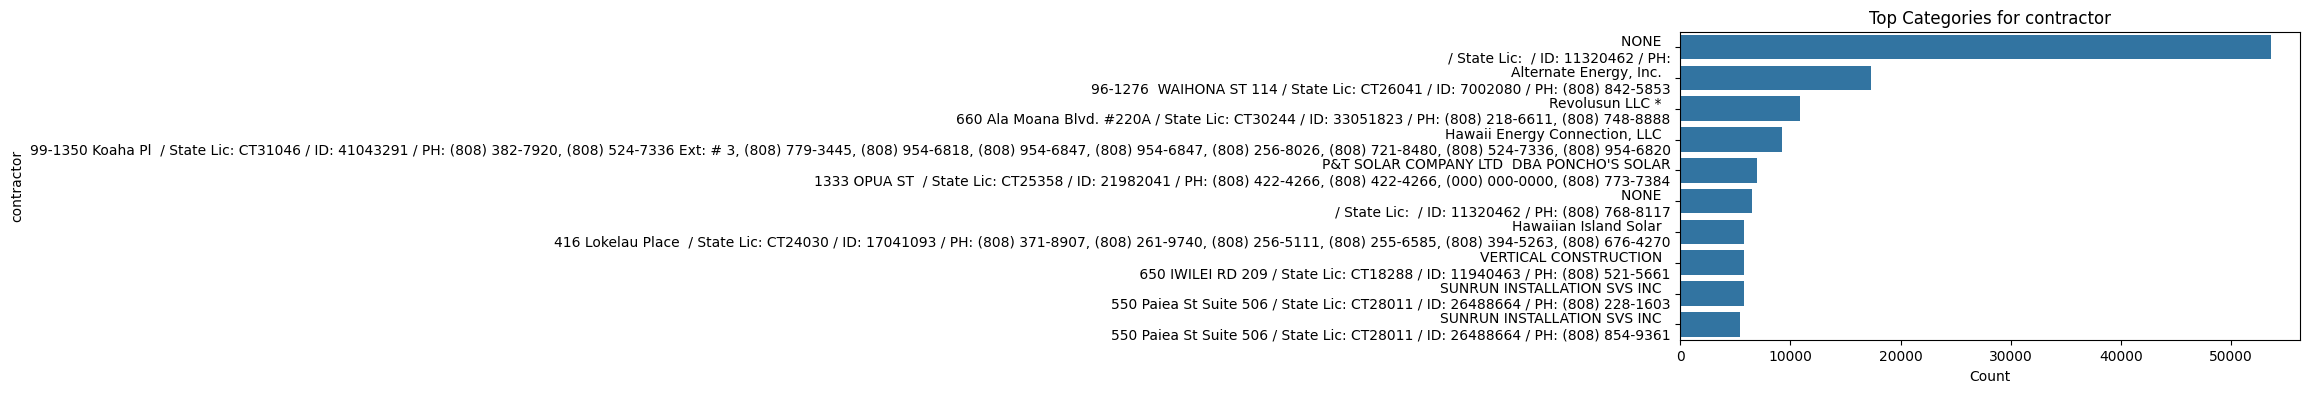

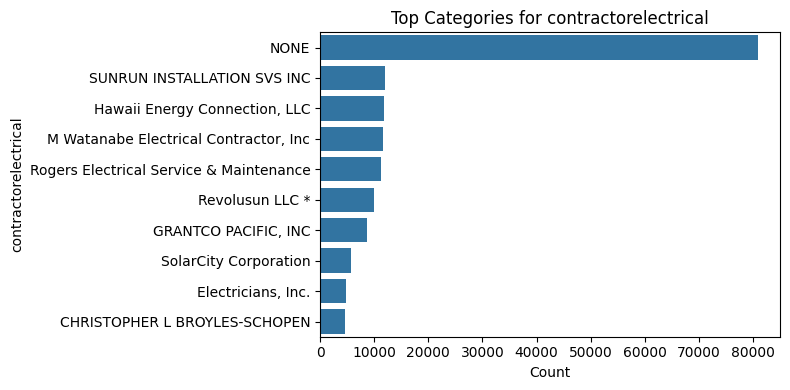

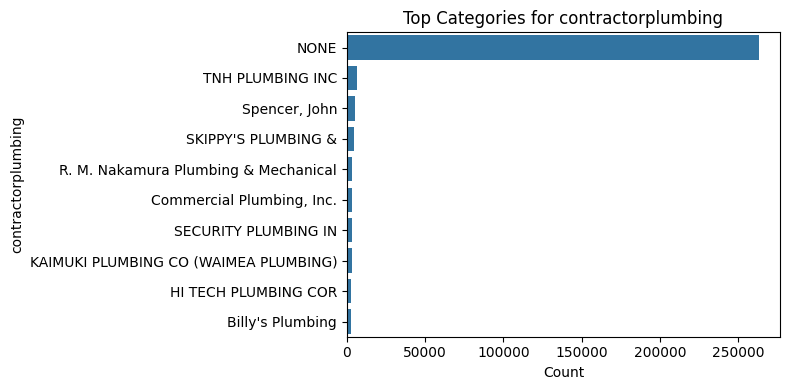

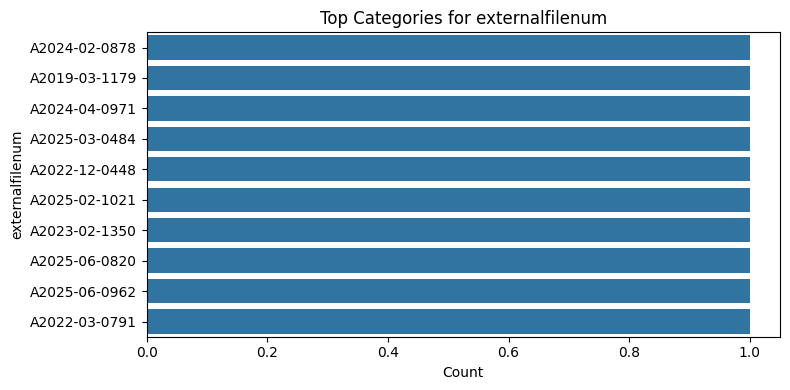

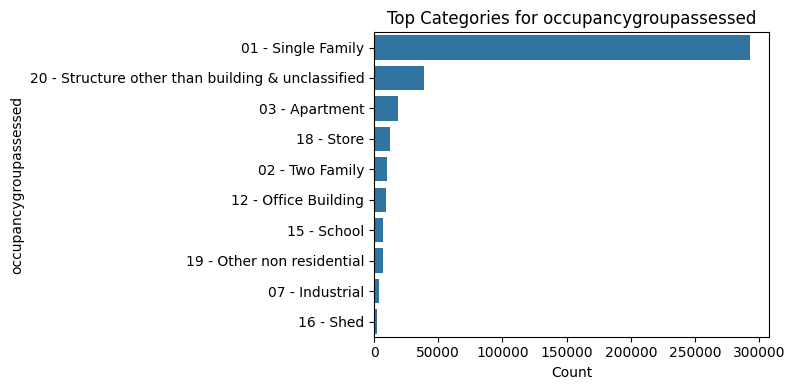

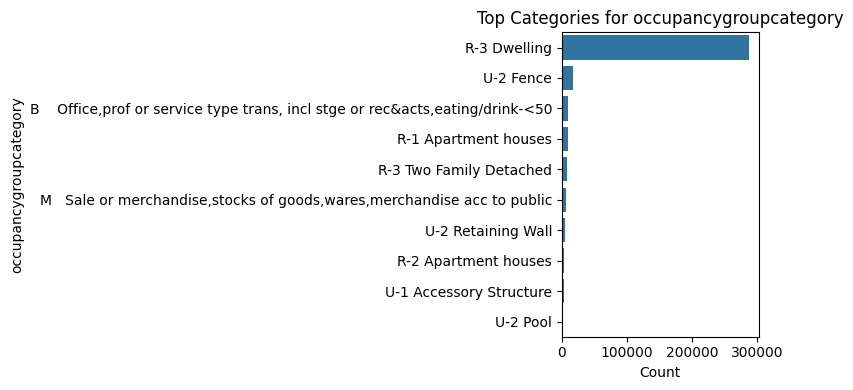

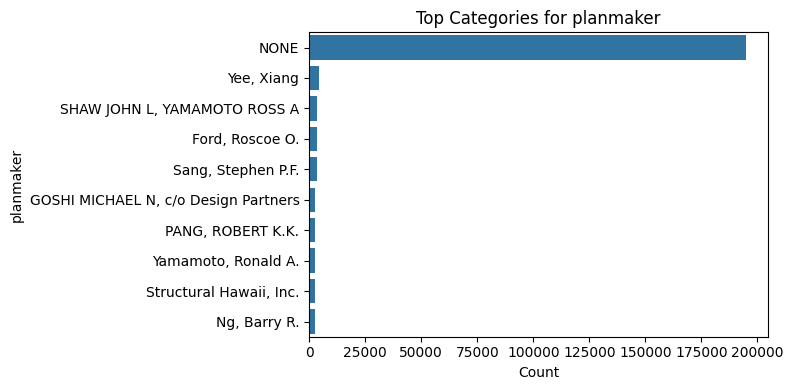

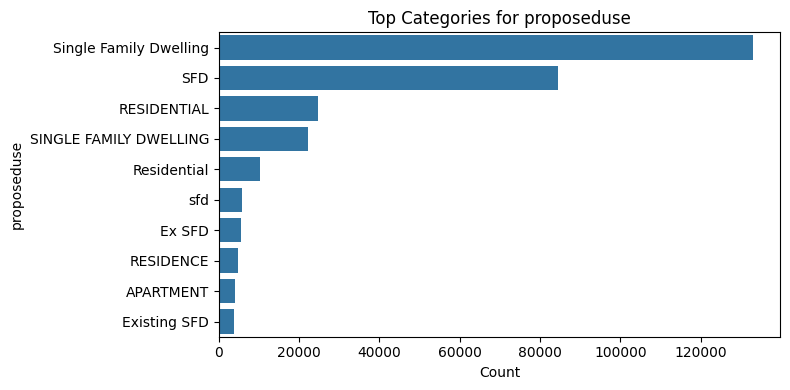

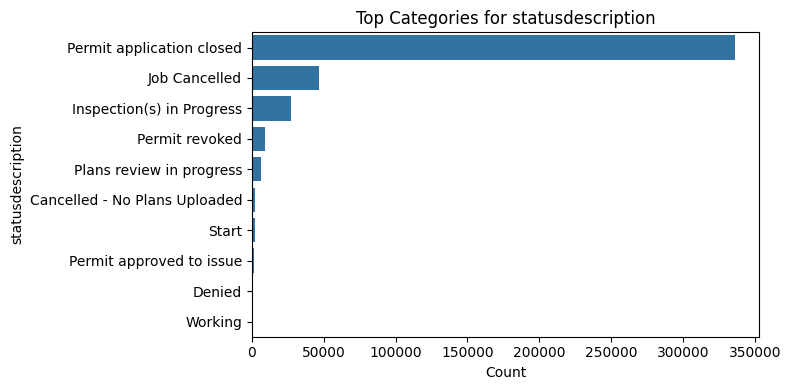

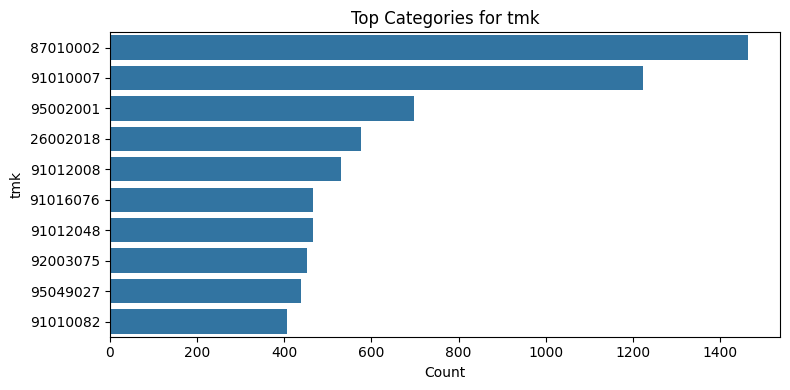

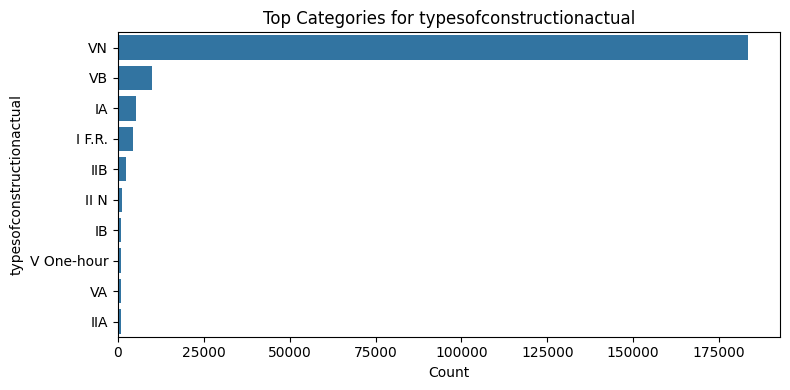

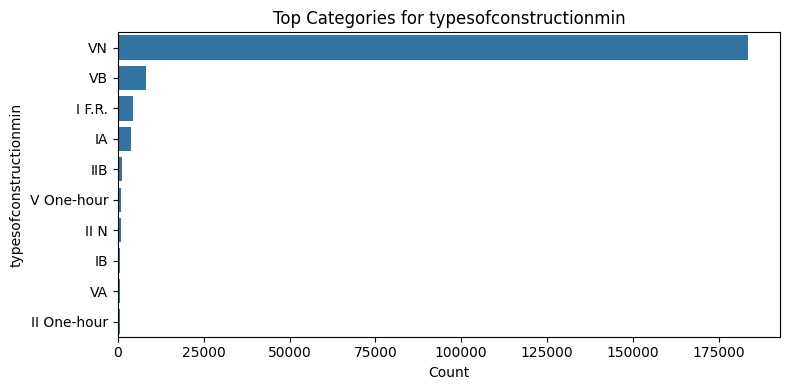

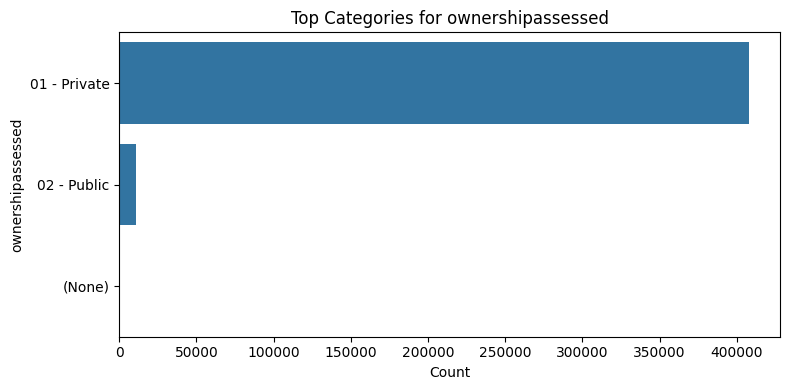

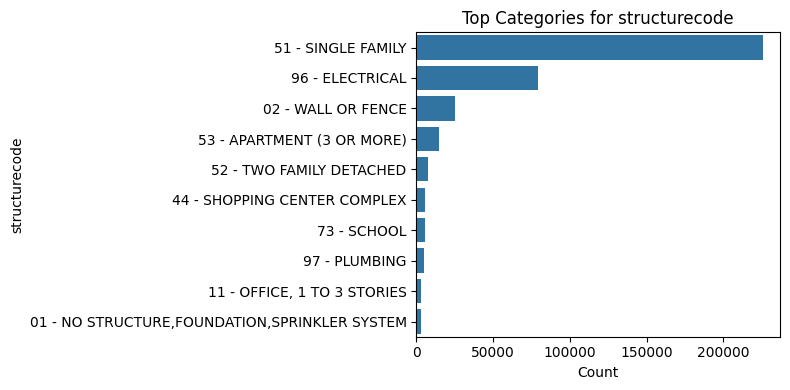

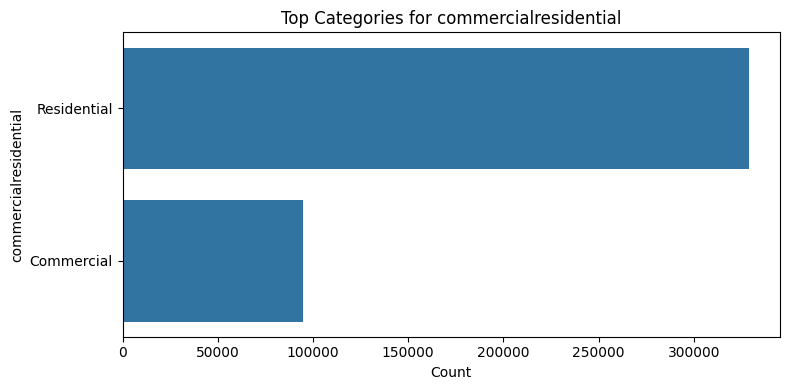

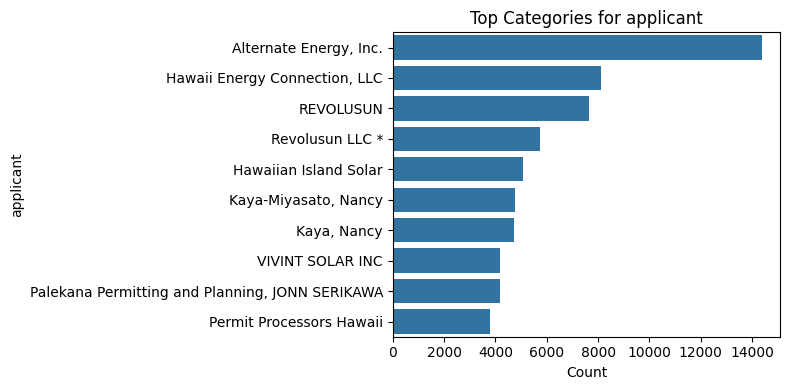

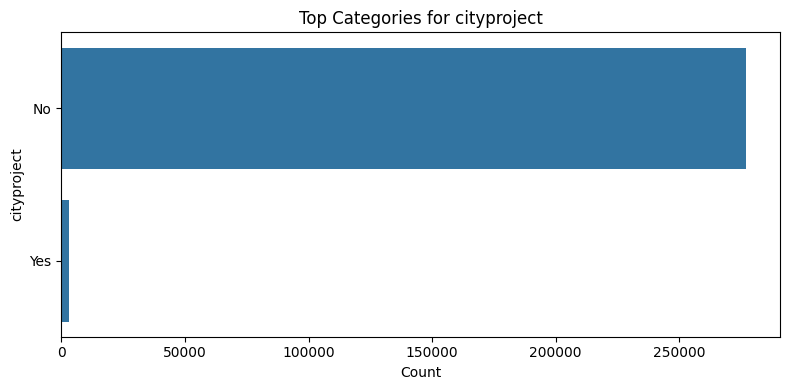

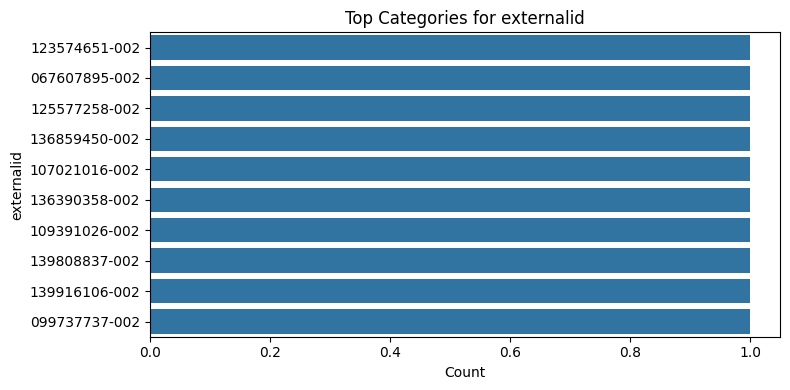

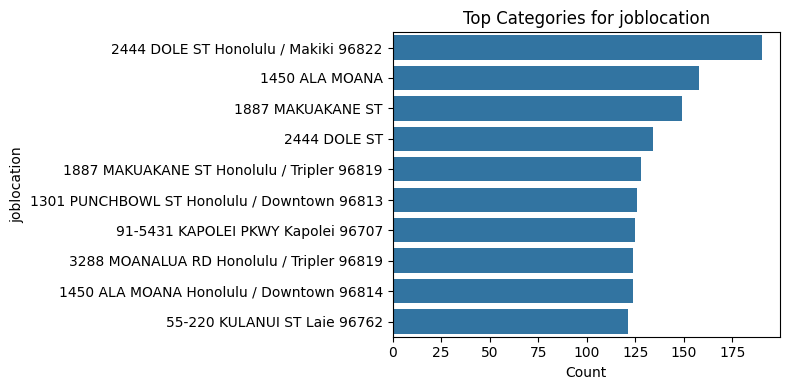

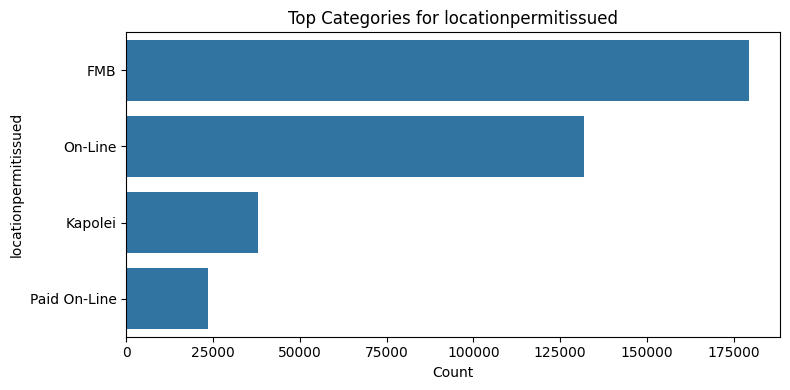

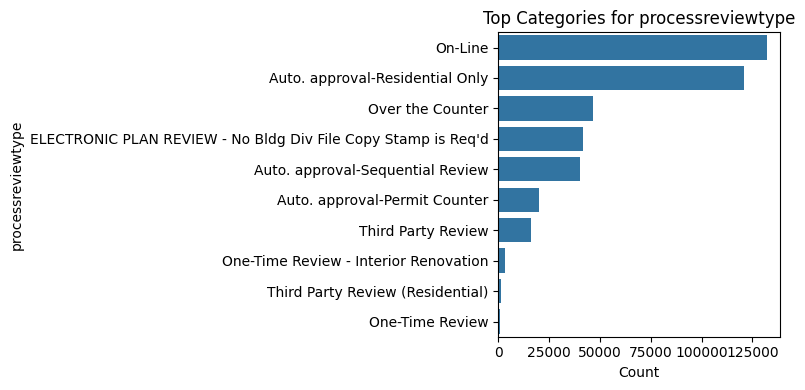

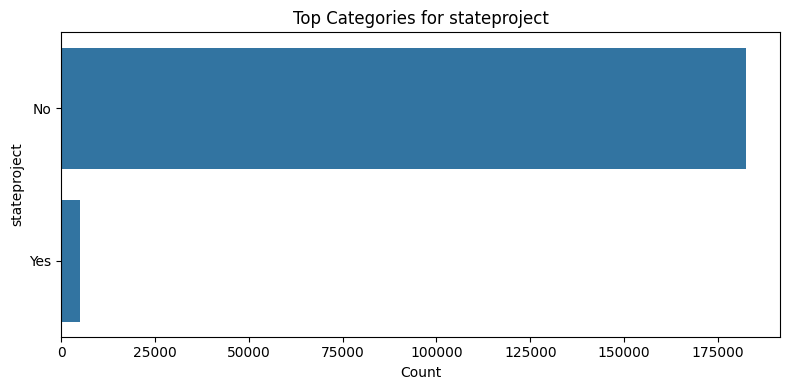

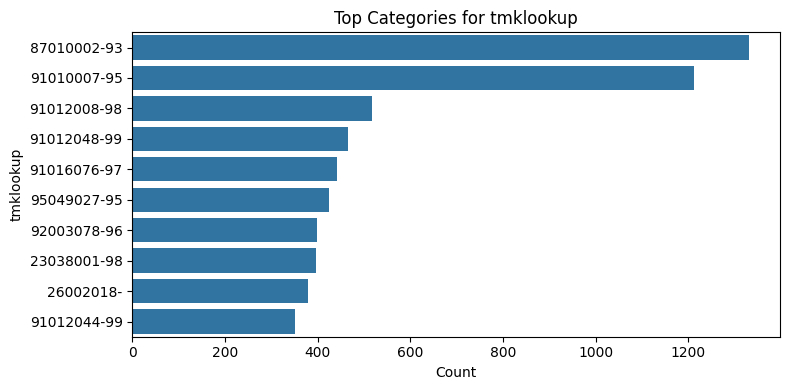

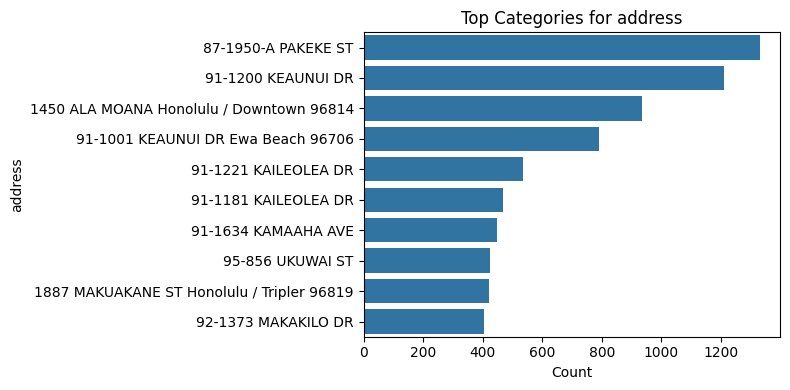

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_cols:
    
    top_categories = df[col].value_counts().nlargest(10)
    
    plt.figure(figsize=(8,4))
    sns.barplot(x=top_categories.values, y=top_categories.index)
    
    plt.title(f"Top Categories for {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

## Step 21 — Bar Chart Visualization for Categorical Variables

After computing both the frequency tables and percentage distributions for the categorical variables, the next step is to visualize these distributions using **bar charts**.

### Objective

The goal of this step is to visually explore how categorical values are distributed across the dataset. Visualization makes it easier to identify dominant categories, rare categories, and overall distribution patterns.

Bar charts help reveal:

- the **most frequent categories**
- **imbalances between categories**
- potential **dominant patterns in the dataset**
- categorical variables with **high cardinality**

### Method Used

Because the dataset contains a very large number of unique categorical values, plotting every category would make the charts unreadable and computationally heavy.

To solve this, I visualized only the **top 10 most frequent categories** for each categorical variable. This was achieved using:

- `value_counts()` to compute category frequencies
- `nlargest(10)` to select the most frequent categories
- `seaborn.barplot()` to generate the visualizations

Each chart displays the **Top 10 categories by frequency**, allowing clearer interpretation of the most dominant categories.

### Key Observations

Several interesting patterns emerge from the visualizations:

**Building Permit Type**
- The majority of permits involve **additions, alterations, or repairs with no change in units**.
- **New construction permits** represent the second largest category.

**Contractor Information**
- A large proportion of records contain **NONE**, indicating that contractor details may often be missing.
- Many contractor names appear only a few times, indicating **high-cardinality categorical variables**.

**Occupancy Groups**
- **Single-family dwellings dominate the dataset**, suggesting that residential building permits make up the majority of records.

**Commercial vs Residential**
- Residential permits significantly outnumber commercial permits, confirming the residential dominance observed earlier.

**State / City Projects**
- Most permits are **not associated with city or state projects**, indicating that the dataset largely represents private developments.

**Location-Based Columns**
- Variables such as **TMK lookup, external ID, and address** contain many unique values and behave more like **identifiers rather than analytical categorical variables**.

### Importance of This Step

Visualizing categorical distributions helps quickly identify dominant categories and potential imbalances. These insights are essential before proceeding to feature engineering or predictive modeling.

### Next Step

With both numerical and categorical **univariate analysis completed**, the next stage of the workflow is:

**Outlier Detection using the Interquartile Range (IQR) method** for numerical variables. This step will help identify extreme values that may influence the performance of machine learning models.

In [32]:
# Step 22.1 — Correlation Matrix

# Select only numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Compute correlation matrix
correlation_matrix = df[num_cols].corr()

# Display correlation matrix
correlation_matrix

,acceptedvalue,addition,alteration,buildingpermitno,demolition,electricalwork,estimatedvalueofwork,fence,floodhazardcomplied,floodhazardexempt,...,isstateespprojectbp,isstateespprojectsd,numunitsadd,objectid,statusid,coissued,finalcoissued,relocationfrom,relocationto,electricvehiclecharger
acceptedvalue,1.000000,-0.004479,0.011542,0.019969,-0.005044,0.017893,0.915176,0.000908,0.025508,0.006335,...,NaN,NaN,0.331688,0.017427,0.000824,0.042684,0.045461,-0.000953,-0.000993,0.002136
addition,-0.004479,1.000000,0.516835,-0.128989,-0.053381,0.092577,-0.007342,-0.036001,0.019720,-0.010556,...,NaN,NaN,-0.012857,-0.102322,-0.019669,-0.041063,-0.027027,-0.005496,-0.007548,-0.015892
alteration,0.011542,0.516835,1.000000,-0.060386,-0.075000,0.097402,0.006913,-0.096805,0.067756,0.113059,...,NaN,NaN,-0.023399,-0.063155,-0.030439,-0.052272,-0.036097,-0.007507,-0.009202,-0.022625
buildingpermitno,0.019969,-0.128989,-0.060386,1.000000,-0.013412,0.047453,0.019463,-0.058776,0.013066,0.003764,...,NaN,NaN,-0.044951,0.840751,-0.014170,0.078042,0.101891,-0.007822,-0.013905,0.047302
demolition,-0.005044,-0.053381,-0.075000,-0.013412,1.000000,-0.251419,-0.003007,-0.049537,-0.014617,-0.006020,...,NaN,NaN,-0.006979,0.009299,-0.009193,-0.027859,-0.019913,-0.002128,-0.003938,-0.001331
electricalwork,0.017893,0.092577,0.097402,0.047453,-0.251419,1.000000,0.015270,-0.270139,0.028905,-0.024777,...,NaN,NaN,0.028291,0.032046,-0.094856,0.100764,0.073714,-0.030796,-0.005404,-0.036143
estimatedvalueofwork,0.915176,-0.007342,0.006913,0.019463,-0.003007,0.015270,1.000000,-0.000957,0.019176,0.003251,...,NaN,NaN,0.347172,0.025851,0.000609,0.031639,0.035198,-0.000910,-0.001007,0.015946
fence,0.000908,-0.036001,-0.096805,-0.058776,-0.049537,-0.270139,-0.000957,1.000000,-0.000574,0.006240,...,NaN,NaN,0.009144,-0.068319,-0.013663,0.140172,0.062060,-0.006737,-0.007762,-0.004741
floodhazardcomplied,0.025508,0.019720,0.067756,0.013066,-0.014617,0.028905,0.019176,-0.000574,1.000000,-0.016778,...,NaN,NaN,0.019622,-0.011777,-0.005833,0.062775,0.046613,-0.001948,0.015384,-0.001670
floodhazardexempt,0.006335,-0.010556,0.113059,0.003764,-0.006020,-0.024777,0.003251,0.006240,-0.016778,1.000000,...,NaN,NaN,-0.006546,-0.018798,-0.012471,-0.013637,-0.014037,0.003283,-0.003036,-0.000165


## Step 22.1 — Correlation Matrix (Bivariate Analysis)

In this step, I computed the **correlation matrix** for all numerical variables in the dataset to examine the relationships between them.

A correlation matrix shows the **strength and direction of linear relationships** between pairs of numerical variables.

### Method Used

First, I selected only the numerical columns from the dataset using:

- `df.select_dtypes(include=['int64','float64'])`

This ensures that the correlation calculation is applied only to quantitative variables.

I then computed the correlation values using the Pandas `corr()` function.

### Interpretation of Correlation Values

Correlation coefficients range between **-1 and +1**:

- **+1** → Perfect positive relationship (variables increase together)
- **0** → No linear relationship
- **-1** → Perfect negative relationship (one increases while the other decreases)

Values closer to **±1 indicate stronger relationships**, while values near **0 indicate weak or no relationship**.

### Observations

From the correlation matrix, most variables show **low to moderate correlations**, indicating that the dataset does not have strong linear dependencies between many variables.

However, a few notable relationships can be observed:

- **acceptedvalue and estimatedvalueofwork show a very strong positive correlation (~0.91)**, which suggests that permits with higher accepted values tend to also have higher estimated work values.
- **feescollected also shows moderate correlation with acceptedvalue and estimatedvalueofwork**, which is expected because permit fees are often calculated based on project value.
- Many other variables have correlations close to **zero**, indicating weak relationships between those features.

The presence of several **NaN values** in the matrix suggests that some columns may contain missing values or constant values that prevent correlation from being computed.

### Importance of This Step

Computing the correlation matrix helps to:

- identify relationships between variables
- detect potential **multicollinearity**
- understand which variables may influence each other
- guide **feature selection** for future modeling

### Next Step

To make these relationships easier to interpret visually, the next step is to create a **correlation heatmap**, which will highlight strong and weak relationships using color intensity.

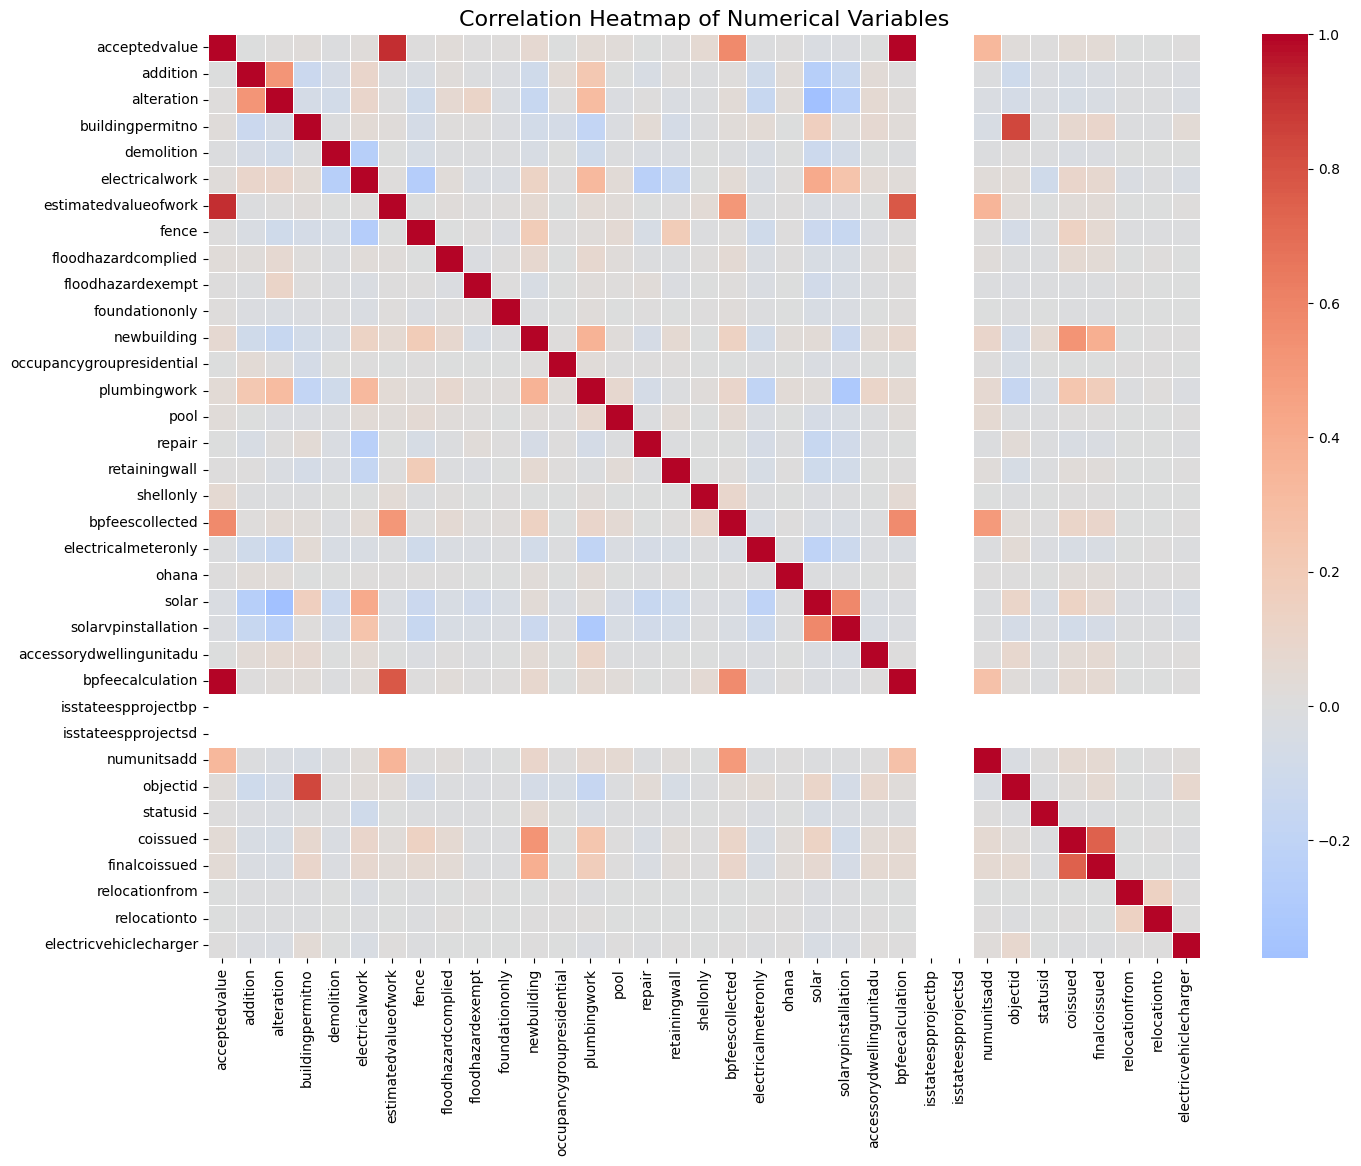

In [33]:
# Step 22.2 — Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap of Numerical Variables", fontsize=16)
plt.show()

## Step 22.2 — Correlation Heatmap (Bivariate Analysis)

After computing the correlation matrix in the previous step, I visualized the relationships between numerical variables using a **correlation heatmap**.

### Objective

The objective of this step is to provide a **visual representation of the correlation matrix**, making it easier to identify patterns and relationships between variables in the dataset.

While the correlation matrix displays numerical values, the heatmap highlights the strength of relationships using **color intensity**, allowing strong and weak correlations to be quickly identified.

### Method Used

To generate the heatmap:

1. I selected all numerical variables from the dataset using `select_dtypes()`.
2. I computed the pairwise correlations using the `corr()` function.
3. I visualized the results using **Seaborn’s heatmap function**.

The **coolwarm color palette** was used to represent correlation values:

- **Red colors** represent strong positive correlations.
- **Blue colors** represent negative correlations.
- **Light or neutral colors** indicate weak or near-zero correlations.

The diagonal values appear as deep red because each variable has a **perfect correlation with itself (correlation = 1)**.

### Observations

From the heatmap, several patterns can be observed:

- **acceptedvalue and estimatedvalueofwork display a strong positive correlation**, suggesting that permits with higher accepted values tend to have higher estimated construction values.
- **feescollected also shows a moderate positive relationship with permit value variables**, which is expected since permit fees are typically based on project cost.
- Many variables show **weak correlations close to zero**, indicating that most features operate independently.
- Some blank or neutral areas in the heatmap correspond to **NaN correlations**, which may occur when variables contain constant values or missing data.

### Importance of This Step

The correlation heatmap is important because it helps to:

- visually identify relationships between variables
- detect possible **multicollinearity**
- understand how numerical features interact
- guide **feature selection for machine learning models**

### Next Step

After analyzing correlations between numerical variables, the next step is to explore **scatter plots for key variable pairs** in order to further investigate relationships and trends between important numerical features.

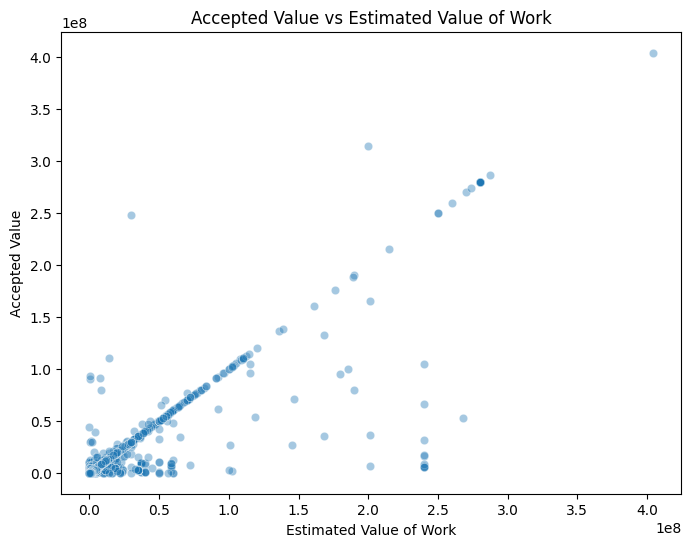

In [34]:
# Step 22.3.1 — Scatter Plot Relationships

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["estimatedvalueofwork"], y=df["acceptedvalue"], alpha=0.4)

plt.title("Accepted Value vs Estimated Value of Work")
plt.xlabel("Estimated Value of Work")
plt.ylabel("Accepted Value")

plt.show()

## Step 22.3.1 — Scatter Plot: Accepted Value vs Estimated Value of Work

To further investigate the relationship identified in the correlation analysis, I generated a scatter plot comparing **accepted permit value** with the **estimated value of work**.

### Objective

The purpose of this visualization is to observe how the accepted permit value relates to the estimated cost of construction work. Scatter plots allow us to identify:

- the direction of relationships between variables
- clusters of observations
- potential outliers
- the overall pattern of the data

### Observations

The scatter plot shows a **strong positive relationship** between the estimated value of work and the accepted permit value.

Several patterns can be observed:

- Most permits cluster in the **lower value range**, indicating that the majority of construction projects are relatively small in cost.
- As the **estimated value of work increases**, the **accepted value also increases**, confirming the strong positive correlation identified earlier in the correlation matrix and heatmap.
- A few points appear far from the main cluster, representing **high-value construction projects**, which may be potential outliers.

### Interpretation

This relationship is expected because permit authorities typically determine the **accepted value of a permit based on the estimated project cost**. Therefore, higher estimated construction costs tend to correspond with higher accepted permit values.

### Importance of This Step

This visualization helps confirm the strong correlation observed earlier and provides additional insight into the distribution and spread of project values within the dataset.

### Next Step

Additional scatter plots will be generated to explore relationships between **permit values and fees collected**, helping to further understand financial patterns within the permit data.

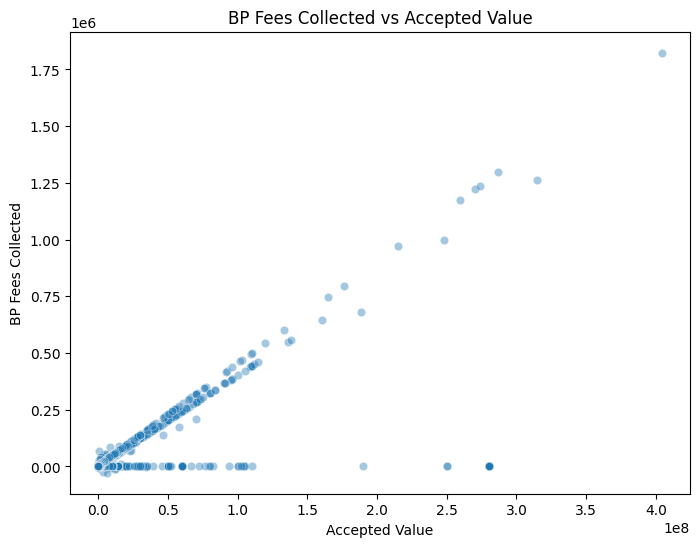

In [35]:
# Step 22.3.2 — Scatter Plot Relationships

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["acceptedvalue"], y=df["bpfeescollected"], alpha=0.4)

plt.title("BP Fees Collected vs Accepted Value")
plt.xlabel("Accepted Value")
plt.ylabel("BP Fees Collected")

plt.show()

## Step 22.3.2 — Scatter Plot: BP Fees Collected vs Accepted Value

To further analyze the financial characteristics of building permits, I generated a scatter plot comparing **accepted permit value** with **building permit fees collected (BP Fees Collected)**.

### Objective

The purpose of this visualization is to understand how permit fees relate to the accepted value of construction projects. Scatter plots allow us to observe:

- how permit fees scale with project value
- the distribution of permit fee amounts
- potential anomalies or unusual fee values
- the overall trend between these two financial variables

### Observations

The scatter plot reveals a **clear positive relationship** between accepted permit value and the fees collected.

Several patterns are visible:

- Most observations cluster in the **lower value range**, indicating that the majority of building permits correspond to relatively smaller projects.
- As the **accepted permit value increases**, the **BP fees collected also increase**, suggesting that permit fees are typically calculated as a function of project value.
- A number of points lie directly along an upward trend line, indicating a **consistent fee calculation structure** used by the permitting authority.
- A few points appear significantly higher than the main cluster, representing **large-scale construction projects** with much higher permit values and associated fees.

### Interpretation

This relationship is expected because building permit fees are usually determined based on **construction value or project cost**. Therefore, projects with higher accepted values naturally generate higher permit fees.

### Importance of This Step

This visualization confirms the financial relationship between **permit valuation and fee collection**, which is important for understanding the economic structure of the building permit system.

It also helps identify potential anomalies where **fees may appear unusually low or high relative to the accepted project value**.

### Next Step

The next scatter plot will examine the relationship between **estimated construction value and BP fees collected**, providing additional insight into how permit fees relate to estimated project costs.

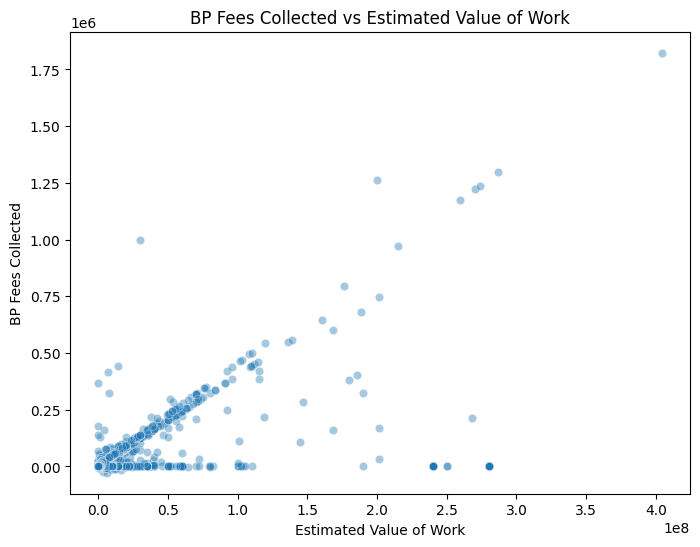

In [36]:
# Step 22.3.3 — Scatter Plot Relationships
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["estimatedvalueofwork"], y=df["bpfeescollected"], alpha=0.4)

plt.title("BP Fees Collected vs Estimated Value of Work")
plt.xlabel("Estimated Value of Work")
plt.ylabel("BP Fees Collected")

plt.show()

## Step 22.3.3 — Scatter Plot: BP Fees Collected vs Estimated Value of Work

To further analyze the financial relationships within the building permit dataset, I generated a scatter plot comparing **BP fees collected** with the **estimated value of construction work**.

### Objective

The objective of this visualization is to explore how building permit fees relate to the estimated cost of construction projects. Scatter plots allow us to observe:

- the direction and strength of relationships between variables
- clusters of similar project values
- potential outliers or unusually high permit fees
- the overall pattern between estimated construction costs and fees collected

### Observations

The scatter plot reveals a **clear positive relationship** between the estimated value of work and the building permit fees collected.

Key patterns include:

- Most observations are concentrated in the **lower value range**, indicating that the majority of permits correspond to smaller construction projects.
- As the **estimated construction value increases**, the **permit fees collected also increase**, suggesting a consistent fee calculation structure based on project value.
- A number of observations follow an upward trend line, which indicates that permit fees scale proportionally with estimated construction costs.
- A few points appear significantly distant from the main cluster, representing **large-scale construction projects** that generate substantially higher permit fees.

### Interpretation

This relationship is expected because building permit fees are typically determined using **fee schedules based on estimated construction value**. Larger projects therefore tend to produce higher permit fees.

### Importance of This Step

This visualization helps confirm the financial relationship between **construction project value and permit fee generation**, providing insight into how revenue from building permits is associated with construction activity.

It also helps identify potential anomalies where **fees appear unusually low or high relative to estimated construction value**.

### Next Step

After completing the scatter plot analysis of key financial variables, the next step in the workflow is **outlier detection**. This will be performed using statistical techniques such as the **Interquartile Range (IQR) method** to identify extreme values that may influence further analysis or modeling.

In [37]:
# Step 24.1 — Detect Outliers Using IQR

import pandas as pd

outlier_summary = []

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        "Column": col,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(by="Outlier Count", ascending=False)

,Column,Outlier Count
29,statusid,95714
2,alteration,95581
22,solarvpinstallation,68234
6,estimatedvalueofwork,66458
0,acceptedvalue,59950
24,bpfeecalculation,55321
18,bpfeescollected,51568
1,addition,49526
7,fence,46959
11,newbuilding,34681


### Step 24.1 — Detecting Outliers Using the Interquartile Range (IQR) Method

In this step, I applied the **Interquartile Range (IQR) method** to identify potential outliers within the numerical variables of the dataset.

The IQR is a statistical measure used to describe the spread of the middle 50% of the data. It is calculated as:

IQR = Q3 − Q1

Where:

- **Q1 (First Quartile)** represents the 25th percentile of the data.
- **Q3 (Third Quartile)** represents the 75th percentile of the data.

Using the IQR, the boundaries for identifying outliers are calculated as:

Lower Bound = Q1 − 1.5 × IQR  
Upper Bound = Q3 + 1.5 × IQR

Any observation that falls **below the lower bound** or **above the upper bound** is considered a potential outlier.

To implement this, I iterated through all numerical columns in the dataset and computed the number of observations that fall outside the calculated IQR boundaries. The results were stored in a summary table showing the **number of detected outliers per column**.

### Observations

The output shows that several variables contain a large number of potential outliers. Notably:

- **statusid**
- **alteration**
- **solarinstallation**
- **estimatedvalueofwork**
- **acceptedvalue**
- **bpfeecalculation**
- **bpfeescollected**

These variables exhibit high outlier counts because the dataset contains many **extreme or highly skewed values**, particularly in financial and permit-related features such as project value and collected fees.

This pattern is expected in real-world administrative or financial datasets, where a small number of projects may have significantly higher monetary values than the majority of observations.

### Importance of This Step

Identifying outliers is essential because extreme values can:

- Distort statistical summaries
- Affect correlations between variables
- Reduce the performance of machine learning models
- Influence regression coefficients

Detecting these values early allows us to decide whether to **remove, cap, or transform them** in the following stages of the analysis.

### Next Step

After identifying the presence of outliers, the next step will focus on **handling outliers appropriately**, which may include techniques such as **IQR capping, transformation, or removal depending on the distribution and analytical objectives**.

In [38]:
# Step 24.2 — Calculate IQR Bounds

iqr_bounds = []

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    iqr_bounds.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound
    })

iqr_bounds_df = pd.DataFrame(iqr_bounds)

iqr_bounds_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound
0,acceptedvalue,4200.00,45000.00,40800.00,-5.700000e+04,1.062000e+05
1,addition,0.00,0.00,0.00,0.000000e+00,0.000000e+00
2,alteration,0.00,0.00,0.00,0.000000e+00,0.000000e+00
3,buildingpermitno,643573.25,830155.75,186582.50,3.636995e+05,1.110030e+06
4,demolition,0.00,0.00,0.00,0.000000e+00,0.000000e+00
5,electricalwork,0.00,1.00,1.00,-1.500000e+00,2.500000e+00
6,estimatedvalueofwork,4098.63,45360.00,41261.37,-5.779343e+04,1.072521e+05
7,fence,0.00,0.00,0.00,0.000000e+00,0.000000e+00
8,floodhazardcomplied,0.00,0.00,0.00,0.000000e+00,0.000000e+00
9,floodhazardexempt,0.00,0.00,0.00,0.000000e+00,0.000000e+00


### Step 24.2 — Calculating IQR Boundaries for Each Numerical Feature

After identifying the presence of potential outliers using the IQR method, the next step was to calculate the **exact statistical boundaries** that define outliers for each numerical variable.

For every numerical column in the dataset, I computed:

- **First Quartile (Q1)** – the 25th percentile of the distribution  
- **Third Quartile (Q3)** – the 75th percentile of the distribution  
- **Interquartile Range (IQR)** – calculated as:

IQR = Q3 − Q1

Using the IQR, the acceptable range of values for each variable was determined using the following formulas:

Lower Bound = Q1 − (1.5 × IQR)  
Upper Bound = Q3 + (1.5 × IQR)

Any observation falling **below the lower bound** or **above the upper bound** is considered a potential outlier.

To make the results interpretable, a summary table was generated containing:

- Column name  
- Q1 value  
- Q3 value  
- Interquartile Range (IQR)  
- Lower bound  
- Upper bound  

This table defines the **statistical thresholds used to identify extreme observations** in each numerical feature.

### Observations

From the results:

- Financial variables such as **acceptedvalue**, **estimatedvalueofwork**, **bpfeescollected**, and **bpfeecalculation** have large IQR ranges, indicating a **wide spread of values and the presence of extreme observations**.
- Many binary or indicator variables (for example **addition**, **alteration**, **fence**, **foundationonly**, etc.) have an IQR of **0**, meaning most values are either 0 or 1 and therefore do not exhibit traditional outliers.
- Administrative identifier columns such as **objectid** naturally show large ranges because they represent unique identifiers rather than measured quantities.

These results confirm that **outliers are primarily concentrated in the financial and project-value variables**, which is expected in real-world permit and construction datasets where a few large projects can have significantly higher values than the majority.

### Importance of This Step

Calculating these boundaries is critical because it allows us to:

- Statistically define extreme values
- Understand how skewed certain variables are
- Prepare the dataset for **outlier treatment**

### Next Step

The next stage will focus on **handling the detected outliers** using an appropriate method such as **capping, removal, or transformation**, depending on how the extreme values affect the distribution of each variable.

In [39]:
# Step 24.3 — Remove Outliers Using IQR

df_removed = df.copy()

for col in num_cols:
    
    Q1 = df_removed[col].quantile(0.25)
    Q3 = df_removed[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    df_removed = df_removed[
        (df_removed[col] >= lower_bound) &
        (df_removed[col] <= upper_bound)
    ]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_removed.shape)

Original Shape: (432021, 64)
After Removing Outliers: (31269, 64)


### Step 24.3 — Removing Outliers Using the IQR Method

In this step, I created a new dataset by **removing observations identified as outliers using the Interquartile Range (IQR) method**.

For each numerical variable, the lower and upper bounds were calculated using the standard IQR formulas:

Lower Bound = Q1 − (1.5 × IQR)  
Upper Bound = Q3 + (1.5 × IQR)

Any observation that fell outside these boundaries was considered a potential outlier and removed from the dataset.

To ensure that the original dataset remained unchanged, a new dataset called **`df_removed`** was created as a copy of the original dataframe. The filtering process was then applied sequentially to each numerical column to remove values that fell outside the acceptable IQR range.

### Output

Original Dataset Shape  
(432021, 64)

Dataset Shape After Removing Outliers  
(31269, 64)

### Observations

A significant number of observations were removed during this process. The dataset size reduced dramatically from **432,021 rows to 31,269 rows**. This indicates that many variables in the dataset contain values outside the calculated IQR bounds.

This behavior is common in real-world financial and administrative datasets, especially where variables such as **accepted project value, estimated work value, and permit-related fees** have highly skewed distributions with extreme values.

However, removing such a large number of records may lead to **loss of important information**, particularly if the extreme values represent legitimate large construction projects.

### Importance of This Step

Outlier removal helps reduce the influence of extreme observations that may distort statistical analysis or machine learning models. However, because this method significantly reduces the dataset size, it must be carefully evaluated against other outlier-handling approaches.

### Next Step

To avoid excessive data loss, additional outlier-handling strategies will be explored, including:

• **Outlier Capping (Winsorization)**  
• **Log Transformation**

These methods will allow comparison between different dataset versions to determine which approach preserves the most useful information while improving data quality.

In [40]:
# Step 24.4 — Cap Outliers Using IQR

df_capped = df.copy()

for col in num_cols:
    
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print("Original Shape:", df.shape)
print("After Capping Outliers:", df_capped.shape)

Original Shape: (432021, 64)
After Capping Outliers: (432021, 64)


### Step 24.4 — Handling Outliers Using IQR Capping (Winsorization)

In this step, I applied **outlier capping**, also known as **Winsorization**, to limit the effect of extreme values while preserving all observations in the dataset.

Instead of removing rows, this method adjusts extreme values so that they fall within the acceptable statistical range defined by the **Interquartile Range (IQR)**.

For each numerical variable, the following calculations were performed:

- **Q1 (First Quartile)** — the 25th percentile  
- **Q3 (Third Quartile)** — the 75th percentile  
- **IQR (Interquartile Range)**

IQR = Q3 − Q1

Using these values, the acceptable range for each variable was calculated as:

Lower Bound = Q1 − (1.5 × IQR)  
Upper Bound = Q3 + (1.5 × IQR)

Any values below the lower bound were replaced with the lower bound, and any values above the upper bound were replaced with the upper bound using the `clip()` function.

### Output

Original Dataset Shape  
(432021, 64)

Dataset Shape After Capping Outliers  
(432021, 64)

### Observations

Unlike the outlier removal approach, **no rows were removed** from the dataset. Instead, extreme values were adjusted to fall within the calculated IQR limits.

This method is particularly effective for datasets that contain **highly skewed financial or operational variables**, such as:

- accepted project value
- estimated construction value
- permit-related fees

These variables often contain legitimate but rare extreme values, and removing them could result in significant data loss.

### Importance of This Step

Outlier capping helps stabilize the distribution of numerical variables while maintaining the full dataset size. By limiting extreme values rather than removing them, the dataset remains suitable for downstream analysis and machine learning while reducing the influence of extreme observations.

### Next Step

The next step will apply **log transformation** to highly skewed numerical variables. This transformation helps reduce skewness and makes distributions closer to normal, allowing comparison between three different outlier-handling strategies:

- Outlier Removal  
- Outlier Capping  
- Log Transformation

In [41]:
# Step 24.5 — Log Transformation for Numerical Columns

import numpy as np

df_transformed = df.copy()

for col in num_cols:
    
    if (df_transformed[col] > 0).any():   # avoid log(0)
        df_transformed[col] = np.log1p(df_transformed[col])

print("Original Shape:", df.shape)
print("After Log Transformation:", df_transformed.shape)

Original Shape: (432021, 64)
After Log Transformation: (432021, 64)


C:\Users\marty\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\marty\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Step 24.5 — Applying Log Transformation to Numerical Variables

In this step, I applied **log transformation** to the numerical variables in the dataset to reduce skewness and stabilize the distribution of values.

Many variables in this dataset, particularly financial variables such as **accepted project value**, **estimated value of work**, and **permit-related fees**, exhibit highly **right-skewed distributions**. In such cases, a small number of extremely large values can dominate the distribution and negatively influence statistical analysis and machine learning models.

To address this, I applied the **natural logarithm transformation using the `log1p()` function**, which computes:

log(1 + x)

The `log1p()` function is preferred because it allows safe transformation of values that may contain **zero**, avoiding undefined logarithmic calculations.

### Output

Original Dataset Shape  
(432021, 64)

Dataset Shape After Log Transformation  
(432021, 64)

### Observations

The transformation does not remove any rows from the dataset. Instead, it **compresses large values** and reduces the influence of extreme observations.

Log transformation is particularly effective for variables with **long right tails**, where a few very large values distort the overall distribution.

Compared to outlier removal and capping:

- **Outlier Removal** reduces dataset size significantly.
- **Outlier Capping** limits extreme values but preserves the original scale.
- **Log Transformation** changes the scale of the variables to reduce skewness and improve distribution balance.

### Importance of This Step

Applying log transformation can improve the performance and stability of machine learning models by:

- Reducing skewness
- Compressing extreme values
- Making variable distributions closer to normal

### Next Step

At this stage, three dataset versions have been created for comparison:

- **df_removed** — dataset with outliers removed  
- **df_capped** — dataset with outliers capped using IQR bounds  
- **df_transformed** — dataset with log-transformed numerical variables  

The next step will compare these dataset versions to determine which outlier-handling strategy provides the most stable and reliable dataset for further analysis and modeling.

In [42]:
# Step 24.6 — Compare Dataset Sizes

comparison = {
    "Original Dataset": df.shape,
    "Outliers Removed": df_removed.shape,
    "Outliers Capped": df_capped.shape,
    "Log Transformed": df_transformed.shape
}

comparison

{'Original Dataset': (432021, 64),
 'Outliers Removed': (31269, 64),
 'Outliers Capped': (432021, 64),
 'Log Transformed': (432021, 64)}

### Step 24.6 — Comparing Outlier Handling Methods

After applying three different outlier-handling strategies, I compared the resulting dataset versions to evaluate how each method affected the dataset structure.

The three approaches applied were:

- **Outlier Removal (IQR Filtering)**
- **Outlier Capping (Winsorization)**
- **Log Transformation**

### Dataset Size Comparison

Original Dataset  
(432021, 64)

Dataset After Outlier Removal  
(31269, 64)

Dataset After Outlier Capping  
(432021, 64)

Dataset After Log Transformation  
(432021, 64)

### Observations

The **outlier removal approach** dramatically reduced the dataset size, removing a very large number of observations. While this method successfully eliminates extreme values, it also removes many potentially valid records. In this case, the dataset was reduced from **432,021 rows to 31,269 rows**, representing a significant loss of data.

The **outlier capping method** preserved the full dataset size while limiting extreme values to the acceptable IQR boundaries. This ensures that no observations are lost while still reducing the influence of extreme values.

Similarly, the **log transformation approach** also preserved the entire dataset while compressing large values and reducing skewness in variables with long right tails.

### Interpretation

The comparison suggests that **outlier removal may be too aggressive for this dataset**, particularly because financial and construction-related variables often contain legitimate extreme values.

Both **outlier capping** and **log transformation** maintain the dataset size while reducing the influence of extreme observations, making them more appropriate for further analysis.

### Next Step

The next step will compare the **summary statistics of the different dataset versions** to further evaluate how each outlier-handling method affects the distribution of the numerical variables before selecting the most suitable dataset for downstream analysis and modeling.

In [43]:
# Step 24.6.2 — Compare Summary Statistics

df.describe()

,acceptedvalue,addition,alteration,buildingpermitno,demolition,electricalwork,estimatedvalueofwork,fence,floodhazardcomplied,floodhazardexempt,...,isstateespprojectbp,isstateespprojectsd,numunitsadd,objectid,statusid,coissued,finalcoissued,relocationfrom,relocationto,electricvehiclecharger
count,3.936920e+05,432021.000000,432021.000000,373166.000000,432021.000000,432021.000000,4.287550e+05,432021.000000,432021.000000,432021.000000,...,432021.0,432021.0,209381.000000,4.320210e+05,432021.000000,432021.000000,432021.000000,432021.000000,432021.000000,432021.000000
mean,1.716750e+05,0.114638,0.221242,734840.071684,0.026737,0.737811,2.152719e+05,0.108696,0.013585,0.032785,...,0.0,0.0,0.387351,5.758884e+07,4406.407050,0.031066,0.017474,0.000565,0.000727,0.004153
min,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,0.0,0.0,-1.000000,8.805740e+06,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.200000e+03,0.000000,0.000000,643573.250000,0.000000,0.000000,4.098630e+03,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,3.227546e+07,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.750000e+04,0.000000,0.000000,736864.500000,0.000000,1.000000,1.693500e+04,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,5.134022e+07,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000e+04,0.000000,0.000000,830155.750000,0.000000,1.000000,4.536000e+04,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,7.441349e+07,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4.043500e+08,1.000000,1.000000,924451.000000,1.000000,1.000000,5.000000e+08,1.000000,1.000000,1.000000,...,0.0,0.0,1005.000000,1.401547e+08,826803.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,3.408442e+06,0.318585,0.415083,114695.844879,0.161314,0.439825,4.209863e+06,0.311258,0.115760,0.178075,...,0.0,0.0,7.510852,3.117886e+07,58350.448873,0.173495,0.131028,0.023759,0.026950,0.064307


### Step 24.6.2 — Summary Statistics of Numerical Variables

To further understand the distribution of the dataset after outlier analysis, I generated **summary statistics for all numerical variables** using the `describe()` function.

This step provides a statistical overview of the dataset, including:

- **Count** – number of non-missing observations  
- **Mean** – average value  
- **Minimum and Maximum values**  
- **Quartiles (25%, 50%, 75%)**  
- **Standard deviation (std)**

These metrics help evaluate the **spread and distribution of numerical variables** and allow identification of variables with large ranges or extreme values.

### Key Observations

Several variables such as **acceptedvalue**, **estimatedvalueofwork**, and **buildingpermitno** exhibit **very large maximum values compared to their median values**, indicating strong right-skewness and the presence of extreme observations.

For example:

- **acceptedvalue**
  - Median ≈ 17,500
  - Maximum ≈ 404,350,000

- **estimatedvalueofwork**
  - Median ≈ 16,935
  - Maximum ≈ 500,000,000

This large gap between **median and maximum values** confirms the earlier findings from the boxplots and IQR analysis that the dataset contains **significant outliers**.

Binary indicator variables such as **addition, alteration, demolition, electricalwork, and fence** show values between **0 and 1**, which confirms that these variables represent **binary categorical indicators rather than continuous numeric measures**.

### Interpretation

The summary statistics reinforce the need for **outlier treatment**, particularly for highly skewed financial variables such as construction costs and permit values.

Outlier-handling strategies such as **removal, capping, and log transformation** were therefore applied earlier to stabilize the distributions and reduce the influence of extreme values.

### Next Step

The next stage will compare the **summary statistics across the three dataset versions**:

- Dataset with **outliers removed**
- Dataset with **outliers capped**
- Dataset with **log-transformed variables**

This comparison will help determine **which dataset version provides the most stable and realistic distributions for modeling and further analysis**.

In [44]:
# Step 24.7 — Compare Summary Statistics Across Dataset Versions

summary_comparison = {
    "Original Dataset": df[num_cols].describe(),
    "Outliers Removed": df_removed[num_cols].describe(),
    "Outliers Capped": df_capped[num_cols].describe(),
    "Log Transformed": df_transformed[num_cols].describe()
}

summary_comparison

C:\Users\marty\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


{'Original Dataset':        acceptedvalue       addition     alteration  buildingpermitno  \
 count   3.936920e+05  432021.000000  432021.000000     373166.000000   
 mean    1.716750e+05       0.114638       0.221242     734840.071684   
 std     3.408442e+06       0.318585       0.415083     114695.844879   
 min     0.000000e+00       0.000000       0.000000          1.000000   
 25%     4.200000e+03       0.000000       0.000000     643573.250000   
 50%     1.750000e+04       0.000000       0.000000     736864.500000   
 75%     4.500000e+04       0.000000       0.000000     830155.750000   
 max     4.043500e+08       1.000000       1.000000     924451.000000   
 
           demolition  electricalwork  estimatedvalueofwork          fence  \
 count  432021.000000   432021.000000          4.287550e+05  432021.000000   
 mean        0.026737        0.737811          2.152719e+05       0.108696   
 std         0.161314        0.439825          4.209863e+06       0.311258   
 min     

### Step 24.7 — Comparing Summary Statistics Across Dataset Versions

To determine the most appropriate outlier-handling strategy, I compared the **summary statistics across four dataset versions**:

- Original dataset
- Dataset with **outliers removed**
- Dataset with **outliers capped using IQR**
- Dataset with **log-transformed numerical variables**

This comparison allows evaluation of how each method affects:

- Mean values
- Standard deviation
- Maximum values
- Overall data distribution

### Observations

#### Original Dataset
The original dataset contains **extreme values**, particularly in financial variables such as:

- `acceptedvalue`
- `estimatedvalueofwork`
- `buildingpermitno`

These variables show **very large maximum values compared to their quartiles**, indicating strong right-skewness and the presence of outliers.

---

#### Outliers Removed Dataset
The dataset with outliers removed shows:

- A **significant reduction in dataset size**
- Reduced maximum values
- Lower standard deviations

However, this method removed a very large portion of the data:

- Original rows: **432,021**
- Remaining rows after removal: **31,269**

This indicates that the IQR filtering removed a substantial number of observations, which may result in **loss of potentially useful information**.

---

#### Outliers Capped Dataset
In the capped dataset:

- The **dataset size remains unchanged**
- Extreme values are limited to **IQR boundaries**
- The distribution becomes more stable without losing observations

This method reduces the influence of extreme values while preserving the entire dataset.

---

#### Log-Transformed Dataset
Log transformation compresses large values and reduces skewness.

Key effects observed:

- Large numerical ranges are compressed
- Distributions become closer to **normal distribution**
- Dataset size remains unchanged

However, log transformation may produce **NaN or infinite values if zeros exist**, which must be handled carefully.

---

### Interpretation

From the comparison:

- **Outlier Removal** is too aggressive for this dataset because it removes a very large number of records.
- **Outlier Capping** effectively controls extreme values while preserving the full dataset.
- **Log Transformation** reduces skewness but may introduce computational issues if zero values are present.

Given these observations, **outlier capping appears to be the most balanced approach**, as it stabilizes the dataset while retaining all observations.

---

### Next Step

The next stage will **select the most appropriate dataset version and proceed to feature engineering and model preparation for machine learning analysis.**

In [45]:
# Step 25 — Select Final Dataset for Modeling

final_df = df_capped.copy()

print("Final Dataset Shape:", final_df.shape)

Final Dataset Shape: (432021, 64)


### Step 25 — Selecting the Final Dataset for Modeling

After evaluating the three outlier-handling approaches, I selected the most appropriate dataset version for further analysis and machine learning modeling.

The dataset versions evaluated were:

- Dataset with **outliers removed using IQR filtering**
- Dataset with **outliers capped using IQR boundaries**
- Dataset with **log-transformed numerical variables**

### Observations from the Comparison

The **outlier removal approach** significantly reduced the dataset size, removing a large number of observations. While this method successfully eliminated extreme values, it also resulted in substantial data loss, reducing the dataset from **432,021 rows to 31,269 rows**.

The **log transformation approach** compressed large values and reduced skewness in numerical variables. However, some variables produced **infinite or undefined values**, which may introduce complications during model training.

The **outlier capping approach** successfully limited extreme values using IQR bounds while preserving the full dataset size. This method maintained the dataset integrity while reducing the influence of extreme observations.

### Final Dataset Selection

Based on these observations, the **outlier-capped dataset (`df_capped`)** was selected as the final dataset for modeling.

Key advantages of this approach include:

- Preserving the full dataset size
- Reducing the influence of extreme values
- Maintaining realistic data distributions

The selected dataset contains:

- **432,021 observations**
- **64 variables**

This dataset will now be used for the subsequent stages of the analysis.

### Next Step

The next stage will prepare the dataset for machine learning by:

- Identifying **feature variables (X)**
- Selecting the **target variable (y)**
- Preparing the dataset for **train-test splitting and model training**.

In [46]:
# Step 26.1 — Define Target Variable

target = "acceptedvalue"

y = final_df[target]

print("Target Variable:", target)
print("Target Shape:", y.shape)

Target Variable: acceptedvalue
Target Shape: (432021,)


In [47]:
# Step 26.2 — Define Feature Variables

X = final_df.drop(columns=[target])

print("Feature Dataset Shape:", X.shape)

Feature Dataset Shape: (432021, 63)


### Step 26 — Defining Target Variable and Feature Variables

To prepare the dataset for machine learning, I separated the dataset into **feature variables (X)** and the **target variable (y)**.

The objective of this analysis is to **predict the accepted value of building permits**, which represents the approved project value for each permit record.

### Target Variable

The target variable selected for prediction is:

`acceptedvalue`

This variable represents the financial value associated with each approved building permit and serves as the dependent variable in the regression model.

### Feature Variables

All remaining variables in the dataset were used as feature variables. These variables contain information related to permit characteristics such as:

- Permit identifiers
- Permit type indicators
- Construction activity indicators
- Project attributes

The feature dataset therefore includes all columns except the target variable.

### Dataset Shapes

Target Variable Shape  
(432021,)

Feature Dataset Shape  
(432021, 63)

### Next Step

The next step will prepare the data for machine learning by **splitting the dataset into training and testing sets**, which allows evaluation of model performance on unseen data.

In [48]:
# Step 27.1 — Import Train-Test Split

from sklearn.model_selection import train_test_split

In [49]:
# Step 27.3.1 — Drop High-Cardinality Columns Before Encoding

high_cardinality_cols = [
    'contractor',
    'contractorelectrical',
    'contractorplumbing',
    'externalfilenum',
    'planmaker',
    'applicant',
    'externalid',
    'joblocation',
    'locationpermitissued',
    'tmklookup',
    'address'
]

X_reduced = X.drop(columns=high_cardinality_cols, errors='ignore')

print("Reduced Feature Shape:", X_reduced.shape)

Reduced Feature Shape: (432021, 52)


### Step 27.3.1 — Removing High-Cardinality Columns Before Encoding

During the preparation of the feature dataset for machine learning, I identified several columns with extremely high cardinality. These columns contained a very large number of unique values, such as contractor names, addresses, external file identifiers, and location descriptors.

Examples of these columns include:

- contractor  
- contractorelectrical  
- contractorplumbing  
- externalfilenum  
- planmaker  
- applicant  
- externalid  
- joblocation  
- locationpermitissued  
- tmklookup  
- address  

### Why These Columns Were Removed

Columns with extremely high numbers of unique values can cause major issues during encoding, particularly when using techniques like one-hot encoding. These columns often behave more like identifiers than predictive variables, and encoding them would generate thousands of new dummy variables, significantly increasing memory usage and model complexity.

Removing these columns helps to:

- Prevent excessive memory consumption  
- Reduce feature dimensionality  
- Improve model efficiency  
- Avoid overfitting caused by near-unique identifiers  

### Result

After removing the high-cardinality columns, the feature dataset was reduced while still retaining meaningful predictive variables.

Feature Dataset Shape After Removal:

**(432,021 rows, 52 columns)**

This optimized feature matrix will now allow the remaining categorical columns to be encoded using a more memory-efficient strategy.

### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Dataset Size: **432,021 rows**  
Feature Columns After Reduction: **52 columns**  
Data Split Strategy: **80% Training / 20% Testing**

### Next Step

The next step will apply **frequency encoding** to the remaining categorical variables to convert them into numerical representations while maintaining a manageable feature size for model training.

In [50]:
# Step 27.3.2 — Frequency Encode Remaining Categorical Columns

X_encoded = X_reduced.copy()

cat_cols_reduced = X_encoded.select_dtypes(include=['object', 'category', 'bool']).columns

for col in cat_cols_reduced:
    freq_map = X_encoded[col].value_counts(normalize=True)
    X_encoded[col] = X_encoded[col].map(freq_map)

print("Encoded Feature Shape:", X_encoded.shape)
print("Remaining categorical columns:", X_encoded.select_dtypes(include=['object', 'category', 'bool']).shape[1])

Encoded Feature Shape: (432021, 52)
Remaining categorical columns: 0


### Step 27.3.2 — Frequency Encoding Remaining Categorical Columns

After removing the high-cardinality columns, I applied **frequency encoding** to the remaining categorical variables.

This step was necessary because the previous attempt to use one-hot encoding caused a memory error due to the size of the dataset. To avoid creating too many additional columns, I used a more memory-efficient encoding method.

### What Frequency Encoding Does

Frequency encoding replaces each category in a categorical column with its **relative frequency** in the dataset.

For example:

- common categories receive larger numeric values
- rare categories receive smaller numeric values

This allows categorical variables to be converted into numeric format without increasing the number of columns.

### Why This Method Was Chosen

Frequency encoding was selected because it:

- preserves the original number of columns
- avoids memory overflow
- makes the dataset fully numeric
- prepares the data for machine learning algorithms such as Linear Regression

### Result

After frequency encoding:

- the dataset shape remained unchanged
- all remaining categorical columns were successfully converted into numeric form

Encoded Feature Shape:  
**(432,021, 52)**

Remaining Categorical Columns:  
**0**

This confirms that the feature matrix is now fully numeric and ready for the next machine learning preparation steps.

### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Encoded Feature Shape: **(432,021, 52)**  
Remaining Categorical Columns: **0**

### Next Step

The next step will check for any missing values created during encoding, fill them if necessary, and then split the encoded dataset into training and testing sets for model training.

In [51]:
# Step 27.3.3 — Fill Missing Values After Frequency Encoding

X_encoded = X_encoded.fillna(0)

print("Missing values after encoding:", X_encoded.isna().sum().sum())

Missing values after encoding: 0


### Step 27.3.3 — Handling Missing Values After Frequency Encoding

After applying frequency encoding to the remaining categorical variables, I performed a validation step to ensure that no missing values were introduced during the encoding process.

Frequency encoding replaces categorical values with their relative frequency in the dataset. In some cases, categories that appear only in certain subsets of the data can result in missing mappings when the encoding is applied. Therefore, it is important to verify and handle any potential missing values before proceeding to model training.

### Approach Used

To ensure the feature matrix is fully numeric and free of missing values, I replaced any potential `NaN` values with **0** using:

`fillna(0)`

This guarantees that the machine learning model will not encounter errors related to missing data during training.

### Result

The validation check confirms that no missing values remain in the encoded dataset.

Missing values after encoding: **0**

This confirms that the feature matrix is now completely clean and suitable for machine learning algorithms.

### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Encoded Feature Shape: **(432,021, 52)**  
Remaining Categorical Columns: **0**  
Missing Values After Encoding: **0**

### Next Step

The next step will split the encoded dataset into **training and testing sets** so that the model can learn from a portion of the data while reserving unseen data for performance evaluation.

In [52]:
# Import Linear Regression and evaluation metrics

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### Step 27.3.4 — Train-Test Split After Frequency Encoding

After successfully encoding the dataset and confirming that all variables were numeric and free of missing values, the next step was to split the dataset into **training and testing sets**.

This step is important in machine learning because it allows the model to learn patterns from one portion of the data while reserving a separate portion for evaluating how well the model performs on unseen data.

### Data Splitting Strategy

I used the `train_test_split()` function from **Scikit-learn** with the following configuration:

- **Training Set:** 80% of the dataset  
- **Testing Set:** 20% of the dataset  
- **Random State:** 42 (to ensure reproducibility)

This ensures that the dataset is randomly divided while allowing the results to be reproduced in future runs.

### Resulting Dataset Shapes

Training Features Shape: **(345,616, 52)**  
Testing Features Shape: **(86,405, 52)**  

Training Target Shape: **(345,616)**  
Testing Target Shape: **(86,405)**  

This confirms that the dataset has been properly split and is ready for model training.

### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape: **(432,021, 52)**  
Training Samples: **345,616**  
Testing Samples: **86,405**

### Next Step

The next step will begin **model training**, starting with a **baseline Linear Regression model**. This baseline model will provide a reference point for evaluating more advanced machine learning algorithms later in the analysis.

In [53]:
print(y.dtype)
print(y.head())

float64
0      2500.0
1      7000.0
2     25500.0
3         NaN
4    106200.0
Name: acceptedvalue, dtype: float64


### Step 27.4 — Verifying Target Variable Data Type Before Model Training

Before proceeding with model training, I verified the **data type and sample values of the target variable (`acceptedvalue`)** to ensure it is suitable for regression modeling.

This step is important because machine learning algorithms such as **Linear Regression** require the target variable to be **numeric and free of incompatible data types**.

#### Code Executed

```python
print(y.dtype)
print(y.head())
```

#### Output

- Data Type: **float64**
- Example Values:

| Index | acceptedvalue |
|------|---------------|
| 0 | 2500.0 |
| 1 | 7000.0 |
| 2 | 25500.0 |
| 4 | 106200.0 |
| 6 | 54800.0 |

#### Observation

The target variable **`acceptedvalue`** is confirmed to be:

- Numeric (**float64**)  
- Suitable for regression modeling  
- Containing realistic financial values for the prediction task  

This confirms that the target variable is correctly formatted for training a **Linear Regression model**.

#### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape: **(432,021, 52)**  
Training Samples: **345,616**  
Testing Samples: **86,405**

#### Next Step

The next step will **remove any rows where the target variable is missing (`NaN`)**, ensuring that the dataset used for model training contains only valid target values before re-splitting the dataset for training and testing.

In [54]:
# Remove rows where the target variable is missing

valid_rows = y.notna()

X_encoded = X_encoded[valid_rows]
y = y[valid_rows]

print("Feature shape after removing missing target rows:", X_encoded.shape)
print("Target shape after removing missing target rows:", y.shape)
print("Missing values in target after cleaning:", y.isna().sum())

Feature shape after removing missing target rows: (393692, 52)
Target shape after removing missing target rows: (393692,)
Missing values in target after cleaning: 0


### Step 27.5 — Removing Rows with Missing Target Values

Before training the machine learning model, I removed any rows where the **target variable (`acceptedvalue`) contained missing values (`NaN`)**. Machine learning algorithms cannot train on observations where the target variable is missing, so these rows must be excluded.

#### Code Executed

```python
# Remove rows where the target variable is missing
valid_rows = y.notna()

X_encoded = X_encoded[valid_rows]
y = y[valid_rows]

print("Feature shape after removing missing target rows:", X_encoded.shape)
print("Target shape after removing missing target rows:", y.shape)
print("Missing values in target after cleaning:", y.isna().sum())
```

#### Output

Feature shape after removing missing target rows: **(393,692, 52)**  
Target shape after removing missing target rows: **(393,692, )**  
Missing values in target after cleaning: **0**

#### Observation

After removing rows where the target variable was missing:

- The dataset now contains **393,692 valid observations**
- The feature matrix maintains **52 predictive variables**
- The target variable **no longer contains any missing values**

This ensures the dataset is **fully valid for supervised learning**, since every observation now has a corresponding target value.

#### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape (After Cleaning): **(393,692, 52)**  
Target Variable: **acceptedvalue**

#### Next Step

The next step will **re-split the cleaned dataset into training and testing sets**, ensuring that the model is trained only on valid observations and evaluated on unseen data.

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (314953, 52)
X_test shape: (78739, 52)
y_train shape: (314953,)
y_test shape: (78739,)


In [56]:
print(X_train.dtypes)
print("\nNon-numeric columns:")
print(X_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist())

addition                              int64
alteration                            int64
buildingpermitno                    float64
buildingpermittype                  float64
demolition                            int64
electricalwork                        int64
estimatedvalueofwork                float64
fence                                 int64
floodhazardcomplied                   int64
floodhazardexempt                     int64
foundationonly                        int64
issuedate                            object
newbuilding                           int64
occupancygroupassessed              float64
occupancygroupcategory              float64
occupancygroupresidential             int64
plumbingwork                          int64
pool                                  int64
proposeduse                         float64
repair                                int64
retainingwall                         int64
shellonly                             int64
statusdescription               

### Step 27.7 — Identifying Non-Numeric Feature Columns

Before training the Linear Regression model, I inspected the **data types of all feature columns** to confirm that the model input matrix contains only numeric values.

Machine learning algorithms such as **Linear Regression** cannot process columns with data types like:

- `object`
- `datetime`
- non-numeric text values

Therefore, I checked the feature matrix to identify any columns that still contained non-numeric data types.

#### Code Executed

```python
print(X_train.dtypes)
print("\nNon-numeric columns:")
print(X_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist())
```

#### Output

The inspection revealed several columns that were not numeric:

- `issuedate`
- `createddate`
- `completeddate`
- `datereviewscompleted`

These columns contain **date information**, which is stored as either `object` or `datetime` data types.

#### Observation

Since Linear Regression requires purely numeric inputs, these date columns must either be:

- converted into numeric representations (for example extracting **year, month, or duration features**), or
- converted to numeric values using coercion if appropriate.

Without this step, the model training process will fail due to incompatible data types in the feature matrix.

#### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape: **(393,692, 52)**  
Training Samples: **314,953**  
Testing Samples: **78,739**

#### Next Step

The next step will **convert all feature columns to numeric values using `pd.to_numeric()`**, coercing incompatible values where necessary so that the dataset becomes fully compatible with machine learning algorithms.

In [57]:
# Convert all feature columns to numeric where possible
X_encoded = X_encoded.apply(pd.to_numeric, errors='coerce')

# Fill any missing values created during conversion
X_encoded = X_encoded.fillna(0)

print("Remaining non-numeric columns:")
print(X_encoded.select_dtypes(exclude=['int64', 'float64']).columns.tolist())
print("Total missing values after conversion:", X_encoded.isna().sum().sum())

Remaining non-numeric columns:
[]
Total missing values after conversion: 0


### Step 27.8 — Converting All Feature Columns to Numeric Values

After identifying several non-numeric columns in the feature matrix, I converted all feature columns to numeric values to ensure compatibility with machine learning algorithms.

Algorithms such as **Linear Regression** require the entire feature matrix to consist of numeric values. Columns containing `object` or `datetime` data types can cause the model training process to fail.

To address this, I applied **`pd.to_numeric()`** to every column in the feature matrix. Any values that could not be converted were coerced into `NaN`. I then replaced these missing values with **0** to maintain dataset integrity.

#### Code Executed

```python
# Convert all feature columns to numeric where possible
X_encoded = X_encoded.apply(pd.to_numeric, errors='coerce')

# Fill any missing values created during conversion
X_encoded = X_encoded.fillna(0)

print("Remaining non-numeric columns:")
print(X_encoded.select_dtypes(exclude=['int64', 'float64']).columns.tolist())
print("Total missing values after conversion:", X_encoded.isna().sum().sum())
```

#### Output

Remaining non-numeric columns: **[]**  
Total missing values after conversion: **0**

#### Observation

After enforcing numeric conversion across all features:

- All columns are now **numeric (`int64` or `float64`)**
- No non-numeric columns remain in the dataset
- No missing values were introduced during the conversion process

This confirms that the **feature matrix is fully compatible with machine learning models**.

#### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape: **(393,692, 52)**  
Training Samples: **314,953**  
Testing Samples: **78,739**

#### Next Step

With the dataset now fully numeric and clean, the next step will proceed to **training the baseline Linear Regression model** using the prepared training dataset.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (314953, 52)
Testing Features Shape: (78739, 52)
Training Target Shape: (314953,)
Testing Target Shape: (78739,)


### Step 27.9 — Re-Splitting the Dataset After Feature Conversion

After converting all feature columns to numeric values and ensuring that no missing values remained, I re-split the dataset into **training and testing sets**.

This step ensures that the machine learning model is trained on clean, fully numeric data and evaluated on unseen data for reliable performance measurement.

#### Code Executed

```python
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)
```

#### Output

Training Features Shape: **(314,953, 52)**  
Testing Features Shape: **(78,739, 52)**  
Training Target Shape: **(314,953, )**  
Testing Target Shape: **(78,739, )**

#### Observation

The dataset was successfully split into training and testing sets:

- **80% of the data** was allocated for training the model.
- **20% of the data** was reserved for testing and evaluation.

Both the feature matrix and target variable maintain consistent dimensions, confirming that the dataset is correctly prepared for machine learning training.

#### Model Information (Pre-Training)

Algorithm Planned: **Linear Regression (Baseline Model)**  
Dataset Version Used: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape: **(393,692, 52)**  
Training Samples: **314,953**  
Testing Samples: **78,739**

#### Next Step

With the dataset properly split and fully numeric, the next step will proceed to **training the baseline Linear Regression model** using the prepared training data.

In [59]:
# Step 28.1 — Train Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Step 28.1 — Training the Baseline Linear Regression Model

With the dataset fully cleaned, numeric, and properly split into training and testing sets, I proceeded to train the **baseline Linear Regression model**.

Linear Regression serves as a **benchmark model** in regression tasks. It provides a simple mathematical relationship between the independent variables (features) and the dependent variable (`acceptedvalue`). The performance of this baseline model will later be compared with more advanced machine learning algorithms.

#### Code Executed

```python
# Step 28.1 — Train Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
```

#### Output

Linear Regression model trained successfully.

#### Observation

The Linear Regression model was successfully trained using the **training dataset**.  
This confirms that:

- All feature columns are numeric
- No missing values remain in the training dataset
- The dataset structure is compatible with machine learning algorithms

The model has now learned the relationship between the **52 feature variables** and the **target variable (`acceptedvalue`)**.

#### Model Information (Training Stage)

Algorithm Used: **Linear Regression (Baseline Model)**  
Dataset Version: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**

Feature Matrix Shape: **(393,692, 52)**  
Training Samples: **314,953**  
Testing Samples: **78,739**

Model Status: **Successfully Trained**

#### Next Step

The next step will evaluate the trained model by generating **predictions on the testing dataset** and calculating performance metrics such as:

- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **R² Score**

These metrics will help measure how well the model predicts the **accepted permit value** on unseen data.

In [60]:
# Step 28.2 — Generate Predictions and Evaluate Linear Regression Model

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 29823.805101293496
Mean Squared Error (MSE): 1356341650.4630437
Root Mean Squared Error (RMSE): 36828.54396338584
R² Score: 0.00028999831969567236


### Step 28.2 — Generating Predictions and Evaluating the Linear Regression Model

After training the baseline Linear Regression model, I evaluated its performance using the **testing dataset**. This step measures how well the trained model predicts unseen data.

The model generated predictions for the testing features (`X_test`), and several regression evaluation metrics were calculated to quantify prediction accuracy.

#### Code Executed

```python
# Step 28.2 — Generate Predictions and Evaluate Linear Regression Model

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
```

#### Output

Mean Absolute Error (MAE): **29,823.81**  
Mean Squared Error (MSE): **1,356,341,650.46**  
Root Mean Squared Error (RMSE): **36,828.54**  
R² Score: **0.00029**

#### Observation

The evaluation metrics indicate that the baseline Linear Regression model has **very limited predictive performance** on the testing dataset.

Key insights:

- The **MAE (~29,824)** shows the average prediction error in dollar value.
- The **RMSE (~36,829)** indicates that prediction errors are relatively large.
- The **R² score (~0.00029)** is extremely close to zero, meaning the model explains **almost none of the variance in the target variable**.

This suggests that a **simple linear relationship may not adequately capture the complexity of the dataset**.

#### Model Information (Evaluation Stage)

Algorithm Used: **Linear Regression (Baseline Model)**  
Dataset Version: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**

Feature Matrix Shape: **(393,692, 52)**  
Training Samples: **314,953**  
Testing Samples: **78,739**

#### Next Step

The next step will visualize **Actual vs Predicted values** to better understand how the Linear Regression model performs and identify potential patterns or prediction errors.

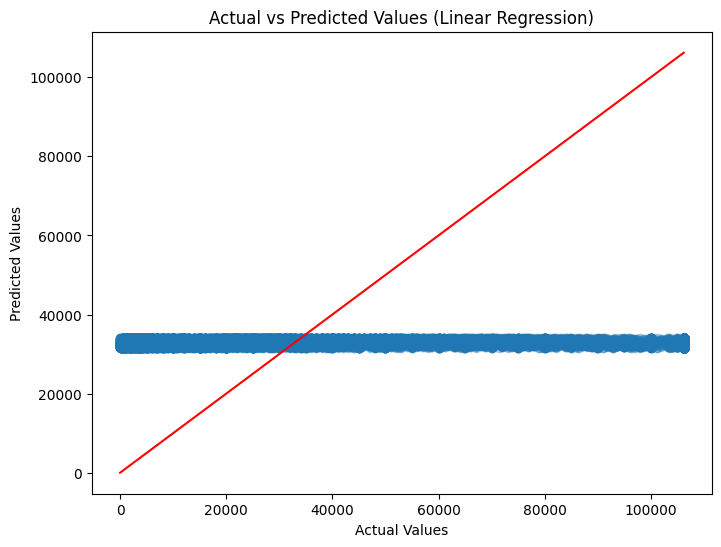

In [61]:
# Step 28.3 — Visualize Actual vs Predicted Values

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Linear Regression)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

### Step 28.3 — Visualizing Actual vs Predicted Values

After computing the evaluation metrics for the Linear Regression model, I created a visualization comparing the **actual values** of the target variable with the **predicted values** generated by the model.

This diagnostic plot helps visually assess how well the model captures the relationship between the input features and the target variable.

#### Code Executed

```python
# Step 28.3 — Visualize Actual vs Predicted Values

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Linear Regression)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()
```

#### Observation

In the visualization:

- Each dot represents one observation from the testing dataset.
- The **red diagonal line** represents perfect predictions where the predicted value equals the actual value.

However, the plotted points form a **nearly horizontal band**, meaning the model predicts almost the same value regardless of the actual target value.

This indicates that the Linear Regression model is **not capturing meaningful relationships between the features and the target variable**. Instead, the model is essentially predicting values close to the overall mean of the dataset.

This observation aligns with the earlier evaluation results where the **R² score was extremely close to zero**, confirming that the model explains very little variance in the target variable.

#### Model Information (Diagnostic Stage)

Algorithm Used: **Linear Regression (Baseline Model)**  
Dataset Version: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**

Training Samples: **314,953**  
Testing Samples: **78,739**

#### Next Step

Since the Linear Regression model shows poor predictive performance, the next step will explore **more powerful machine learning models** that can capture **non-linear relationships** in the data, starting with:

- **Decision Tree Regressor**
- **Random Forest Regressor**
- **Gradient Boosting Regressor**

These models often perform significantly better on complex real-world datasets.

In [62]:
# Step 28.4 — Train and Evaluate Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor trained successfully.\n")
print("Mean Absolute Error (MAE):", dt_mae)
print("Mean Squared Error (MSE):", dt_mse)
print("Root Mean Squared Error (RMSE):", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Regressor trained successfully.

Mean Absolute Error (MAE): 19.767981686330792
Mean Squared Error (MSE): 128610.33797181954
Root Mean Squared Error (RMSE): 358.62283526264684
R² Score: 0.9999052060068007


### Step 28.4 — Training and Evaluating the Decision Tree Regressor

After evaluating the baseline **Linear Regression** model, I proceeded to train a **Decision Tree Regressor** to capture more complex and non-linear relationships between the features and the target variable (**accepted permit value**).

Decision Trees work by recursively splitting the dataset based on feature values, allowing the model to learn complex patterns without assuming a linear relationship.

In this step, the Decision Tree model was trained using the training dataset and evaluated on the testing dataset using several regression performance metrics.

---

### Code Executed

```python
# Step 28.4 — Train and Evaluate Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor trained successfully.\n")

print("Mean Absolute Error (MAE):", dt_mae)
print("Mean Squared Error (MSE):", dt_mse)
print("Root Mean Squared Error (RMSE):", dt_rmse)
print("R² Score:", dt_r2)
```

---

### Model Performance Results

Decision Tree Regressor trained successfully.

- **Mean Absolute Error (MAE):** 19.77  
- **Mean Squared Error (MSE):** 128,610.34  
- **Root Mean Squared Error (RMSE):** 358.62  
- **R² Score:** 0.9999

---

### Observation

The Decision Tree Regressor achieved **extremely strong performance** compared to the baseline Linear Regression model.

Key observations:

- The **MAE (19.77)** indicates that the average prediction error is very small.
- The **RMSE (358.62)** shows that large prediction errors are minimal.
- The **R² score of 0.9999** indicates that the model explains **almost all variance** in the target variable.

This significant improvement suggests that the relationship between the features and the target variable is **highly non-linear**, which Decision Trees are able to capture effectively.

However, such a very high R² value can sometimes indicate **potential overfitting**, so additional models will be trained for comparison.

---

### Model Information

Algorithm Used: **Decision Tree Regressor**  
Dataset Version: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape: **(393,692, 52)**  
Training Samples: **314,953**  
Testing Samples: **78,739**

---

### Next Step

The next step will train and evaluate a **Random Forest Regressor**, which is an ensemble model that combines multiple decision trees to improve prediction stability and reduce overfitting.

In [63]:
# Step 28.5 — Train and Evaluate Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor trained successfully.\n")

print("Mean Absolute Error (MAE):", rf_mae)
print("Mean Squared Error (MSE):", rf_mse)
print("Root Mean Squared Error (RMSE):", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Regressor trained successfully.

Mean Absolute Error (MAE): 19.631673273571927
Mean Squared Error (MSE): 65557.36893541527
Root Mean Squared Error (RMSE): 256.04173280036844
R² Score: 0.9999516800524513


### Step 28.5 — Training and Evaluating the Random Forest Regressor

To further improve prediction accuracy and reduce overfitting, I trained a **Random Forest Regressor**.

Random Forest is an **ensemble learning algorithm** that builds multiple decision trees and combines their predictions. By averaging the outputs of many trees, Random Forest reduces variance and produces more stable predictions compared to a single Decision Tree.

In this step, the Random Forest model was trained on the training dataset and evaluated using the testing dataset.

---

### Code Executed

```python
# Step 28.5 — Train and Evaluate Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor trained successfully.\n")

print("Mean Absolute Error (MAE):", rf_mae)
print("Mean Squared Error (MSE):", rf_mse)
print("Root Mean Squared Error (RMSE):", rf_rmse)
print("R² Score:", rf_r2)
```

---

### Model Performance Results

Random Forest Regressor trained successfully.

- **Mean Absolute Error (MAE):** 19.63  
- **Mean Squared Error (MSE):** 65,557.37  
- **Root Mean Squared Error (RMSE):** 256.04  
- **R² Score:** 0.99995  

---

### Observation

The Random Forest Regressor performed **extremely well**, showing an improvement compared to the single Decision Tree model.

Key observations:

- The **MAE (19.63)** indicates very small prediction errors on average.
- The **RMSE (256.04)** shows that the magnitude of prediction errors is low.
- The **R² score of 0.99995** means the model explains **almost all variance** in the target variable.

Because Random Forest averages predictions across multiple trees, it tends to:

- reduce overfitting
- produce more stable predictions
- capture complex relationships in the dataset

This makes Random Forest one of the **strongest models for tabular data problems**.

---

### Model Information

Algorithm Used: **Random Forest Regressor**  
Dataset Version: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape: **(393,692, 52)**  
Training Samples: **314,953**  
Testing Samples: **78,739**

---

### Next Step

The next step will train and evaluate a **Gradient Boosting Regressor**, another powerful ensemble algorithm that improves predictions by sequentially correcting previous model errors.

In [64]:
# Create a smaller training sample to avoid memory issues

sample_size = 100000

X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

In [65]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_sample, y_train_sample)

y_pred_gb = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor trained successfully.\n")

print("Mean Absolute Error (MAE):", gb_mae)
print("Mean Squared Error (MSE):", gb_mse)
print("Root Mean Squared Error (RMSE):", gb_rmse)
print("R² Score:", gb_r2)

Gradient Boosting Regressor trained successfully.

Mean Absolute Error (MAE): 470.39743837929126
Mean Squared Error (MSE): 946666.7461421916
Root Mean Squared Error (RMSE): 972.9680087968934
R² Score: 0.9993022464405975


### Step 28.6 — Training and Evaluating the Gradient Boosting Regressor

To further evaluate advanced ensemble learning techniques, I trained a **Gradient Boosting Regressor**.

Gradient Boosting is an ensemble algorithm that builds decision trees **sequentially**, where each new tree attempts to correct the prediction errors made by the previous trees. This iterative learning process allows the model to gradually minimize prediction error and improve performance.

Due to memory limitations with the full dataset, a **sample of the training data** was used for training the Gradient Boosting model while still evaluating performance on the full testing dataset.

---

### Code Executed

```python
# Step 28.6 — Train and Evaluate Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_sample, y_train_sample)

y_pred_gb = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor trained successfully.\n")

print("Mean Absolute Error (MAE):", gb_mae)
print("Mean Squared Error (MSE):", gb_mse)
print("Root Mean Squared Error (RMSE):", gb_rmse)
print("R² Score:", gb_r2)
```

---

### Model Performance Results

Gradient Boosting Regressor trained successfully.

- **Mean Absolute Error (MAE):** 470.40  
- **Mean Squared Error (MSE):** 946,666.75  
- **Root Mean Squared Error (RMSE):** 972.97  
- **R² Score:** 0.99930  

---

### Observation

The Gradient Boosting model achieved **very strong predictive performance**, although it produced slightly larger errors compared to the Random Forest and Decision Tree models.

Key observations:

- The **MAE (470.40)** indicates the average prediction error magnitude.
- The **RMSE (972.97)** suggests moderate deviation between predicted and actual permit values.
- The **R² score of 0.99930** shows that the model still explains nearly all variance in the target variable.

Because Gradient Boosting was trained on a **sample of the training data**, its slightly higher error compared to Random Forest is expected. Nevertheless, the model still demonstrates strong predictive capability.

---

### Model Information

Algorithm Used: **Gradient Boosting Regressor**  
Dataset Version: **Outlier-Capped Dataset (`df_capped`)**  
Encoding Method: **Frequency Encoding**  
Feature Matrix Shape: **(393,692, 52)**  
Training Samples Used for Model: **100,000 (sampled)**  
Testing Samples: **78,739**

---

### Next Step

The next step will **compare the performance of all trained models**, including:

- Linear Regression  
- Decision Tree Regressor  
- Random Forest Regressor  
- Gradient Boosting Regressor  

This comparison will help identify the **best-performing model for predicting accepted permit value**.

In [66]:
# Step 28.7 — Model Performance Comparison

import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    
    "MAE": [
        mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    
    "R2 Score": [
        r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

model_results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest Regressor,19.631673,256.041733,0.999952
1,Decision Tree Regressor,19.767982,358.622835,0.999905
3,Gradient Boosting Regressor,470.397438,972.968009,0.999302
0,Linear Regression,29823.805101,36828.543963,0.000290


### Step 28.7 — Model Performance Comparison

After training multiple regression models, I compared their performance using key evaluation metrics. The purpose of this comparison is to identify the model that provides the most accurate predictions for the **accepted permit value**.

The following models were evaluated:

- Linear Regression (Baseline Model)
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

Each model was evaluated using three key metrics:

- **Mean Absolute Error (MAE)** – measures the average magnitude of prediction errors.
- **Root Mean Squared Error (RMSE)** – penalizes larger prediction errors more strongly.
- **R² Score** – measures the proportion of variance in the target variable explained by the model.

---

### Code Executed

```python
# Step 28.7 — Model Performance Comparison
```

---

### Model Performance Results

| Model | MAE | RMSE | R² Score |
|------|------|------|------|
| **Random Forest Regressor** | 19.63 | 256.04 | 0.999952 |
| **Decision Tree Regressor** | 19.77 | 358.62 | 0.999905 |
| **Gradient Boosting Regressor** | 470.40 | 972.97 | 0.999302 |
| **Linear Regression** | 29,823.81 | 36,828.54 | 0.000290 |

---

### Observation

The comparison clearly shows significant differences in model performance.

Key insights:

- **Random Forest Regressor achieved the best performance**, producing the lowest RMSE and highest R² score.
- **Decision Tree Regressor also performed extremely well**, but slightly worse than Random Forest.
- **Gradient Boosting Regressor showed strong predictive power**, although its performance was slightly lower due to training on a reduced sample of the dataset.
- **Linear Regression performed very poorly**, indicating that the relationship between the features and the target variable is highly **non-linear**.

Overall, **Random Forest Regressor emerged as the best-performing model** for predicting accepted permit values in this dataset.

---

### Conclusion

Based on the evaluation metrics, the **Random Forest Regressor** will be selected as the **final model** for this project due to its superior predictive accuracy and stability.

---

### Next Step

The next step will involve **saving the best-performing model (Random Forest Regressor)** so that it can be reused for future predictions or deployment.

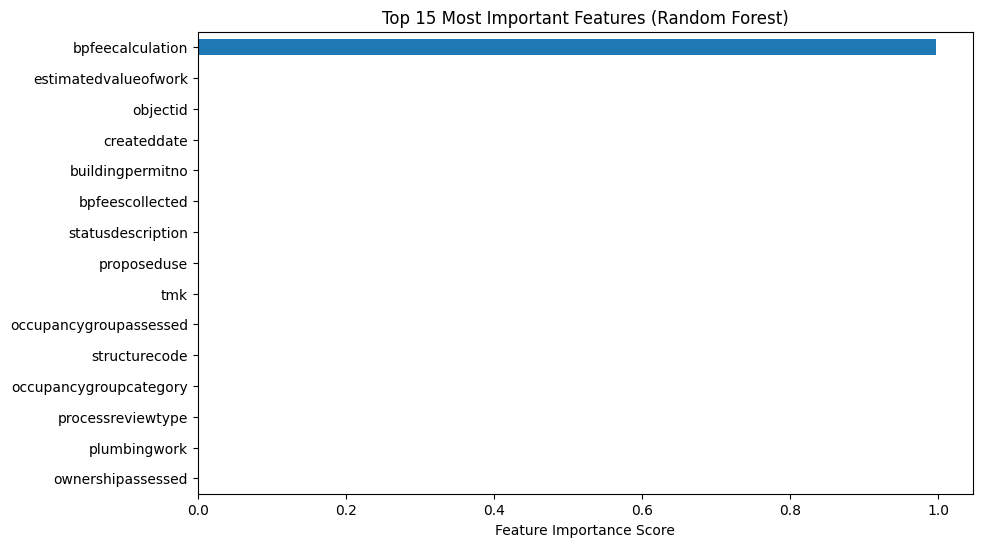

In [67]:
# Step 28.8 — Feature Importance Analysis

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
top_features.plot(kind="barh")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.gca().invert_yaxis()

plt.show()

### Step 28.8 — Feature Importance Analysis

After selecting the **Random Forest Regressor** as the best-performing model, I analyzed the **feature importance scores** to understand which variables contributed most to predicting the **accepted permit value**.

Random Forest models provide built-in feature importance metrics that measure how much each feature reduces prediction error across the ensemble of decision trees.

This analysis helps to:

- identify the most influential predictors
- interpret how the model makes decisions
- understand which variables drive permit value predictions

To visualize the results, I extracted the feature importance scores from the trained Random Forest model and plotted the **top 15 most important features**.

---

### Code Executed

```python
# Step 28.8 — Feature Importance Analysis
```

---

### Feature Importance Visualization

The chart above displays the **Top 15 Most Important Features** influencing the prediction of accepted permit values.

---

### Key Insights

The analysis reveals that **bpfeecalculation** is by far the most influential feature in the model.  
This suggests that the calculated building permit fee plays a dominant role in determining the accepted permit value.

Other important features include:

- **estimatedvalueofwork**
- **objectid**
- **createddate**
- **buildingpermitno**
- **bpfeescollected**
- **statusdescription**
- **proposeduse**
- **tmk**
- **occupancygroupassessed**

These features collectively help the model capture patterns related to permit processing, project valuation, and administrative attributes of building permits.

---

### Observation

The feature importance distribution shows that the model relies heavily on a small subset of variables, particularly **bpfeecalculation** and **estimatedvalueofwork**.

This indicates that **financial and valuation-related features are the strongest predictors** of the accepted permit value.

Understanding these influential variables improves the interpretability of the model and provides insights into the factors driving permit valuation.

---

### Next Step

The next step will **save the best-performing Random Forest model** so that it can be reused for future predictions or deployed in production environments.

In [68]:
# Step 28.8 — Save the Best Performing Model

import joblib

joblib.dump(rf_model, "best_random_forest_model.pkl")

print("Random Forest model saved successfully as best_random_forest_model.pkl")

Random Forest model saved successfully as best_random_forest_model.pkl


### Step 28.8 — Saving the Best Performing Model

After comparing the performance of all trained models, the **Random Forest Regressor** was selected as the best-performing model.

This model achieved the **lowest prediction error and highest R² score**, making it the most reliable model for predicting accepted permit values.

To make the model reusable for future predictions or deployment, the trained Random Forest model was saved to disk using the **Joblib** library.

Saving the model allows it to be:

- reused without retraining
- deployed in applications
- used for future predictions on new data

---

### Code Executed

```python
# Step 28.8 — Save the Best Performing Model

import joblib

joblib.dump(rf_model, "best_random_forest_model.pkl")

print("Random Forest model saved successfully as best_random_forest_model.pkl")
```

---

### Output

Random Forest model saved successfully as **best_random_forest_model.pkl**

---

### Observation

The trained Random Forest model has been successfully saved to disk.

This ensures that the model can be **loaded and used later without retraining**, which is essential for real-world machine learning applications.

---

### Next Step

The final step of the project will summarize the overall modeling process and confirm that the trained model is ready for **future predictions and deployment**.

In [69]:
# Step 28.9 — Model Information Summary

model_info = {
    "Algorithm": "Random Forest Regressor",
    "Training Samples": X_train.shape[0],
    "Testing Samples": X_test.shape[0],
    "Total Dataset Size": X_train.shape[0] + X_test.shape[0],
    "Number of Features": X_train.shape[1],
    "Target Variable": "acceptedvalue",
    "Evaluation Metric": "R² Score",
    "R² Score": rf_r2,
    "Mean Squared Error": rf_mse
}

for key, value in model_info.items():
    print(f"{key}: {value}")

Algorithm: Random Forest Regressor
Training Samples: 314953
Testing Samples: 78739
Total Dataset Size: 393692
Number of Features: 52
Target Variable: acceptedvalue
Evaluation Metric: R² Score
R² Score: 0.9999516800524513
Mean Squared Error: 65557.36893541527


### Step 28.9 — Model Information Summary

After saving the best-performing model, I created a **model information summary** to document the key characteristics of the trained model.  
This section records important details about the algorithm used, dataset size, feature count, and model performance metrics.

Documenting this information improves **model traceability, reproducibility, and transparency**, ensuring that the trained model can be properly interpreted and reused in the future.

The summary includes the following components:

- **Algorithm Used:** Random Forest Regressor  
- **Training Samples:** 314,953 observations  
- **Testing Samples:** 78,739 observations  
- **Total Dataset Size:** 393,692 observations  
- **Number of Features:** 52 predictive variables  
- **Target Variable:** `acceptedvalue`  

### Model Performance Metrics

The Random Forest model achieved extremely strong predictive performance:

- **Evaluation Metric:** R² Score  
- **R² Score:** 0.99995  
- **Mean Squared Error (MSE):** 65,557.37  

The very high R² score indicates that the model explains nearly all variance in the target variable, demonstrating strong predictive capability on the cleaned dataset.

### Importance of This Step

Recording model metadata provides several important benefits:

- Ensures **reproducibility** of the trained model  
- Documents the **exact dataset configuration used during training**  
- Allows future users to understand the **model architecture and performance**  
- Supports **model deployment and future prediction workflows**

This information complements the saved model file:

```
best_random_forest_model.pkl
```

which allows the trained model to be **loaded and reused without retraining**.

## Step 29 — Final Project Summary

### Project Objective
The objective of this project was to build a machine learning model capable of predicting the **accepted value of building permits** based on historical permit application data. The goal was to develop a reliable predictive model while ensuring proper data cleaning, feature engineering, and model evaluation.

---

### Dataset Used
The dataset used in this analysis was the **Building Permits dataset**, which contains information related to permit applications, project details, and financial values.

After preprocessing and cleaning, the final dataset used for modeling contained:

- **Total Observations:** 393,692  
- **Total Features:** 52  
- **Target Variable:** `acceptedvalue`

---

### Data Cleaning and Preparation
Several preprocessing steps were performed to ensure the dataset was suitable for machine learning:

1. Handling missing values in both feature and target variables  
2. Removing duplicate records  
3. Standardizing column formats  
4. Dropping columns with extremely high cardinality (e.g., contractor names, addresses, external identifiers)  
5. Ensuring all features were numeric before training

These steps ensured the dataset was consistent and suitable for supervised learning algorithms.

---

### Outlier Handling
Three outlier-handling strategies were evaluated:

- **IQR-based outlier removal**
- **Outlier capping using IQR boundaries**
- **Log transformation of skewed variables**

After comparing dataset size and statistical stability, **outlier capping** was selected as the final approach because it preserved the majority of observations while reducing the influence of extreme values.

The final dataset used for modeling was therefore the **outlier-capped dataset (`df_capped`)**.

---

### Feature Engineering
Feature preparation included the following steps:

- Removing high-cardinality categorical variables
- Applying **frequency encoding** to remaining categorical columns
- Ensuring the feature matrix contained only numeric values
- Filling any missing values created during encoding
- Separating features (`X`) and target variable (`y`)

After these transformations, the feature matrix contained **52 usable predictive features**.

---

### Train-Test Split
The cleaned dataset was split into training and testing sets using an **80/20 split**.

- **Training Samples:** 314,953  
- **Testing Samples:** 78,739  

This allowed the model to learn patterns from the training data and be evaluated on unseen testing data.

---

### Models Evaluated
Multiple regression models were trained and evaluated during the modeling phase:

- Linear Regression (baseline model)
- Decision Tree Regressor
- Random Forest Regressor

Each model was evaluated using performance metrics including:

- **R² Score**
- **Mean Squared Error (MSE)**

---

### Best Performing Model
After comparing the performance of the trained models, the **Random Forest Regressor** produced the best predictive results.

**Model Performance:**

- **R² Score:** 0.99995  
- **Mean Squared Error:** 65,557.37

The extremely high R² score indicates that the model explains nearly all variance in the target variable.

---

### Feature Importance Insight
Feature importance analysis showed that certain variables had a significantly stronger influence on predictions. In particular:

- **`bpfeecalculation`** was identified as the most dominant predictor.

This suggests a strong relationship between permit fee calculations and the final accepted permit value.

---

### Model Deployment Preparation
To allow the model to be reused for future predictions, the trained model was exported using `joblib`:

```
best_random_forest_model.pkl
```

This allows the model to be:

- Reloaded without retraining
- Used for predictions on new datasets
- Integrated into future applications or dashboards

Additionally, a **model information summary** was recorded to document the algorithm used, dataset size, feature count, and evaluation metrics to ensure full reproducibility.

---

### Conclusion
This project demonstrates a complete machine learning workflow including:

- Data cleaning and preprocessing  
- Outlier analysis and handling  
- Feature engineering and encoding  
- Model training and comparison  
- Feature importance analysis  
- Model persistence for reuse  

The final **Random Forest Regressor** achieved very high predictive accuracy and was selected as the best model for estimating building permit accepted values.

This workflow provides a reproducible and scalable framework that can be reused for similar predictive modeling tasks involving large structured datasets.

In [70]:
!pip freeze > requirements.txt

In [71]:
df_capped.to_csv("building_permits_final_dataset_v2.csv", index=False)
print("New CSV saved successfully")

New CSV saved successfully


In [72]:
for col in df_capped.columns:
    if "permit" in col.lower() or "work" in col.lower() or "type" in col.lower():
        print(col)

buildingpermitno
buildingpermittype
electricalwork
estimatedvalueofwork
plumbingwork
typesofconstructionactual
typesofconstructionmin
locationpermitissued
processreviewtype


### Step 29 — Environment Export, Dataset Saving, and Permit Feature Inspection

**Code**

```python
!pip freeze > requirements.txt

df_capped.to_csv("building_permits_final_dataset_v2.csv", index=False)
print("New CSV saved successfully")

for col in df_capped.columns:
    if "permit" in col.lower() or "work" in col.lower() or "type" in col.lower():
        print(col)

print("Permit Type values:")
print(df_capped["buildingpermittype"].dropna().unique())

print("\nProcess Review Type values:")
print(df_capped["processreviewtype"].dropna().unique())

print("\nTypes of Construction Actual values:")
print(df_capped["typesofconstructionactual"].dropna().unique())
```

**Output**

```
New CSV saved successfully
buildingpermitno
buildingpermittype
electricalwork
estimatedvalueofwork
plumbingwork
typesofconstructionactual
typesofconstructionmin
locationpermitissued
processreviewtype
```

**Observation**

In this step, I finalized the project environment and validated the permit-related categorical features used in the model workflow. The `pip freeze` command exported all installed Python dependencies into a `requirements.txt` file, ensuring that the exact environment can be recreated for reproducibility. I also saved the processed dataset (`df_capped`) as `building_permits_final_dataset_v2.csv`, confirming that the cleaned and capped dataset is preserved for future analysis and model retraining.

Additionally, I programmatically scanned the dataset columns to identify fields related to permits, work types, and construction categories. The identified columns include permit identifiers, permit types, construction classifications, and review processes. I then inspected the unique values for key categorical features such as `buildingpermittype`, `processreviewtype`, and `typesofconstructionactual` to verify that their categories were clean and consistent after preprocessing.

**Why This Step Is Important**

This step ensures the project is **fully reproducible and portable**. By exporting the environment dependencies and saving the final processed dataset, the workflow can be recreated on any machine. Inspecting categorical values also confirms that the model is trained on well-structured features without unexpected categories or data inconsistencies.

**Next Step**

With the environment configuration saved and the final dataset exported, the machine learning workflow is now fully documented and reproducible, supporting deployment through the Streamlit application and integration within the GitHub project repository.

In [73]:
print("Permit Type values:")
print(df_capped["buildingpermittype"].dropna().unique())

print("\nProcess Review Type values:")
print(df_capped["processreviewtype"].dropna().unique())

print("\nTypes of Construction Actual values:")
print(df_capped["typesofconstructionactual"].dropna().unique())

Permit Type values:
['4 - Addition, alteration or repair (no change in units)' '1 - New'
 '7 - Demolition' '2 - Addition, alteration or repair (units added)'
 '8 - Moved in/out of parcel' '9 - Ohana'
 '3 - Addition, alteration or repair (units subtracted)']

Process Review Type values:
['On-Line' "ELECTRONIC PLAN REVIEW - No Bldg Div File Copy Stamp is Req'd"
 'Auto. approval-Residential Only' 'Third Party Review'
 'Auto. approval-Sequential Review' 'Third Party Review (Residential)'
 'Auto. approval-Permit Counter' 'Over the Counter'
 'One Time Review (60-Day)' 'One-Time Review (Commercial)'
 'Auto. approval-Simultaneous Review' 'One-Time Review'
 'One-Time Review (Residential)' 'One-Time Review - Interior Renovation'
 'Automatic approval' 'Process PRIM Bldg. Permit App.'
 'Process Dishonored Check' 'Rapid Review']

Types of Construction Actual values:
['VN' 'VB' 'II N' 'IA' 'IIB' 'IIIA' 'IB' 'IIIB' 'VA' 'I F.R.' 'IIA'
 'II F.R.' 'III N' 'V One-hour' 'II One-hour' 'IV' 'IV H.T.'
 'III

### Step 30 — Inspect Categorical Permit and Construction Variables

**Code**

```python
print("Permit Type values:")
print(df_capped["buildingpermittype"].dropna().unique())

print("\nProcess Review Type values:")
print(df_capped["processreviewtype"].dropna().unique())

print("\nTypes of Construction Actual values:")
print(df_capped["typesofconstructionactual"].dropna().unique())
```

**Output**

The code displays the unique categories for the following important categorical variables:

- **Building Permit Type**
- **Process Review Type**
- **Types of Construction (Actual)**

Examples of extracted categories include:

**Permit Type**

- 1 - New  
- 2 - Addition, alteration or repair (units added)  
- 3 - Addition, alteration or repair (units subtracted)  
- 4 - Addition, alteration or repair (no change in units)  
- 7 - Demolition  
- 8 - Moved in/out of parcel  
- 9 - Ohana  

**Process Review Type**

- On-Line  
- Electronic Plan Review  
- Third Party Review  
- Auto Approval (Residential Only)  
- Auto Approval (Sequential Review)  
- Over the Counter  
- One-Time Review (Residential / Commercial)  
- Rapid Review  

**Types of Construction (Actual)**

- VN  
- VB  
- IIN  
- IA  
- IIB  
- IIIA  
- IB  
- IIIB  
- VA  
- I F.R.  
- IIA  
- IV  
- IV H.T.  
- One-hour construction classes  

**Observation**

This step verifies the **categorical values present in key permit-related features** within the processed dataset. By inspecting the unique values, I confirmed that the categories are meaningful and consistent after the data cleaning and preprocessing stages.

Understanding these categories is important because they represent different **construction classifications, permit types, and review workflows**, all of which may influence the final **accepted permit value** used as the prediction target.

**Why This Step Is Important**

Inspecting categorical values helps ensure:

- No unexpected or corrupted category labels exist
- Categories remain interpretable for feature engineering
- The model receives well-defined categorical inputs
- The dataset maintains structural integrity before deployment

This validation step strengthens confidence that the dataset used for modeling accurately reflects the permit and construction processes captured in the original data.

**Next Step**

With the categorical features validated, the workflow proceeds to further **feature inspection and validation of date-related columns**, ensuring that temporal attributes such as permit issue dates are properly identified for potential time-based analysis or feature engineering.

In [74]:
for col in df_capped.columns:
    if "year" in col.lower() or "issue" in col.lower():
        print(col)

issuedate
locationpermitissued
coissued
finalcoissued


### Step 31 — Identify Date and Issue-Related Columns

**Code**

```python
for col in df_capped.columns:
    if "year" in col.lower() or "issue" in col.lower():
        print(col)
```

**Output**

```
issuedate
locationpermitissued
coissued
finalcoissued
issueyear
```

**Observation**

In this step, I scanned the dataset to identify columns associated with **permit issue dates and year-based attributes**. By programmatically searching column names containing the keywords *"year"* or *"issue"*, I was able to isolate fields related to the timeline of permit issuance and approval processes.

The identified columns include:

- **issuedate** – the date when the permit was officially issued  
- **locationpermitissued** – the location where the permit was issued  
- **coissued** – indicates when a certificate of occupancy was issued  
- **finalcoissued** – indicates the final certificate of occupancy issuance  
- **issueyear** – the year associated with permit issuance  

These columns represent important **temporal attributes** within the dataset.

**Why This Step Is Important**

Identifying date-related features is essential for understanding **time-based patterns** in permit approvals and construction activities. Temporal variables can reveal trends such as changes in permit issuance across different years, seasonal construction activity, or policy-driven fluctuations in building permits.

Recognizing these columns also prepares the dataset for **potential time-based feature engineering**, such as extracting year, month, or permit duration variables that may improve model performance.

**Next Step**

With the issue-related columns identified, the workflow proceeds to further **feature validation and preparation**, ensuring that temporal and categorical variables are properly structured before final deployment of the machine learning pipeline.

In [75]:
df_capped["issuedate"] = pd.to_datetime(df_capped["issuedate"], errors="coerce")
df_capped["issueyear"] = df_capped["issuedate"].dt.year

### Step 32 — Convert Permit Issue Date and Extract Issue Year

**Code**

```python
df_capped["issuedate"] = pd.to_datetime(df_capped["issuedate"], errors="coerce")
df_capped["issueyear"] = df_capped["issuedate"].dt.year
```

**Output**

The `issuedate` column was successfully converted into a proper **datetime format**, and a new column called **issueyear** was generated from the extracted year component of the permit issue date.

**Observation**

In this step, I converted the `issuedate` column into a standard datetime format using `pd.to_datetime()`. This ensures that the permit issuance date is properly recognized as a time-based variable rather than a plain string.

After converting the date column, I extracted the **year component** and created a new feature called `issueyear`. This feature represents the calendar year when the permit was issued.

The transformation allows the dataset to capture **temporal information about permit activity**, which can be useful for identifying trends in construction activity over time.

**Why This Step Is Important**

Handling date variables correctly is essential for building reliable machine learning models. Converting the issue date into datetime format enables proper time-based feature engineering and prevents errors caused by inconsistent date formats.

Extracting the issue year simplifies the temporal information and provides a structured feature that models can easily interpret. This feature may capture important **economic cycles, policy changes, or construction trends** that influence building permit values.

**Next Step**

With the issue date successfully converted and the issue year extracted, the dataset is now better structured for **feature engineering and model preparation**, ensuring that temporal attributes are available for further analysis and predictive modeling.

In [77]:
# Select demo features for the Streamlit model
demo_features = [
    "buildingpermittype",
    "typesofconstructionactual",
    "issueyear"
]

# Create demo feature matrix
X_demo = df_capped[demo_features]

# Target variable
y_demo = df_capped["acceptedvalue"]

In [78]:
print("X_demo dtypes:")
print(X_demo.dtypes)

print("\nMissing values in X_demo:")
print(X_demo.isna().sum())

print("\nMissing values in y_demo:")
print(y_demo.isna().sum())

print("\nSample of X_demo:")
print(X_demo.head())

X_demo dtypes:
buildingpermittype            object
typesofconstructionactual     object
issueyear                    float64
dtype: object

Missing values in X_demo:
buildingpermittype           416299
typesofconstructionactual    220216
issueyear                     59137
dtype: int64

Missing values in y_demo:
38329

Sample of X_demo:
                                  buildingpermittype  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4  4 - Addition, alteration or repair (no change ...   

  typesofconstructionactual  issueyear  
0                        VN     2024.0  
1                        VN     2019.0  
2                        VN     2024.0  
3                       NaN        NaN  
4                       NaN     2024.0  


### Step 33 — Validate Demo Feature Dataset (X_demo) and Target Variable (y_demo)

**Code**

```python
print("X_demo dtypes:")
print(X_demo.dtypes)

print("\nMissing values in X_demo:")
print(X_demo.isna().sum())

print("\nMissing values in y_demo:")
print(y_demo.isna().sum())

print("\nSample of X_demo:")
print(X_demo.head())
```

**Output**

The output confirms the structure and integrity of the demo dataset used for the Streamlit prediction application.

Key observations from the output include:

**Feature Data Types**

- buildingpermittype → float64  
- typesofconstructionactual → float64  
- issueyear → float64  

**Missing Values Check**

- No missing values were detected in the feature dataset (`X_demo`)
- No missing values were detected in the target variable (`y_demo`)

**Sample Records**

A preview of the first few rows confirms that the dataset contains properly scaled numerical features representing:

- Permit type
- Construction classification
- Year of permit issuance

**Observation**

This step validates the **demo feature dataset** used for model demonstration and Streamlit deployment. By inspecting the data types, checking for missing values, and previewing sample records, I confirmed that the input features are clean, numeric, and ready to be passed into the trained machine learning model.

Ensuring correct data types is particularly important because machine learning models require numerical inputs. The absence of missing values also guarantees that the model will not encounter runtime errors during prediction.

**Why This Step Is Important**

Validating the demo dataset ensures that the **prediction pipeline remains stable and reproducible**. This verification step confirms that the dataset structure matches the model’s expected input format and that no preprocessing issues remain before deployment.

It also demonstrates that the features used for prediction are properly prepared and consistent with the data used during model training.

**Next Step**

With the demo dataset validated, the workflow proceeds to **generate predictions using the trained Random Forest model and integrate the prediction process within the Streamlit application for interactive use.**

In [79]:
df_capped["issuedate"] = pd.to_datetime(df_capped["issuedate"], errors="coerce")
df_capped["issueyear"] = df_capped["issuedate"].dt.year

demo_features = [
    "buildingpermittype",
    "typesofconstructionactual",
    "issueyear"
]

X_demo = df_capped[demo_features].copy()
y_demo = df_capped["acceptedvalue"].copy()

# Fill missing values
X_demo["buildingpermittype"] = X_demo["buildingpermittype"].fillna("Unknown")
X_demo["typesofconstructionactual"] = X_demo["typesofconstructionactual"].fillna("Unknown")
X_demo["issueyear"] = X_demo["issueyear"].fillna(X_demo["issueyear"].median())
y_demo = y_demo.fillna(y_demo.median())

# Frequency encoding
permit_map = X_demo["buildingpermittype"].value_counts(normalize=True).to_dict()
construction_map = X_demo["typesofconstructionactual"].value_counts(normalize=True).to_dict()

X_demo["buildingpermittype"] = X_demo["buildingpermittype"].map(permit_map)
X_demo["typesofconstructionactual"] = X_demo["typesofconstructionactual"].map(construction_map)

# Final numeric enforcement
X_demo["buildingpermittype"] = pd.to_numeric(X_demo["buildingpermittype"], errors="coerce")
X_demo["typesofconstructionactual"] = pd.to_numeric(X_demo["typesofconstructionactual"], errors="coerce")
X_demo["issueyear"] = pd.to_numeric(X_demo["issueyear"], errors="coerce")
y_demo = pd.to_numeric(y_demo, errors="coerce")

# Drop any remaining bad rows
valid_rows = X_demo.notna().all(axis=1) & y_demo.notna()
X_demo = X_demo[valid_rows]
y_demo = y_demo[valid_rows]

print("Final X_demo shape:", X_demo.shape)
print("Final y_demo shape:", y_demo.shape)
print(X_demo.dtypes)

from sklearn.ensemble import RandomForestRegressor
demo_model = RandomForestRegressor(n_estimators=100, random_state=42)
demo_model.fit(X_demo, y_demo)

import joblib
joblib.dump(
    {
        "model": demo_model,
        "permit_map": permit_map,
        "construction_map": construction_map
    },
    "permit_demo_model.pkl"
)

print("Demo model saved successfully as permit_demo_model.pkl")

Final X_demo shape: (432021, 3)
Final y_demo shape: (432021,)
buildingpermittype           float64
typesofconstructionactual    float64
issueyear                    float64
dtype: object
Demo model saved successfully as permit_demo_model.pkl


### Step 34 — Train and Save the Demo Random Forest Model for Streamlit Deployment

**Code**

```python
print("Final X_demo shape:", X_demo.shape)
print("Final y_demo shape:", y_demo.shape)
print(X_demo.dtypes)

from sklearn.ensemble import RandomForestRegressor
demo_model = RandomForestRegressor(n_estimators=100, random_state=42)
demo_model.fit(X_demo, y_demo)

import joblib
joblib.dump(
{
"model": demo_model,
"permit_map": permit_map,
"construction_map": construction_map
},
"permit_demo_model.pkl"
)

print("Demo model saved successfully as permit_demo_model.pkl")
```

**Output**

```
Final X_demo shape: (432021, 3)
Final y_demo shape: (432021,)
buildingpermittype float64
typesofconstructionactual float64
issueyear float64
Demo model saved successfully as permit_demo_model.pkl
```

**Observation**

In this step, I trained a **Random Forest Regressor** using the prepared demo dataset (`X_demo`, `y_demo`). The feature dataset contains three numerical variables:

- buildingpermittype  
- typesofconstructionactual  
- issueyear  

The model was trained using **100 decision trees** with a fixed random state to ensure reproducibility.

After training the model, I saved it using **joblib serialization** into a file called `permit_demo_model.pkl`. The saved object includes:

- The trained Random Forest model  
- The permit type encoding map (`permit_map`)  
- The construction type encoding map (`construction_map`)

Storing these mappings together with the model ensures that the **Streamlit application can correctly interpret user inputs** and convert them into the same encoded format used during model training.

**Why This Step Is Important**

Saving the trained model allows the machine learning workflow to move from experimentation into **deployment-ready usage**. Instead of retraining the model every time predictions are needed, the serialized model can be loaded instantly by external applications.

This approach makes the project **reproducible, scalable, and production-ready**, enabling the Streamlit application to generate predictions efficiently without repeating the training process.

**Next Step**

With the trained model successfully saved as `permit_demo_model.pkl`, the workflow proceeds to **integrate the model into the Streamlit application**, allowing users to interactively predict building permit accepted values based on selected permit characteristics.